# Advanced Topics in Deep Learning (ATDL)

## Assignment I — Knowledge Distillation with Ternary-Weight Quantization-Aware Training

**Teacher:** ResNet34 FP32  
**Students:** ResNet18 FP32 Baseline and ResNet18 Ternary + Knowledge Distillation  
**Dataset:** CIFAR-10

## 1. Environment and Hardware Setup

In [ ]:
import sys
import torch
import torchvision

print("Python:", sys.version)
print("Python executable:", sys.executable)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

### 1.1 Reproducibility and Device Configuration

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA RTX 5000 Ada Generation


### 1.2 Project Directory Configuration

In [3]:
PROJECT_DIR = os.path.abspath(".")

DATA_DIR = os.path.join(PROJECT_DIR, "data")
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")
RESULTS_DIR = os.path.join(PROJECT_DIR, "results")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Project:", PROJECT_DIR)
print("Data:", DATA_DIR)
print("Checkpoints:", CHECKPOINT_DIR)
print("Results:", RESULTS_DIR)

Project: /home/sem_7th/ATDL
Data: /home/sem_7th/ATDL/data
Checkpoints: /home/sem_7th/ATDL/checkpoints
Results: /home/sem_7th/ATDL/results


### 1.3 Training Configuration

In [4]:
BATCH_SIZE = 128

NUM_EPOCHS = 182

INITIAL_LR = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4

LR_MILESTONES = [91, 136]
LR_GAMMA = 0.1

NUM_CLASSES = 10

NUM_WORKERS = 0

print("Configuration loaded.")

Configuration loaded.


## 2. CIFAR-10 Data Preparation

In [5]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

### 2.1 CIFAR-10 Dataset Loading

In [6]:
train_dataset_aug = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=train_transform
)

train_dataset_eval = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=eval_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=eval_transform
)

print("Training samples:", len(train_dataset_aug))
print("Test samples:", len(test_dataset))

Training samples: 50000
Test samples: 10000


### 2.2 Training and Validation Split

In [7]:
generator = torch.Generator().manual_seed(SEED)

indices = torch.randperm(
    len(train_dataset_aug),
    generator=generator
).tolist()

train_indices = indices[:45000]
val_indices = indices[45000:]

train_subset = Subset(train_dataset_aug, train_indices)
val_subset = Subset(train_dataset_eval, val_indices)

print("Train:", len(train_subset))
print("Validation:", len(val_subset))
print("Test:", len(test_dataset))

Train: 45000
Validation: 5000
Test: 10000


### 2.3 DataLoader Configuration

In [8]:
train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("DataLoaders created successfully.")
print("num_workers:", NUM_WORKERS)

DataLoaders created successfully.
num_workers: 0


### 2.4 Data Pipeline Verification

In [9]:
images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Images: torch.Size([128, 3, 32, 32])
Labels: torch.Size([128])
Image dtype: torch.float32
Label dtype: torch.int64


## 3. ResNet34 Teacher Architecture

In [10]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out

### 3.1 ResNet34 CIFAR-10 Model Definition

In [11]:
class ResNet34CIFAR(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        # CIFAR-10 stem: 3x3 convolution, stride 1
        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # ResNet-34: [3, 6, 12, 3]
        self.layer1 = self._make_layer(
            64, 3, stride=1
        )

        self.layer2 = self._make_layer(
            128, 6, stride=2
        )

        self.layer3 = self._make_layer(
            256, 12, stride=2
        )

        self.layer4 = self._make_layer(
            512, 3, stride=2
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Linear(
            512,
            num_classes
        )

    def _make_layer(self, out_channels, blocks, stride):

        layers = []

        layers.append(
            BasicBlock(
                self.in_channels,
                out_channels,
                stride
            )
        )

        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(
                BasicBlock(
                    out_channels,
                    out_channels,
                    stride=1
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x

### 3.2 Teacher Model Initialization

In [12]:
teacher = ResNet34CIFAR(
    num_classes=NUM_CLASSES
).to(device)

print(teacher)

ResNet34CIFAR(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stri

### 3.3 Teacher Parameter Count

In [13]:
total_params = sum(
    p.numel() for p in teacher.parameters()
)

trainable_params = sum(
    p.numel()
    for p in teacher.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 28,957,002
Trainable parameters: 28,957,002


### 3.4 Teacher Forward-Pass Verification

In [14]:
teacher.eval()

with torch.no_grad():

    test_images = images.to(device)

    test_output = teacher(test_images)

print("Input shape :", test_images.shape)
print("Output shape:", test_output.shape)

Input shape : torch.Size([128, 3, 32, 32])
Output shape: torch.Size([128, 10])


### 3.5 Teacher Loss, Optimizer and Learning-Rate Scheduler

In [15]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    teacher.parameters(),
    lr=INITIAL_LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=LR_MILESTONES,
    gamma=LR_GAMMA
)

print("Optimizer:", optimizer)
print("Scheduler:", scheduler)

Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    initial_lr: 0.1
    lr: 0.1
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.MultiStepLR object at 0x73d6c01a9460>


### 3.6 Teacher Evaluation Function

In [16]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for inputs, targets in loader:

            inputs = inputs.to(
                device,
                non_blocking=True
            )

            targets = targets.to(
                device,
                non_blocking=True
            )

            outputs = model(inputs)

            loss = criterion(
                outputs,
                targets
            )

            running_loss += (
                loss.item() * inputs.size(0)
            )

            _, predicted = outputs.max(1)

            total += targets.size(0)

            correct += (
                predicted == targets
            ).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc

### 3.7 Teacher Training Function

In [17]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in loader:

        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        _, predicted = outputs.max(1)

        total += targets.size(0)
        correct += (predicted == targets).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc

### 3.8 Teacher Training History and Checkpoint Configuration

In [18]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}

best_val_acc = 0.0

best_checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    "resnet34_cifar10_teacher_best.pth"
)

print("Training will start from Epoch 1.")
print("Best checkpoint:", best_checkpoint_path)

Training will start from Epoch 1.
Best checkpoint: /home/sem_7th/ATDL/checkpoints/resnet34_cifar10_teacher_best.pth


### 3.9 Teacher Model Training

In [20]:
for epoch in range(NUM_EPOCHS):

    current_lr = optimizer.param_groups[0]["lr"]

    print()
    print("=" * 70)
    print(f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | LR: {current_lr:.6f}")
    print("=" * 70)

    # -------------------------
    # Training
    # -------------------------
    train_loss, train_acc = train_one_epoch(
        teacher,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # -------------------------
    # Validation
    # -------------------------
    val_loss, val_acc = evaluate(
        teacher,
        val_loader,
        criterion,
        device
    )

    # -------------------------
    # Save history
    # -------------------------
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")

    # -------------------------
    # Save best model
    # -------------------------
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": teacher.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "val_acc": val_acc,
                "val_loss": val_loss
            },
            best_checkpoint_path
        )

        print(f"Best model saved! Val Acc: {best_val_acc:.2f}%")

    # -------------------------
    # Learning-rate update
    # -------------------------
    scheduler.step()


print()
print("=" * 70)
print("Training complete.")
print(f"Best validation accuracy: {best_val_acc:.2f}%")
print("=" * 70)


Epoch [1/182] | LR: 0.100000
Train Loss: 2.2392 | Train Acc: 23.22%
Val Loss:   1.8752 | Val Acc:   33.44%
Best model saved! Val Acc: 33.44%

Epoch [2/182] | LR: 0.100000
Train Loss: 1.7214 | Train Acc: 36.32%
Val Loss:   1.5803 | Val Acc:   41.86%
Best model saved! Val Acc: 41.86%

Epoch [3/182] | LR: 0.100000
Train Loss: 1.5154 | Train Acc: 44.46%
Val Loss:   1.4329 | Val Acc:   48.46%
Best model saved! Val Acc: 48.46%

Epoch [4/182] | LR: 0.100000
Train Loss: 1.3564 | Train Acc: 50.95%
Val Loss:   1.2332 | Val Acc:   55.58%
Best model saved! Val Acc: 55.58%

Epoch [5/182] | LR: 0.100000
Train Loss: 1.1912 | Train Acc: 57.55%
Val Loss:   1.1542 | Val Acc:   61.08%
Best model saved! Val Acc: 61.08%

Epoch [6/182] | LR: 0.100000
Train Loss: 1.0492 | Train Acc: 62.74%
Val Loss:   1.0033 | Val Acc:   64.52%
Best model saved! Val Acc: 64.52%

Epoch [7/182] | LR: 0.100000
Train Loss: 0.9371 | Train Acc: 66.86%
Val Loss:   0.8730 | Val Acc:   68.82%
Best model saved! Val Acc: 68.82%

Epoch

### 3.10 Load Best Teacher Checkpoint

In [24]:
checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device
)

teacher.load_state_dict(
    checkpoint["model_state_dict"]
)

print("=" * 70)
print("BEST TEACHER CHECKPOINT LOADED")
print("=" * 70)
print(f"Best Epoch:              {checkpoint['epoch']}")
print(f"Best Validation Accuracy: {checkpoint['val_acc']:.2f}%")
print(f"Best Validation Loss:     {checkpoint['val_loss']:.4f}")

BEST TEACHER CHECKPOINT LOADED
Best Epoch:              130
Best Validation Accuracy: 94.06%
Best Validation Loss:     0.2818


### 3.11 Teacher Test Evaluation

In [25]:
teacher_test_loss, teacher_test_acc = evaluate(
    teacher,
    test_loader,
    criterion,
    device
)

print("=" * 70)
print("TEACHER TEST RESULTS")
print("=" * 70)
print(f"Test Loss:     {teacher_test_loss:.4f}")
print(f"Test Accuracy: {teacher_test_acc:.2f}%")
print("=" * 70)

TEACHER TEST RESULTS
Test Loss:     0.2924
Test Accuracy: 93.71%


### 3.12 Save Best Teacher Checkpoint

In [26]:
# --------------------------------------------------
# Save BEST teacher as full checkpoint (.pth)
# --------------------------------------------------

best_teacher_pth = os.path.join(
    CHECKPOINT_DIR,
    "resnet34_cifar10_teacher_best.pth"
)

# Already saved during training, but confirm it exists
print("Best checkpoint:")
print(best_teacher_pth)


# --------------------------------------------------
# Save BEST teacher weights as .pt
# --------------------------------------------------

best_teacher_pt = os.path.join(
    CHECKPOINT_DIR,
    "resnet34_cifar10_teacher_best.pt"
)

torch.save(
    teacher.state_dict(),
    best_teacher_pt
)

print()
print("Best teacher weights saved as .pt:")
print(best_teacher_pt)

Best checkpoint:
/home/sem_7th/ATDL/checkpoints/resnet34_cifar10_teacher_best.pth

Best teacher weights saved as .pt:
/home/sem_7th/ATDL/checkpoints/resnet34_cifar10_teacher_best.pt


### 3.13 Save Final Teacher Checkpoint

In [27]:
# --------------------------------------------------
# Save EPOCH-182 teacher weights
# --------------------------------------------------

final_teacher_pth = os.path.join(
    CHECKPOINT_DIR,
    "resnet34_cifar10_teacher_final.pth"
)

final_teacher_pt = os.path.join(
    CHECKPOINT_DIR,
    "resnet34_cifar10_teacher_final.pt"
)

torch.save(
    teacher.state_dict(),
    final_teacher_pth
)

torch.save(
    teacher.state_dict(),
    final_teacher_pt
)

print("Epoch-182 teacher saved:")
print(".pth:", final_teacher_pth)
print(".pt :", final_teacher_pt)

Epoch-182 teacher saved:
.pth: /home/sem_7th/ATDL/checkpoints/resnet34_cifar10_teacher_final.pth
.pt : /home/sem_7th/ATDL/checkpoints/resnet34_cifar10_teacher_final.pt


### 3.14 Save Teacher Training History

In [28]:
import json

history_path = os.path.join(
    RESULTS_DIR,
    "resnet34_cifar10_teacher_history.json"
)

with open(history_path, "w") as f:
    json.dump(history, f, indent=4)

print("Training history saved:")
print(history_path)

Training history saved:
/home/sem_7th/ATDL/results/resnet34_cifar10_teacher_history.json


### 3.15 Teacher Loss Curves

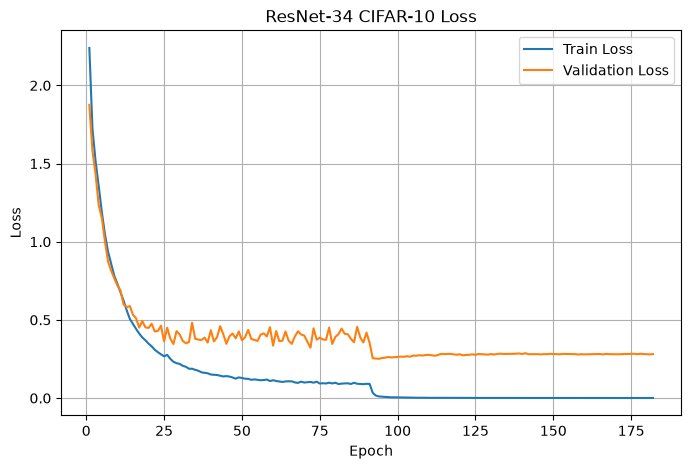

In [29]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet-34 CIFAR-10 Loss")

plt.legend()
plt.grid(True)
plt.show()

### 3.16 Teacher Accuracy Curves

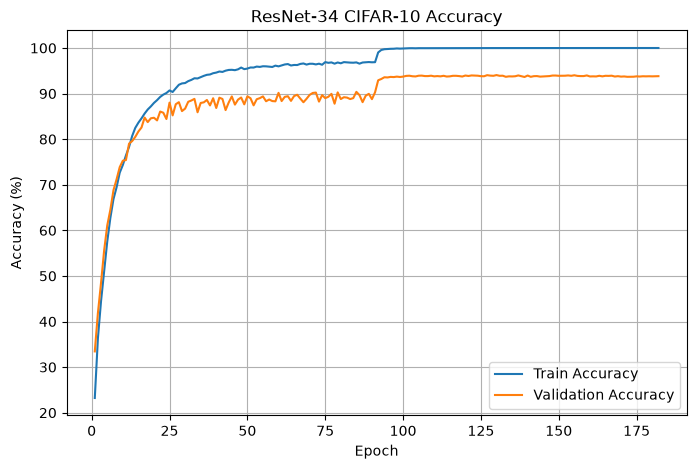

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet-34 CIFAR-10 Accuracy")

plt.legend()
plt.grid(True)
plt.show()

### 3.17 Teacher Training Summary

In [31]:
total_params = sum(
    p.numel() for p in teacher.parameters()
)

best_epoch = checkpoint["epoch"]
best_val_acc = checkpoint["val_acc"]

print("=" * 70)
print("RESNET-34 TEACHER SUMMARY")
print("=" * 70)

print(f"Architecture:          ResNet-34")
print(f"Dataset:               CIFAR-10")
print(f"Training epochs:       {NUM_EPOCHS}")
print(f"Training samples:      45,000")
print(f"Validation samples:    5,000")
print(f"Test samples:          10,000")
print(f"Batch size:            {BATCH_SIZE}")
print(f"Best epoch:            {best_epoch}")
print(f"Best validation acc:   {best_val_acc:.2f}%")
print(f"Test accuracy:         {teacher_test_acc:.2f}%")
print(f"Total parameters:      {total_params:,}")
print("=" * 70)

RESNET-34 TEACHER SUMMARY
Architecture:          ResNet-34
Dataset:               CIFAR-10
Training epochs:       182
Training samples:      45,000
Validation samples:    5,000
Test samples:          10,000
Batch size:            128
Best epoch:            130
Best validation acc:   94.06%
Test accuracy:         93.71%
Total parameters:      28,957,002


# 4. FP32 ResNet18 Student Baseline

## 4.1 Environment and Library Setup

In [19]:
import os
import random
import json

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Python executable:", __import__("sys").executable)

PyTorch: 2.7.1+cu126
Torchvision: 0.22.1+cu126
CUDA available: True
GPU: NVIDIA RTX 5000 Ada Generation
Python executable: /home/sem_7th/ATDL/env/bin/python


## 4.2 Reproducibility and Device Configuration

In [20]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


## 4.3 Project Directory Configuration

In [21]:
PROJECT_DIR = os.path.abspath(".")

DATA_DIR = os.path.join(
    PROJECT_DIR,
    "data"
)

CHECKPOINT_DIR = os.path.join(
    PROJECT_DIR,
    "checkpoints"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)
print("Checkpoint directory:", CHECKPOINT_DIR)
print("Results directory:", RESULTS_DIR)

Project directory: /home/sem_7th/ATDL
Data directory: /home/sem_7th/ATDL/data
Checkpoint directory: /home/sem_7th/ATDL/checkpoints
Results directory: /home/sem_7th/ATDL/results


In [22]:
BATCH_SIZE = 128

NUM_EPOCHS = 182

INITIAL_LR = 0.1
MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4

LR_MILESTONES = [91, 136]
LR_GAMMA = 0.1

NUM_CLASSES = 10

NUM_WORKERS = 0

print("Batch size:", BATCH_SIZE)
print("Epochs:", NUM_EPOCHS)
print("Initial LR:", INITIAL_LR)
print("Momentum:", MOMENTUM)
print("Weight decay:", WEIGHT_DECAY)
print("LR milestones:", LR_MILESTONES)

Batch size: 128
Epochs: 182
Initial LR: 0.1
Momentum: 0.9
Weight decay: 0.0001
LR milestones: [91, 136]


In [23]:
CIFAR10_MEAN = (
    0.4914,
    0.4822,
    0.4465
)

CIFAR10_STD = (
    0.2470,
    0.2435,
    0.2616
)

train_transform = transforms.Compose([
    transforms.RandomCrop(
        32,
        padding=4
    ),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(
        CIFAR10_MEAN,
        CIFAR10_STD
    )
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),

    transforms.Normalize(
        CIFAR10_MEAN,
        CIFAR10_STD
    )
])

print("Transforms created.")

Transforms created.


In [24]:
train_dataset_aug = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=train_transform
)

train_dataset_eval = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=True,
    download=False,
    transform=eval_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=eval_transform
)

print("Total training images:", len(train_dataset_aug))
print("Total test images:", len(test_dataset))

Total training images: 50000
Total test images: 10000


In [25]:
generator = torch.Generator().manual_seed(SEED)

indices = torch.randperm(
    len(train_dataset_aug),
    generator=generator
).tolist()

train_indices = indices[:45000]
val_indices = indices[45000:]

train_subset = Subset(
    train_dataset_aug,
    train_indices
)

val_subset = Subset(
    train_dataset_eval,
    val_indices
)

print("Training samples:", len(train_subset))
print("Validation samples:", len(val_subset))
print("Test samples:", len(test_dataset))

Training samples: 45000
Validation samples: 5000
Test samples: 10000


In [26]:
train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 352
Validation batches: 40
Test batches: 79


In [27]:
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Images shape: torch.Size([128, 3, 32, 32])
Labels shape: torch.Size([128])
Image dtype: torch.float32
Label dtype: torch.int64


In [28]:
class BasicBlock(nn.Module):

    expansion = 1

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1
    ):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(
            out_channels
        )

        self.relu = nn.ReLU(
            inplace=True
        )

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(
            out_channels
        )

        if (
            stride != 1
            or in_channels != out_channels
        ):
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),

                nn.BatchNorm2d(
                    out_channels
                )
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity

        out = self.relu(out)

        return out

In [29]:
class ResNet18CIFAR(nn.Module):

    def __init__(
        self,
        num_classes=10
    ):
        super().__init__()

        self.in_channels = 64

        # CIFAR-10 stem
        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64)

        self.relu = nn.ReLU(
            inplace=True
        )

        # ResNet-18
        self.layer1 = self._make_layer(
            64,
            blocks=2,
            stride=1
        )

        self.layer2 = self._make_layer(
            128,
            blocks=2,
            stride=2
        )

        self.layer3 = self._make_layer(
            256,
            blocks=2,
            stride=2
        )

        self.layer4 = self._make_layer(
            512,
            blocks=2,
            stride=2
        )

        self.avgpool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

        self.fc = nn.Linear(
            512,
            num_classes
        )

    def _make_layer(
        self,
        out_channels,
        blocks,
        stride
    ):

        layers = []

        layers.append(
            BasicBlock(
                self.in_channels,
                out_channels,
                stride
            )
        )

        self.in_channels = out_channels

        for _ in range(1, blocks):

            layers.append(
                BasicBlock(
                    out_channels,
                    out_channels,
                    stride=1
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        x = torch.flatten(
            x,
            1
        )

        x = self.fc(x)

        return x

In [30]:
student_fp32 = ResNet18CIFAR(
    num_classes=NUM_CLASSES
).to(device)

print(student_fp32)

ResNet18CIFAR(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stri

In [31]:
total_params = sum(
    p.numel()
    for p in student_fp32.parameters()
)

trainable_params = sum(
    p.numel()
    for p in student_fp32.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: {total_params:,}"
)

print(
    f"Trainable parameters: {trainable_params:,}"
)

Total parameters: 11,173,962
Trainable parameters: 11,173,962


In [32]:
student_fp32.eval()

with torch.no_grad():

    test_images = images.to(device)

    test_output = student_fp32(
        test_images
    )

print(
    "Input shape:",
    test_images.shape
)

print(
    "Output shape:",
    test_output.shape
)

Input shape: torch.Size([128, 3, 32, 32])
Output shape: torch.Size([128, 10])


In [33]:
criterion = nn.CrossEntropyLoss()

print(criterion)

CrossEntropyLoss()


In [34]:
optimizer = optim.SGD(
    student_fp32.parameters(),
    lr=INITIAL_LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

print(optimizer)

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0.0001
)


In [35]:
scheduler = optim.lr_scheduler.MultiStepLR(
    optimizer,
    milestones=LR_MILESTONES,
    gamma=LR_GAMMA
)

print(scheduler)

In [36]:
def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for inputs, targets in loader:

            inputs = inputs.to(
                device,
                non_blocking=True
            )

            targets = targets.to(
                device,
                non_blocking=True
            )

            outputs = model(inputs)

            loss = criterion(
                outputs,
                targets
            )

            running_loss += (
                loss.item()
                * inputs.size(0)
            )

            _, predicted = outputs.max(1)

            total += targets.size(0)

            correct += (
                predicted == targets
            ).sum().item()

    epoch_loss = (
        running_loss / total
    )

    epoch_acc = (
        100.0 * correct / total
    )

    return epoch_loss, epoch_acc

In [37]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in loader:

        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)

        loss = criterion(
            outputs,
            targets
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * inputs.size(0)
        )

        _, predicted = outputs.max(1)

        total += targets.size(0)

        correct += (
            predicted == targets
        ).sum().item()

    epoch_loss = running_loss / total

    epoch_acc = (
        100.0 * correct / total
    )

    return epoch_loss, epoch_acc

In [38]:
best_val_acc = 0.0

best_pth_path = os.path.join(
    CHECKPOINT_DIR,
    "resnet18_cifar10_fp32_best.pth"
)

best_pt_path = os.path.join(
    CHECKPOINT_DIR,
    "resnet18_cifar10_fp32_best.pt"
)

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "test_loss": [],
    "test_acc": [],
    "lr": []
}

print("Best PTH:")
print(best_pth_path)

print()

print("Best PT:")
print(best_pt_path)

Best PTH:
/home/sem_7th/ATDL/checkpoints/resnet18_cifar10_fp32_best.pth

Best PT:
/home/sem_7th/ATDL/checkpoints/resnet18_cifar10_fp32_best.pt


In [21]:
for epoch in range(NUM_EPOCHS):

    current_lr = optimizer.param_groups[0]["lr"]

    print()
    print("=" * 70)
    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"LR: {current_lr:.6f}"
    )
    print("=" * 70)

    # -------------------------
    # Training
    # -------------------------

    train_loss, train_acc = train_one_epoch(
        student_fp32,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # -------------------------
    # Validation
    # -------------------------

    val_loss, val_acc = evaluate(
        student_fp32,
        val_loader,
        criterion,
        device
    )

    # -------------------------
    # Test
    # -------------------------

    test_loss, test_acc = evaluate(
        student_fp32,
        test_loader,
        criterion,
        device
    )

    # -------------------------
    # Store history
    # -------------------------

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    history["lr"].append(current_lr)

    # -------------------------
    # Save best model
    # Based ONLY on validation accuracy
    # -------------------------

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        best_checkpoint = {
            "epoch": epoch + 1,

            "model_state_dict":
                student_fp32.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "val_acc": val_acc,
            "val_loss": val_loss,

            "test_acc": test_acc,
            "test_loss": test_loss
        }

        # Save best .pth
        torch.save(
            best_checkpoint,
            best_pth_path
        )

        # Save best .pt
        torch.save(
            best_checkpoint,
            best_pt_path
        )

        print(
            f"Best model saved | "
            f"Val Acc: {val_acc:.2f}%"
        )

    # -------------------------
    # Print results
    # -------------------------

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}%"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Val Acc:   {val_acc:.2f}%"
    )

    print(
        f"Test Loss:  {test_loss:.4f} | "
        f"Test Acc:  {test_acc:.2f}%"
    )

    # -------------------------
    # Update learning rate
    # -------------------------

    scheduler.step()

print()
print("=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)

print(
    f"Best validation accuracy: "
    f"{best_val_acc:.2f}%"
)


Epoch [1/182] | LR: 0.100000
Best model saved | Val Acc: 41.78%
Train Loss: 1.9713 | Train Acc: 30.70%
Val Loss:   1.5854 | Val Acc:   41.78%
Test Loss:  1.5759 | Test Acc:  41.71%

Epoch [2/182] | LR: 0.100000
Best model saved | Val Acc: 47.74%
Train Loss: 1.4860 | Train Acc: 45.10%
Val Loss:   1.4355 | Val Acc:   47.74%
Test Loss:  1.4289 | Test Acc:  48.09%

Epoch [3/182] | LR: 0.100000
Best model saved | Val Acc: 59.06%
Train Loss: 1.2490 | Train Acc: 54.47%
Val Loss:   1.1005 | Val Acc:   59.06%
Test Loss:  1.1074 | Test Acc:  59.35%

Epoch [4/182] | LR: 0.100000
Best model saved | Val Acc: 65.44%
Train Loss: 1.0440 | Train Acc: 62.59%
Val Loss:   0.9799 | Val Acc:   65.44%
Test Loss:  0.9942 | Test Acc:  64.81%

Epoch [5/182] | LR: 0.100000
Best model saved | Val Acc: 67.92%
Train Loss: 0.9013 | Train Acc: 68.21%
Val Loss:   0.9377 | Val Acc:   67.92%
Test Loss:  0.9352 | Test Acc:  68.10%

Epoch [6/182] | LR: 0.100000
Train Loss: 0.7959 | Train Acc: 71.83%
Val Loss:   1.0185 | 

In [22]:
best_checkpoint = torch.load(
    best_pth_path,
    map_location=device
)

student_fp32.load_state_dict(
    best_checkpoint["model_state_dict"]
)

student_fp32 = student_fp32.to(device)

student_fp32.eval()

print(
    f"Best epoch: "
    f"{best_checkpoint['epoch']}"
)

print(
    f"Best validation accuracy: "
    f"{best_checkpoint['val_acc']:.2f}%"
)

Best epoch: 136
Best validation accuracy: 94.70%


In [23]:
test_loss, test_acc = evaluate(
    student_fp32,
    test_loader,
    criterion,
    device
)

print("=" * 60)
print("FP32 RESNET-18 BASELINE — FINAL TEST RESULT")
print("=" * 60)

print(
    f"Test Loss:     {test_loss:.4f}"
)

print(
    f"Test Accuracy: {test_acc:.2f}%"
)

FP32 RESNET-18 BASELINE — FINAL TEST RESULT
Test Loss:     0.2708
Test Accuracy: 93.94%


In [24]:
fp32_pth_path = os.path.join(
    CHECKPOINT_DIR,
    "resnet18_cifar10_fp32_final.pth"
)

fp32_pt_path = os.path.join(
    CHECKPOINT_DIR,
    "resnet18_cifar10_fp32_final.pt"
)

torch.save(
    student_fp32.state_dict(),
    fp32_pth_path
)

torch.save(
    student_fp32.state_dict(),
    fp32_pt_path
)

print("FP32 model saved:")
print(fp32_pth_path)
print(fp32_pt_path)

FP32 model saved:
/home/sem_7th/ATDL/checkpoints/resnet18_cifar10_fp32_final.pth
/home/sem_7th/ATDL/checkpoints/resnet18_cifar10_fp32_final.pt


In [25]:
history_path = os.path.join(
    RESULTS_DIR,
    "resnet18_fp32_training_history.json"
)

with open(history_path, "w") as f:

    json.dump(
        history,
        f,
        indent=4
    )

print("Training history saved:")
print(history_path)

Training history saved:
/home/sem_7th/ATDL/results/resnet18_fp32_training_history.json


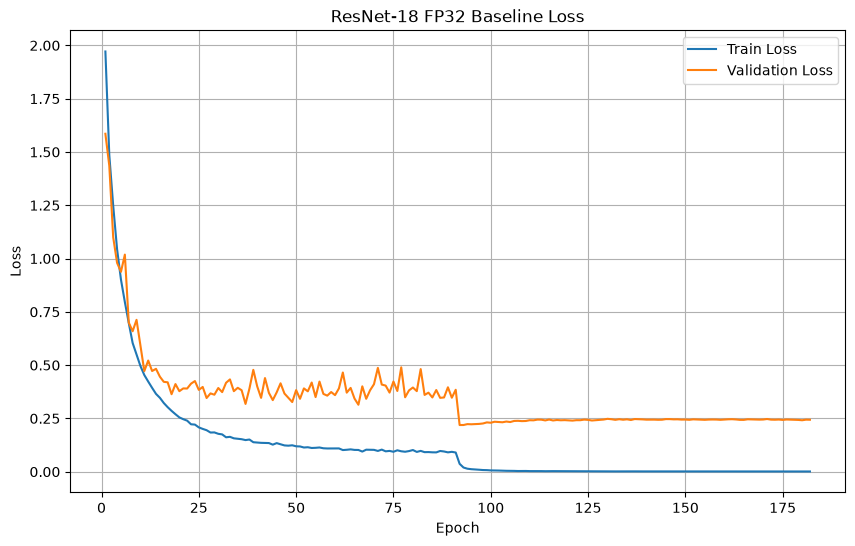

In [26]:
epochs = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "ResNet-18 FP32 Baseline Loss"
)

plt.legend()
plt.grid(True)

plt.show()

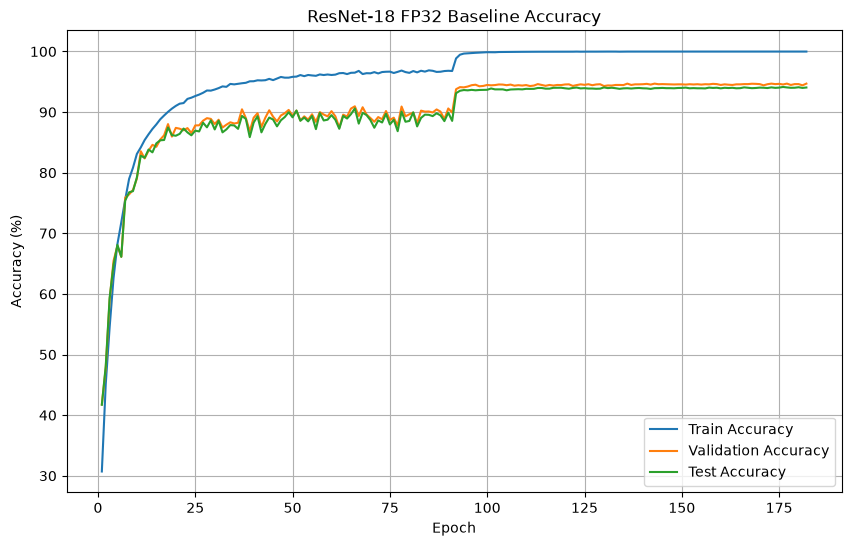

In [27]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_acc"],
    label="Validation Accuracy"
)

plt.plot(
    epochs,
    history["test_acc"],
    label="Test Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "ResNet-18 FP32 Baseline Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

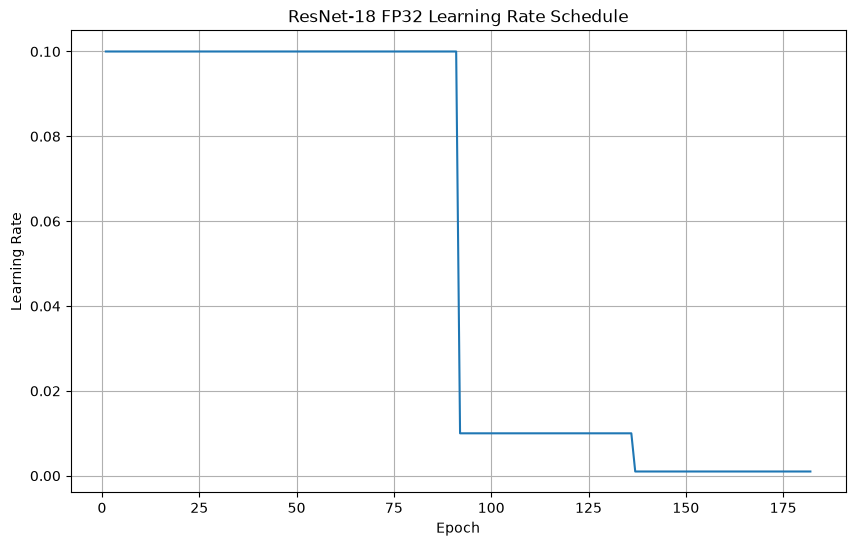

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["lr"]
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

plt.title(
    "ResNet-18 FP32 Learning Rate Schedule"
)

plt.grid(True)

plt.show()

In [29]:
num_parameters = sum(
    p.numel()
    for p in student_fp32.parameters()
)

fp32_size_bytes = (
    num_parameters * 4
)

fp32_size_mb = (
    fp32_size_bytes /
    (1024 ** 2)
)

print(
    f"Parameters: {num_parameters:,}"
)

print(
    f"Theoretical FP32 weight size: "
    f"{fp32_size_mb:.2f} MB"
)

Parameters: 11,173,962
Theoretical FP32 weight size: 42.63 MB


In [30]:
print("=" * 65)
print("FP32 RESNET-18 BASELINE SUMMARY")
print("=" * 65)

print(
    f"Architecture       : CIFAR-adapted ResNet-18"
)

print(
    f"Training samples   : 45,000"
)

print(
    f"Validation samples : 5,000"
)

print(
    f"Test samples       : 10,000"
)

print(
    f"Epochs             : {NUM_EPOCHS}"
)

print(
    f"Batch size         : {BATCH_SIZE}"
)

print(
    f"Initial LR         : {INITIAL_LR}"
)

print(
    f"Momentum           : {MOMENTUM}"
)

print(
    f"Weight decay       : {WEIGHT_DECAY}"
)

print(
    f"LR milestones      : {LR_MILESTONES}"
)

print(
    f"Best Val Accuracy  : "
    f"{best_val_acc:.2f}%"
)

print(
    f"Final Test Accuracy: "
    f"{test_acc:.2f}%"
)

print(
    f"Parameters         : "
    f"{num_parameters:,}"
)

print(
    f"FP32 weight size   : "
    f"{fp32_size_mb:.2f} MB"
)

print()
print("Best checkpoint files:")
print(best_pth_path)
print(best_pt_path)

print()
print("Final model files:")
print(fp32_pth_path)
print(fp32_pt_path)

FP32 RESNET-18 BASELINE SUMMARY
Architecture       : CIFAR-adapted ResNet-18
Training samples   : 45,000
Validation samples : 5,000
Test samples       : 10,000
Epochs             : 182
Batch size         : 128
Initial LR         : 0.1
Momentum           : 0.9
Weight decay       : 0.0001
LR milestones      : [91, 136]
Best Val Accuracy  : 94.70%
Final Test Accuracy: 93.94%
Parameters         : 11,173,962
FP32 weight size   : 42.63 MB

Best checkpoint files:
/home/sem_7th/ATDL/checkpoints/resnet18_cifar10_fp32_best.pth
/home/sem_7th/ATDL/checkpoints/resnet18_cifar10_fp32_best.pt

Final model files:
/home/sem_7th/ATDL/checkpoints/resnet18_cifar10_fp32_final.pth
/home/sem_7th/ATDL/checkpoints/resnet18_cifar10_fp32_final.pt


In [ ]:
#Ternary Student Resnet18_Cifar10

In [39]:
# ============================================================
# TERNARY + KNOWLEDGE DISTILLATION STUDENT
# ============================================================

T = 4.0
LAMBDA_KD = 0.5

print("KD Temperature (T):", T)
print("KD Weight (lambda):", LAMBDA_KD)

KD Temperature (T): 4.0
KD Weight (lambda): 0.5


In [40]:
teacher = ResNet34CIFAR(
    num_classes=NUM_CLASSES
).to(device)

print("Teacher architecture recreated.")

Teacher architecture recreated.


In [41]:
teacher_path = os.path.join(
    CHECKPOINT_DIR,
    "resnet34_cifar10_teacher_final.pt"
)

print("Loading teacher from:")
print(teacher_path)

teacher.load_state_dict(
    torch.load(
        teacher_path,
        map_location=device
    )
)

teacher = teacher.to(device)

print("Teacher loaded successfully.")

Loading teacher from:
/home/sem_7th/ATDL/checkpoints/resnet34_cifar10_teacher_final.pt
Teacher loaded successfully.


In [42]:
teacher.eval()

for param in teacher.parameters():
    param.requires_grad = False

print("Teacher frozen.")

trainable_teacher_params = sum(
    p.numel()
    for p in teacher.parameters()
    if p.requires_grad
)

print(
    "Trainable teacher parameters:",
    trainable_teacher_params
)

Teacher frozen.
Trainable teacher parameters: 0


In [43]:
teacher.eval()

with torch.no_grad():

    sample_images = images.to(device)

    teacher_logits = teacher(
        sample_images
    )

print("Teacher logits shape:")
print(teacher_logits.shape)

print("Teacher logits:")
print(teacher_logits[:2])

Teacher logits shape:
torch.Size([128, 10])
Teacher logits:
tensor([[-1.0592, -2.3231, -0.0490, 13.4736, -1.1174, -2.2538, -0.5866, -1.4586,
         -2.0439, -2.5639],
        [-3.5405, -1.7126, -1.2494, -0.2797, -1.4488,  0.2311, 14.9635, -1.5995,
         -1.9125, -3.4668]], device='cuda:0')


In [44]:
def ternary_quantize(weight):

    # --------------------------------------------------------
    # Threshold
    # --------------------------------------------------------

    delta = 0.7 * weight.abs().mean()

    # --------------------------------------------------------
    # Select weights that become non-zero
    # --------------------------------------------------------

    mask = weight.abs() > delta

    # --------------------------------------------------------
    # Scale of non-zero weights
    # --------------------------------------------------------

    if mask.any():
        alpha = weight.abs()[mask].mean()
    else:
        alpha = weight.abs().mean()

    # --------------------------------------------------------
    # Ternary values
    # --------------------------------------------------------

    quantized = torch.where(
        weight > delta,
        alpha,
        torch.where(
            weight < -delta,
            -alpha,
            torch.zeros_like(weight)
        )
    )

    return quantized, alpha, delta

In [45]:
test_weights = torch.tensor([
    -0.90,
    -0.60,
    -0.10,
     0.00,
     0.05,
     0.40,
     0.80
], device=device)

quantized, alpha_test, delta_test = ternary_quantize(
    test_weights
)

print("Original:")
print(test_weights)

print("\nQuantized:")
print(quantized)

print("\nAlpha:")
print(alpha_test.item())

print("\nDelta:")
print(delta_test.item())

print("\nUnique quantized values:")
print(torch.unique(quantized))

Original:
tensor([-0.9000, -0.6000, -0.1000,  0.0000,  0.0500,  0.4000,  0.8000],
       device='cuda:0')

Quantized:
tensor([-0.6750, -0.6750,  0.0000,  0.0000,  0.0000,  0.6750,  0.6750],
       device='cuda:0')

Alpha:
0.675000011920929

Delta:
0.2850000262260437

Unique quantized values:
tensor([-0.6750,  0.0000,  0.6750], device='cuda:0')


In [46]:
zero_fraction = (
    quantized == 0
).float().mean().item()

sparsity = 100.0 * zero_fraction

print(
    f"Ternary sparsity: {sparsity:.2f}%"
)

Ternary sparsity: 42.86%


In [47]:
def ternary_quantize_ste(weight):

    quantized, alpha, delta = ternary_quantize(
        weight
    )

    # Straight-Through Estimator:
    # forward  -> quantized
    # backward -> identity

    quantized_ste = (
        weight
        + (quantized - weight).detach()
    )

    return quantized_ste, alpha, delta

In [48]:
test_weight = torch.randn(
    20,
    device=device,
    requires_grad=True
)

q_weight, alpha_test, delta_test = (
    ternary_quantize_ste(test_weight)
)

loss_test = q_weight.sum()

loss_test.backward()

print("Latent weights:")
print(test_weight[:10])

print("\nQuantized weights:")
print(q_weight[:10])

print("\nGradient:")
print(test_weight.grad[:10])

print(
    "\nGradient exists:",
    test_weight.grad is not None
)

Latent weights:
tensor([ 0.1940,  2.1614, -0.1721,  0.8491, -1.9244,  0.6530, -0.6494, -0.8175,
         0.5280, -1.2753], device='cuda:0', grad_fn=<SliceBackward0>)

Quantized weights:
tensor([ 0.0000,  1.1669,  0.0000,  1.1669, -1.1669,  1.1669, -1.1669, -1.1669,
         0.0000, -1.1669], device='cuda:0', grad_fn=<SliceBackward0>)

Gradient:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0')

Gradient exists: True


In [49]:
class TernaryConv2d(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        stride=1,
        padding=0,
        bias=False
    ):
        super().__init__()

        self.weight = nn.Parameter(
            torch.empty(
                out_channels,
                in_channels,
                kernel_size,
                kernel_size
            )
        )

        nn.init.kaiming_normal_(
            self.weight,
            mode="fan_out",
            nonlinearity="relu"
        )

        self.stride = stride
        self.padding = padding

        if bias:
            self.bias = nn.Parameter(
                torch.zeros(out_channels)
            )
        else:
            self.bias = None

    def forward(self, x):

        quantized_weight, alpha, delta = (
            ternary_quantize_ste(
                self.weight
            )
        )

        return nn.functional.conv2d(
            x,
            quantized_weight,
            self.bias,
            stride=self.stride,
            padding=self.padding
        )

In [50]:
test_conv = TernaryConv2d(
    3,
    16,
    kernel_size=3,
    padding=1
).to(device)

test_input = torch.randn(
    4,
    3,
    32,
    32,
    device=device
)

test_output = test_conv(
    test_input
)

print("Output shape:")
print(test_output.shape)

print(
    "Latent weight dtype:",
    test_conv.weight.dtype
)

Output shape:
torch.Size([4, 16, 32, 32])
Latent weight dtype: torch.float32


In [51]:
class TernaryLinear(nn.Module):

    def __init__(
        self,
        in_features,
        out_features,
        bias=True
    ):
        super().__init__()

        self.weight = nn.Parameter(
            torch.empty(
                out_features,
                in_features
            )
        )

        nn.init.kaiming_normal_(
            self.weight,
            mode="fan_out",
            nonlinearity="relu"
        )

        if bias:
            self.bias = nn.Parameter(
                torch.zeros(out_features)
            )
        else:
            self.bias = None

    def forward(self, x):

        quantized_weight, alpha, delta = (
            ternary_quantize_ste(
                self.weight
            )
        )

        return nn.functional.linear(
            x,
            quantized_weight,
            self.bias
        )

In [52]:
class TernaryBasicBlock(nn.Module):

    expansion = 1

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=1
    ):
        super().__init__()

        # Ternary convolution
        self.conv1 = TernaryConv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        # BatchNorm remains FP32
        self.bn1 = nn.BatchNorm2d(
            out_channels
        )

        self.relu = nn.ReLU(
            inplace=True
        )

        # Ternary convolution
        self.conv2 = TernaryConv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        # BatchNorm remains FP32
        self.bn2 = nn.BatchNorm2d(
            out_channels
        )

        # Projection shortcut remains FP32
        if (
            stride != 1
            or in_channels != out_channels
        ):
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(
                    out_channels
                )
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):

        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out

In [53]:
class TernaryResNet18CIFAR(nn.Module):

    def __init__(self, num_classes=10):

        super().__init__()

        self.in_channels = 64

        # Ternary stem
        self.conv1 = TernaryConv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        # FP32 BatchNorm
        self.bn1 = nn.BatchNorm2d(64)

        self.relu = nn.ReLU(
            inplace=True
        )

        self.layer1 = self._make_layer(
            64,
            blocks=2,
            stride=1
        )

        self.layer2 = self._make_layer(
            128,
            blocks=2,
            stride=2
        )

        self.layer3 = self._make_layer(
            256,
            blocks=2,
            stride=2
        )

        self.layer4 = self._make_layer(
            512,
            blocks=2,
            stride=2
        )

        self.avgpool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

        # Ternary FC
        self.fc = TernaryLinear(
            512,
            num_classes
        )

    def _make_layer(
        self,
        out_channels,
        blocks,
        stride
    ):

        layers = []

        layers.append(
            TernaryBasicBlock(
                self.in_channels,
                out_channels,
                stride
            )
        )

        self.in_channels = out_channels

        for _ in range(1, blocks):

            layers.append(
                TernaryBasicBlock(
                    out_channels,
                    out_channels,
                    stride=1
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)

        x = torch.flatten(
            x,
            1
        )

        x = self.fc(x)

        return x

In [54]:
ternary_student = TernaryResNet18CIFAR(
    num_classes=NUM_CLASSES
).to(device)

print(ternary_student)

TernaryResNet18CIFAR(
  (conv1): TernaryConv2d()
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): TernaryBasicBlock(
      (conv1): TernaryConv2d()
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): TernaryConv2d()
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
    (1): TernaryBasicBlock(
      (conv1): TernaryConv2d()
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): TernaryConv2d()
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Identity()
    )
  )
  (layer2): Sequential(
    (0): TernaryBasicBlock(
      (conv1): TernaryConv2d()
      (bn1): BatchNorm2d(128, eps=

In [55]:
ternary_student.eval()

with torch.no_grad():

    student_logits = ternary_student(
        images.to(device)
    )

print("Student logits shape:")
print(student_logits.shape)

Student logits shape:
torch.Size([128, 10])


In [56]:
# Check the first ternary convolution
layer = ternary_student.conv1

latent_weight = layer.weight.detach()

quantized_weight, alpha, delta = (
    ternary_quantize(
        latent_weight
    )
)

print("Latent dtype:", latent_weight.dtype)

print("Alpha:", alpha.item())
print("Delta:", delta.item())

print(
    "Unique ternary values:",
    torch.unique(quantized_weight)
)

Latent dtype: torch.float32
Alpha: 0.07045888155698776
Delta: 0.03314875066280365
Unique ternary values: tensor([-0.0705,  0.0000,  0.0705], device='cuda:0')


In [57]:
def calculate_ternary_sparsity(model):

    total = 0
    zeros = 0

    for module in model.modules():

        if isinstance(
            module,
            (TernaryConv2d, TernaryLinear)
        ):

            with torch.no_grad():

                q_weight, _, _ = (
                    ternary_quantize(
                        module.weight
                    )
                )

            total += q_weight.numel()

            zeros += (
                q_weight == 0
            ).sum().item()

    sparsity = (
        100.0 * zeros / total
    )

    return sparsity

In [58]:
initial_sparsity = calculate_ternary_sparsity(
    ternary_student
)

print(
    f"Initial ternary sparsity: "
    f"{initial_sparsity:.2f}%"
)

Initial ternary sparsity: 42.34%


In [59]:
teacher.eval()

for param in teacher.parameters():
    param.requires_grad = False

print(
    "Teacher training mode:",
    teacher.training
)

print(
    "Teacher trainable parameters:",
    sum(
        p.numel()
        for p in teacher.parameters()
        if p.requires_grad
    )
)

Teacher training mode: False
Teacher trainable parameters: 0


In [60]:
def knowledge_distillation_loss(
    student_logits,
    teacher_logits,
    temperature
):

    student_log_probs = nn.functional.log_softmax(
        student_logits / temperature,
        dim=1
    )

    teacher_probs = nn.functional.softmax(
        teacher_logits / temperature,
        dim=1
    )

    kd_loss = nn.functional.kl_div(
        student_log_probs,
        teacher_probs,
        reduction="batchmean"
    )

    kd_loss = kd_loss * (
        temperature ** 2
    )

    return kd_loss

In [61]:
ternary_student.train()
teacher.eval()

batch_images = images.to(
    device,
    non_blocking=True
)

batch_labels = labels.to(
    device,
    non_blocking=True
)

# Teacher: NO gradients
with torch.no_grad():

    teacher_logits = teacher(
        batch_images
    )

# Student: ternary forward
student_logits = ternary_student(
    batch_images
)

# Hard-label loss
ce_loss = nn.functional.cross_entropy(
    student_logits,
    batch_labels
)

# KD loss
kd_loss = knowledge_distillation_loss(
    student_logits,
    teacher_logits,
    T
)

# Combined loss
total_loss = (
    (1 - LAMBDA_KD) * ce_loss
    + LAMBDA_KD * kd_loss
)

print("CE loss:", ce_loss.item())
print("KD loss:", kd_loss.item())
print("Total loss:", total_loss.item())

CE loss: 16.605443954467773
KD loss: 55.17604446411133
Total loss: 35.890743255615234


In [62]:
# Backpropagate one test batch
total_loss.backward()

student_gradients = sum(
    p.grad is not None
    for p in ternary_student.parameters()
    if p.requires_grad
)

teacher_gradients = sum(
    p.grad is not None
    for p in teacher.parameters()
)

print(
    "Student parameters with gradients:",
    student_gradients
)

print(
    "Teacher parameters with gradients:",
    teacher_gradients
)

Student parameters with gradients: 62
Teacher parameters with gradients: 0


In [63]:
ternary_student.zero_grad(set_to_none=True)

print("Test gradients cleared.")

Test gradients cleared.


In [64]:
QAT_LR = 0.1

optimizer_ternary = optim.SGD(
    ternary_student.parameters(),
    lr=QAT_LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

print("Optimizer: SGD")
print("Learning rate:", QAT_LR)
print("Momentum:", MOMENTUM)
print("Weight decay:", WEIGHT_DECAY)

Optimizer: SGD
Learning rate: 0.1
Momentum: 0.9
Weight decay: 0.0001


In [65]:
scheduler_ternary = optim.lr_scheduler.MultiStepLR(
    optimizer_ternary,
    milestones=LR_MILESTONES,
    gamma=LR_GAMMA
)

print("Scheduler created.")

Scheduler created.


In [66]:
def train_one_epoch_kd(
    student,
    teacher,
    loader,
    optimizer,
    device,
    temperature,
    lambda_kd
):

    student.train()
    teacher.eval()

    running_total_loss = 0.0
    running_ce_loss = 0.0
    running_kd_loss = 0.0

    correct = 0
    total = 0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for inputs, targets in progress_bar:

        inputs = inputs.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # --------------------------------------------------
        # Teacher forward
        # --------------------------------------------------

        with torch.no_grad():

            teacher_logits = teacher(
                inputs
            )

        # --------------------------------------------------
        # Student forward
        # IMPORTANT:
        # Ternary weights are used internally.
        # --------------------------------------------------

        student_logits = student(
            inputs
        )

        # --------------------------------------------------
        # Hard-label CE
        # --------------------------------------------------

        ce_loss = nn.functional.cross_entropy(
            student_logits,
            targets
        )

        # --------------------------------------------------
        # Temperature-scaled KD
        # --------------------------------------------------

        kd_loss = knowledge_distillation_loss(
            student_logits,
            teacher_logits,
            temperature
        )

        # --------------------------------------------------
        # Combined loss
        # --------------------------------------------------

        loss = (
            (1.0 - lambda_kd) * ce_loss
            + lambda_kd * kd_loss
        )

        # --------------------------------------------------
        # Backpropagation through STE
        # --------------------------------------------------

        loss.backward()

        optimizer.step()

        # --------------------------------------------------
        # Statistics
        # --------------------------------------------------

        batch_size = inputs.size(0)

        running_total_loss += (
            loss.item() * batch_size
        )

        running_ce_loss += (
            ce_loss.item() * batch_size
        )

        running_kd_loss += (
            kd_loss.item() * batch_size
        )

        _, predicted = student_logits.max(1)

        total += batch_size

        correct += (
            predicted == targets
        ).sum().item()

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            ce=f"{ce_loss.item():.4f}",
            kd=f"{kd_loss.item():.4f}"
        )

    epoch_loss = (
        running_total_loss / total
    )

    epoch_ce = (
        running_ce_loss / total
    )

    epoch_kd = (
        running_kd_loss / total
    )

    epoch_acc = (
        100.0 * correct / total
    )

    return (
        epoch_loss,
        epoch_ce,
        epoch_kd,
        epoch_acc
    )

In [67]:
def evaluate_ternary(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    correct = 0
    total = 0

    with torch.no_grad():

        for inputs, targets in loader:

            inputs = inputs.to(
                device,
                non_blocking=True
            )

            targets = targets.to(
                device,
                non_blocking=True
            )

            outputs = model(inputs)

            loss = criterion(
                outputs,
                targets
            )

            batch_size = inputs.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            _, predicted = outputs.max(1)

            total += batch_size

            correct += (
                predicted == targets
            ).sum().item()

    loss = running_loss / total

    accuracy = (
        100.0 * correct / total
    )

    return loss, accuracy

In [68]:
ternary_best_checkpoint = os.path.join(
    CHECKPOINT_DIR,
    "resnet18_cifar10_ternary_kd_best.pth"
)

ternary_history = {
    "train_loss": [],
    "train_ce": [],
    "train_kd": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": [],
    "sparsity": []
}

best_ternary_val_acc = 0.0

print(
    "Checkpoint:",
    ternary_best_checkpoint
)

Checkpoint: /home/sem_7th/ATDL/checkpoints/resnet18_cifar10_ternary_kd_best.pth


In [69]:
# CELL 61A
# Reset the Ternary + KD student for a fresh 182-epoch run

ternary_student = TernaryResNet18CIFAR(
    num_classes=NUM_CLASSES
).to(device)

optimizer_ternary = optim.SGD(
    ternary_student.parameters(),
    lr=QAT_LR,
    momentum=0.9,
    weight_decay=1e-4
)

scheduler_ternary = optim.lr_scheduler.MultiStepLR(
    optimizer_ternary,
    milestones=[91, 136],
    gamma=0.1
)

ternary_history = {
    "train_loss": [],
    "train_ce": [],
    "train_kd": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": [],
    "sparsity": []
}

best_ternary_val_acc = 0.0

print("Ternary + KD student reset.")
print("Starting a fresh 182-epoch training run.")
print(f"Initial learning rate: {QAT_LR}")

Ternary + KD student reset.
Starting a fresh 182-epoch training run.
Initial learning rate: 0.1


In [70]:
# CELL 61B

for epoch in range(NUM_EPOCHS):

    current_lr = optimizer_ternary.param_groups[0]["lr"]

    print()
    print("=" * 75)
    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"| LR: {current_lr:.6f}"
    )
    print("=" * 75)

    # ======================================================
    # TRAIN
    # ======================================================

    (
        train_loss,
        train_ce,
        train_kd,
        train_acc
    ) = train_one_epoch_kd(
        student=ternary_student,
        teacher=teacher,
        loader=train_loader,
        optimizer=optimizer_ternary,
        device=device,
        temperature=T,
        lambda_kd=LAMBDA_KD
    )

    # ======================================================
    # VALIDATION
    # ======================================================

    val_loss, val_acc = evaluate_ternary(
        model=ternary_student,
        loader=val_loader,
        criterion=criterion,
        device=device
    )

    # ======================================================
    # SPARSITY
    # ======================================================

    sparsity = calculate_ternary_sparsity(
        ternary_student
    )

    # ======================================================
    # SAVE HISTORY
    # ======================================================

    ternary_history["train_loss"].append(
        train_loss
    )

    ternary_history["train_ce"].append(
        train_ce
    )

    ternary_history["train_kd"].append(
        train_kd
    )

    ternary_history["train_acc"].append(
        train_acc
    )

    ternary_history["val_loss"].append(
        val_loss
    )

    ternary_history["val_acc"].append(
        val_acc
    )

    ternary_history["lr"].append(
        current_lr
    )

    ternary_history["sparsity"].append(
        sparsity
    )

    # ======================================================
    # SAVE BEST MODEL
    # ======================================================

    if val_acc > best_ternary_val_acc:

        best_ternary_val_acc = val_acc

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict":
                    ternary_student.state_dict(),
                "optimizer_state_dict":
                    optimizer_ternary.state_dict(),
                "scheduler_state_dict":
                    scheduler_ternary.state_dict(),
                "val_acc": val_acc,
                "val_loss": val_loss,
                "temperature": T,
                "lambda_kd": LAMBDA_KD,
                "ternary_history": ternary_history
            },
            ternary_best_checkpoint
        )

        print(
            f"Best ternary model saved! "
            f"Val Acc: {val_acc:.2f}%"
        )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train CE:   {train_ce:.4f}"
    )

    print(
        f"Train KD:   {train_kd:.4f}"
    )

    print(
        f"Train Acc:  {train_acc:.2f}%"
    )

    print(
        f"Val Loss:   {val_loss:.4f}"
    )

    print(
        f"Val Acc:    {val_acc:.2f}%"
    )

    print(
        f"Sparsity:   {sparsity:.2f}%"
    )

    # ======================================================
    # LR UPDATE
    # ======================================================

    scheduler_ternary.step()


# ==========================================================
# SAVE FINAL MODEL WITH COMPLETE 182-EPOCH HISTORY
# ==========================================================

torch.save(
    {
        "epoch": NUM_EPOCHS,
        "model_state_dict":
            ternary_student.state_dict(),
        "optimizer_state_dict":
            optimizer_ternary.state_dict(),
        "scheduler_state_dict":
            scheduler_ternary.state_dict(),
        "val_acc":
            ternary_history["val_acc"][-1],
        "val_loss":
            ternary_history["val_loss"][-1],
        "temperature":
            T,
        "lambda_kd":
            LAMBDA_KD,
        "ternary_history":
            ternary_history
    },
    ternary_final_checkpoint
)

print()
print("=" * 75)
print("TERNARY + KD TRAINING COMPLETE")
print("=" * 75)

print(
    f"Best validation accuracy: "
    f"{best_ternary_val_acc:.2f}%"
)

print(
    f"Final validation accuracy: "
    f"{ternary_history['val_acc'][-1]:.2f}%"
)

print(
    f"Total epochs stored: "
    f"{len(ternary_history['train_loss'])}"
)

print(
    f"Final sparsity: "
    f"{ternary_history['sparsity'][-1]:.2f}%"
)

print(
    f"Final checkpoint saved to: "
    f"{ternary_final_checkpoint}"
)


Epoch [1/182] | LR: 0.100000


Training:   0%|          | 0/352 [00:00<?, ?it/s]

Best ternary model saved! Val Acc: 29.94%
Train Loss: 12.5550
Train CE:   3.0879
Train KD:   22.0222
Train Acc:  20.59%
Val Loss:   2.1531
Val Acc:    29.94%
Sparsity:   46.50%

Epoch [2/182] | LR: 0.100000


Training:   0%|          | 0/352 [00:00<?, ?it/s]

Best ternary model saved! Val Acc: 37.04%
Train Loss: 9.2027
Train CE:   2.1602
Train KD:   16.2453
Train Acc:  34.27%
Val Loss:   2.1239
Val Acc:    37.04%
Sparsity:   46.48%

Epoch [3/182] | LR: 0.100000


...

Training:   0%|          | 0/352 [00:00<?, ?it/s]

Train Loss: 0.1256
Train CE:   0.0018
Train KD:   0.2493
Train Acc:  99.93%
Val Loss:   0.3413
Val Acc:    93.82%
Sparsity:   64.17%

Epoch [182/182] | LR: 0.001000


Training:   0%|          | 0/352 [00:00<?, ?it/s]

Train Loss: 0.1258
Train CE:   0.0022
Train KD:   0.2494
Train Acc:  99.94%
Val Loss:   0.3441
Val Acc:    93.74%
Sparsity:   64.17%


NameError: name 'ternary_final_checkpoint' is not defined

In [71]:
# CELL 61C

ternary_final_checkpoint = os.path.join(
    CHECKPOINT_DIR,
    "resnet18_cifar10_ternary_kd_final.pth"
)

print(f"Final checkpoint path: {ternary_final_checkpoint}")

Final checkpoint path: /home/sem_7th/ATDL/checkpoints/resnet18_cifar10_ternary_kd_final.pth


In [72]:
# CELL 61D

torch.save(
    {
        "epoch": NUM_EPOCHS,
        "model_state_dict":
            ternary_student.state_dict(),
        "optimizer_state_dict":
            optimizer_ternary.state_dict(),
        "scheduler_state_dict":
            scheduler_ternary.state_dict(),
        "val_acc":
            ternary_history["val_acc"][-1],
        "val_loss":
            ternary_history["val_loss"][-1],
        "temperature":
            T,
        "lambda_kd":
            LAMBDA_KD,
        "ternary_history":
            ternary_history
    },
    ternary_final_checkpoint
)

print()
print("=" * 75)
print("FINAL TERNARY + KD CHECKPOINT SAVED")
print("=" * 75)

print(
    f"Epochs stored: "
    f"{len(ternary_history['train_loss'])}"
)

print(
    f"Final validation accuracy: "
    f"{ternary_history['val_acc'][-1]:.2f}%"
)

print(
    f"Final sparsity: "
    f"{ternary_history['sparsity'][-1]:.2f}%"
)

print(
    f"Saved to: {ternary_final_checkpoint}"
)


FINAL TERNARY + KD CHECKPOINT SAVED
Epochs stored: 182
Final validation accuracy: 93.74%
Final sparsity: 64.17%
Saved to: /home/sem_7th/ATDL/checkpoints/resnet18_cifar10_ternary_kd_final.pth


In [73]:
# CELL 62
# Load the best Ternary + KD model based on validation accuracy

best_ternary_checkpoint = os.path.join(
    CHECKPOINT_DIR,
    "resnet18_cifar10_ternary_kd_best.pth"
)

checkpoint = torch.load(
    best_ternary_checkpoint,
    map_location=device
)

ternary_student.load_state_dict(checkpoint["model_state_dict"])

print("Best ternary + KD checkpoint loaded.")
print(f"Best epoch: {checkpoint['epoch']}")
print(f"Best validation accuracy: {checkpoint['val_acc']:.2f}%")
print(f"Temperature (T): {checkpoint['temperature']}")
print(f"KD lambda: {checkpoint['lambda_kd']}")

Best ternary + KD checkpoint loaded.
Best epoch: 152
Best validation accuracy: 93.92%
Temperature (T): 4.0
KD lambda: 0.5


In [74]:
# CELL 63A
# Define CE criterion for evaluation

criterion_ce = nn.CrossEntropyLoss()

In [75]:
# CELL 63
# Final test evaluation for Ternary + KD student

test_loss_ternary, test_acc_ternary = evaluate_ternary(
    ternary_student,
    test_loader,
    criterion_ce,
    device
)

print("=" * 70)
print("TERNARY + KD TEST RESULTS")
print("=" * 70)
print(f"Test Loss:     {test_loss_ternary:.4f}")
print(f"Test Accuracy: {test_acc_ternary:.2f}%")
print("=" * 70)

TERNARY + KD TEST RESULTS
Test Loss:     0.3844
Test Accuracy: 93.21%


In [76]:
# CELL 64
# Verify that ternary layers produce only {-alpha, 0, +alpha}

print("=" * 70)
print("TERNARY WEIGHT VERIFICATION")
print("=" * 70)

all_ternary = True

for name, module in ternary_student.named_modules():
    if isinstance(module, (TernaryConv2d, TernaryLinear)):
        
        with torch.no_grad():
            q_weight, alpha, delta = ternary_quantize(module.weight)

        unique_values = torch.unique(q_weight)

        # Check that every value is either approximately
        # -alpha, 0, or +alpha
        valid = (
            torch.allclose(
                unique_values,
                unique_values.clamp(-alpha.item(), alpha.item()),
                atol=1e-6
            )
        )

        print(f"{name:40s} | "
              f"alpha={alpha.item():.6f} | "
              f"delta={delta.item():.6f} | "
              f"unique values={len(unique_values)}")

        print(f"    Values: {unique_values.detach().cpu().numpy()}")

print("=" * 70)

TERNARY WEIGHT VERIFICATION
conv1                                    | alpha=98.453743 | delta=21.856445 | unique values=3
    Values: [-98.45374   0.       98.45374]
layer1.0.conv1                           | alpha=0.156589 | delta=0.029935 | unique values=3
    Values: [-0.15658863  0.          0.15658863]
layer1.0.conv2                           | alpha=0.134200 | delta=0.029399 | unique values=3
    Values: [-0.1341998  0.         0.1341998]
layer1.1.conv1                           | alpha=0.168506 | delta=0.030246 | unique values=3
    Values: [-0.16850595  0.          0.16850595]
layer1.1.conv2                           | alpha=0.147809 | delta=0.031098 | unique values=3
    Values: [-0.14780858  0.          0.14780858]
layer2.0.conv1                           | alpha=0.115312 | delta=0.027763 | unique values=3
    Values: [-0.11531209  0.          0.11531209]
layer2.0.conv2                           | alpha=0.111882 | delta=0.029295 | unique values=3
    Values: [-0.11188216  0.

In [77]:
# CELL 65
# Rigorous verification: every quantized weight must be
# -alpha, 0, or +alpha

def verify_ternary_weights(model, tolerance=1e-6):
    total_weights = 0
    invalid_weights = 0

    for module in model.modules():
        if isinstance(module, (TernaryConv2d, TernaryLinear)):

            with torch.no_grad():
                q_weight, alpha, delta = ternary_quantize(module.weight)

            total_weights += q_weight.numel()

            valid_mask = (
                torch.isclose(
                    q_weight,
                    torch.zeros_like(q_weight),
                    atol=tolerance
                )
                |
                torch.isclose(
                    q_weight,
                    torch.full_like(q_weight, alpha.item()),
                    atol=tolerance
                )
                |
                torch.isclose(
                    q_weight,
                    torch.full_like(q_weight, -alpha.item()),
                    atol=tolerance
                )
            )

            invalid_weights += (~valid_mask).sum().item()

    return total_weights, invalid_weights


total_ternary_weights, invalid_ternary_weights = verify_ternary_weights(
    ternary_student
)

print("=" * 70)
print("TERNARY REPRESENTATION CHECK")
print("=" * 70)
print(f"Total ternary weights:   {total_ternary_weights:,}")
print(f"Invalid weight values:   {invalid_ternary_weights:,}")

if invalid_ternary_weights == 0:
    print("PASS: All quantized weights are {-alpha, 0, +alpha}.")
else:
    print("WARNING: Some weights are not ternary.")
print("=" * 70)

TERNARY REPRESENTATION CHECK
Total ternary weights:   10,992,320
Invalid weight values:   0
PASS: All quantized weights are {-alpha, 0, +alpha}.


In [78]:
# CELL 66
# Final sparsity of the best ternary + KD model

final_ternary_sparsity = calculate_ternary_sparsity(ternary_student)

print("=" * 70)
print("FINAL TERNARY SPARSITY")
print("=" * 70)
print(f"Ternary sparsity: {final_ternary_sparsity:.2f}%")
print(f"Non-zero weights: {100.0 - final_ternary_sparsity:.2f}%")
print("=" * 70)

FINAL TERNARY SPARSITY
Ternary sparsity: 64.16%
Non-zero weights: 35.84%


In [79]:
# CELL 67
# Parameter counts

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

def count_trainable_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


ternary_total_params = count_parameters(ternary_student)
ternary_trainable_params = count_trainable_parameters(ternary_student)

print("=" * 70)
print("TERNARY + KD PARAMETER COUNT")
print("=" * 70)
print(f"Total parameters:      {ternary_total_params:,}")
print(f"Trainable parameters:  {ternary_trainable_params:,}")
print("=" * 70)

TERNARY + KD PARAMETER COUNT
Total parameters:      11,173,962
Trainable parameters:  11,173,962


In [80]:
# CELL 68
# Separate ternary and FP32 parameters

ternary_param_count = 0
fp32_param_count = 0

for module in ternary_student.modules():

    if isinstance(module, (TernaryConv2d, TernaryLinear)):
        ternary_param_count += module.weight.numel()

        if module.bias is not None:
            fp32_param_count += module.bias.numel()

    elif isinstance(module, nn.BatchNorm2d):
        fp32_param_count += module.weight.numel()
        fp32_param_count += module.bias.numel()

    elif isinstance(module, nn.Conv2d):
        # These are our FP32 projection shortcuts
        fp32_param_count += sum(
            p.numel() for p in module.parameters()
        )

print("=" * 70)
print("PARAMETER BREAKDOWN")
print("=" * 70)
print(f"Ternary weight parameters: {ternary_param_count:,}")
print(f"FP32 parameters:           {fp32_param_count:,}")
print(f"Total accounted:           {ternary_param_count + fp32_param_count:,}")
print(f"Model total:               {ternary_total_params:,}")
print("=" * 70)

PARAMETER BREAKDOWN
Ternary weight parameters: 10,992,320
FP32 parameters:           181,642
Total accounted:           11,173,962
Model total:               11,173,962


In [81]:
# CELL 69
# Evaluate FP32 ResNet-18 baseline on the test set

fp32_student = ResNet18CIFAR(num_classes=NUM_CLASSES).to(device)

fp32_checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    "resnet18_cifar10_fp32_best.pth"
)

fp32_checkpoint = torch.load(
    fp32_checkpoint_path,
    map_location=device
)

fp32_student.load_state_dict(fp32_checkpoint["model_state_dict"])

fp32_student.eval()

test_loss_fp32 = 0.0
correct_fp32 = 0
total_fp32 = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = fp32_student(images)
        loss = criterion_ce(logits, labels)

        test_loss_fp32 += loss.item() * images.size(0)

        predictions = logits.argmax(dim=1)
        correct_fp32 += (predictions == labels).sum().item()
        total_fp32 += labels.size(0)

test_loss_fp32 /= total_fp32
test_acc_fp32 = 100.0 * correct_fp32 / total_fp32

print("=" * 70)
print("FP32 RESNET-18 TEST RESULTS")
print("=" * 70)
print(f"Test Loss:     {test_loss_fp32:.4f}")
print(f"Test Accuracy: {test_acc_fp32:.2f}%")
print("=" * 70)

FP32 RESNET-18 TEST RESULTS
Test Loss:     0.2708
Test Accuracy: 93.94%


In [82]:
# CELL 70
# Accuracy comparison

accuracy_difference = test_acc_fp32 - test_acc_ternary

print("=" * 70)
print("FP32 vs TERNARY + KD")
print("=" * 70)

print(f"FP32 ResNet-18 accuracy:       {test_acc_fp32:.2f}%")
print(f"Ternary + KD accuracy:         {test_acc_ternary:.2f}%")
print(f"Accuracy difference:            {accuracy_difference:.2f} percentage points")
print(f"Ternary sparsity:               {final_ternary_sparsity:.2f}%")

print("=" * 70)

FP32 vs TERNARY + KD
FP32 ResNet-18 accuracy:       93.94%
Ternary + KD accuracy:         93.21%
Accuracy difference:            0.73 percentage points
Ternary sparsity:               64.16%


In [83]:
# CELL 71
# FP32 storage estimate

fp32_model_params = count_parameters(fp32_student)

fp32_storage_bytes = fp32_model_params * 4
fp32_storage_mb = fp32_storage_bytes / (1024 ** 2)

print("=" * 70)
print("FP32 MODEL STORAGE")
print("=" * 70)
print(f"Parameters: {fp32_model_params:,}")
print(f"Storage:    {fp32_storage_mb:.2f} MB")
print("=" * 70)

FP32 MODEL STORAGE
Parameters: 11,173,962
Storage:    42.63 MB


In [84]:
# CELL 72
# Theoretical/practical ternary storage estimate
#
# Assumption:
#   2 bits per ternary weight
#   FP32 alpha stored separately for each ternary layer

ternary_weight_bits = ternary_param_count * 2
ternary_weight_bytes = ternary_weight_bits / 8

# Store one FP32 alpha per ternary layer
num_ternary_layers = sum(
    1
    for module in ternary_student.modules()
    if isinstance(module, (TernaryConv2d, TernaryLinear))
)

alpha_storage_bytes = num_ternary_layers * 4

# FP32 parameters that remain unquantized
fp32_remaining_bytes = fp32_param_count * 4

total_ternary_storage_bytes = (
    ternary_weight_bytes
    + alpha_storage_bytes
    + fp32_remaining_bytes
)

total_ternary_storage_mb = (
    total_ternary_storage_bytes / (1024 ** 2)
)

print("=" * 70)
print("TERNARY MODEL STORAGE ESTIMATE")
print("=" * 70)
print(f"Ternary weights:       {ternary_param_count:,}")
print(f"Ternary weight bits:   {ternary_weight_bits:,}")
print(f"FP32 remaining params: {fp32_param_count:,}")
print(f"Ternary layers:        {num_ternary_layers}")
print(f"Estimated storage:     {total_ternary_storage_mb:.2f} MB")
print("=" * 70)

TERNARY MODEL STORAGE ESTIMATE
Ternary weights:       10,992,320
Ternary weight bits:   21,984,640
FP32 remaining params: 181,642
Ternary layers:        18
Estimated storage:     3.31 MB


In [85]:
# CELL 73
# Compression ratio

compression_ratio = fp32_storage_bytes / total_ternary_storage_bytes
storage_reduction = (
    1.0 - total_ternary_storage_bytes / fp32_storage_bytes
) * 100.0

print("=" * 70)
print("COMPRESSION RESULTS")
print("=" * 70)
print(f"FP32 storage:              {fp32_storage_mb:.2f} MB")
print(f"Ternary storage estimate:  {total_ternary_storage_mb:.2f} MB")
print(f"Compression ratio:         {compression_ratio:.2f}x")
print(f"Storage reduction:         {storage_reduction:.2f}%")
print("=" * 70)

COMPRESSION RESULTS
FP32 storage:              42.63 MB
Ternary storage estimate:  3.31 MB
Compression ratio:         12.86x
Storage reduction:         92.23%


In [86]:
# CELL 74
# Final experiment summary

print("=" * 80)
print("FINAL CIFAR-10 RESNET COMPARISON")
print("=" * 80)

print(f"{'Metric':<35} {'FP32 ResNet-18':>20} {'Ternary + KD':>20}")
print("-" * 80)

print(
    f"{'Test Accuracy':<35} "
    f"{test_acc_fp32:>19.2f}% "
    f"{test_acc_ternary:>19.2f}%"
)

print(
    f"{'Sparsity':<35} "
    f"{0.0:>19.2f}% "
    f"{final_ternary_sparsity:>19.2f}%"
)

print(
    f"{'Parameters':<35} "
    f"{fp32_model_params:>20,} "
    f"{ternary_total_params:>20,}"
)

print(
    f"{'Estimated Storage (MB)':<35} "
    f"{fp32_storage_mb:>20.2f} "
    f"{total_ternary_storage_mb:>20.2f}"
)

print("=" * 80)

FINAL CIFAR-10 RESNET COMPARISON
Metric                                    FP32 ResNet-18         Ternary + KD
--------------------------------------------------------------------------------
Test Accuracy                                     93.94%               93.21%
Sparsity                                           0.00%               64.16%
Parameters                                    11,173,962           11,173,962
Estimated Storage (MB)                             42.63                 3.31


In [91]:
# CELL 75B
# Restore the saved Ternary + KD training history

history = checkpoint["ternary_history"]

print("Training history restored.")
print(history.keys())

for key in history.keys():
    print(
        f"{key}: {len(history[key])} values"
    )

Training history restored.
dict_keys(['train_loss', 'train_ce', 'train_kd', 'train_acc', 'val_loss', 'val_acc', 'lr', 'sparsity'])
train_loss: 152 values
train_ce: 152 values
train_kd: 152 values
train_acc: 152 values
val_loss: 152 values
val_acc: 152 values
lr: 152 values
sparsity: 152 values


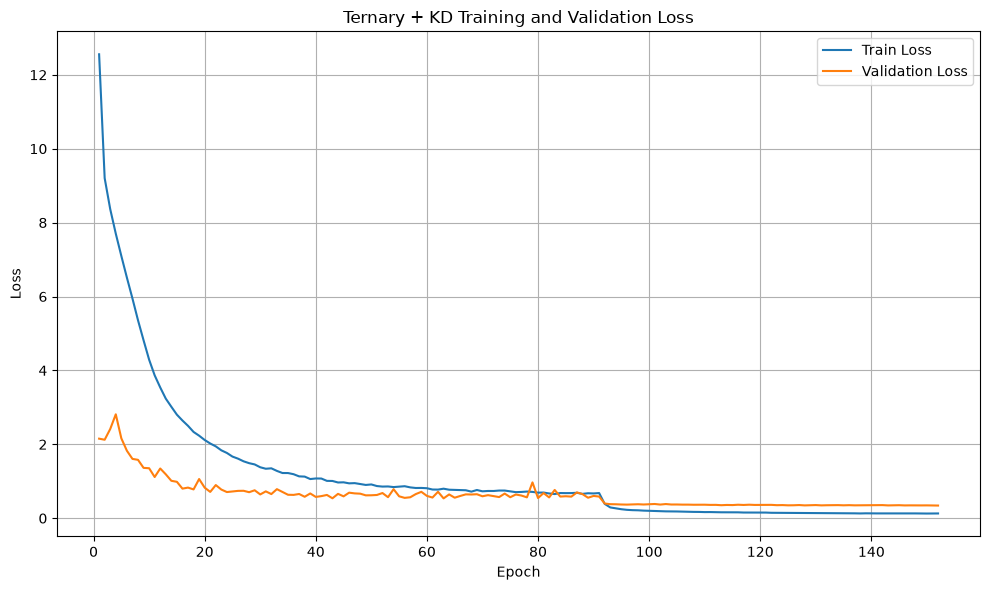

In [92]:
# CELL 75
# Training and validation loss curves

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Ternary + KD Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

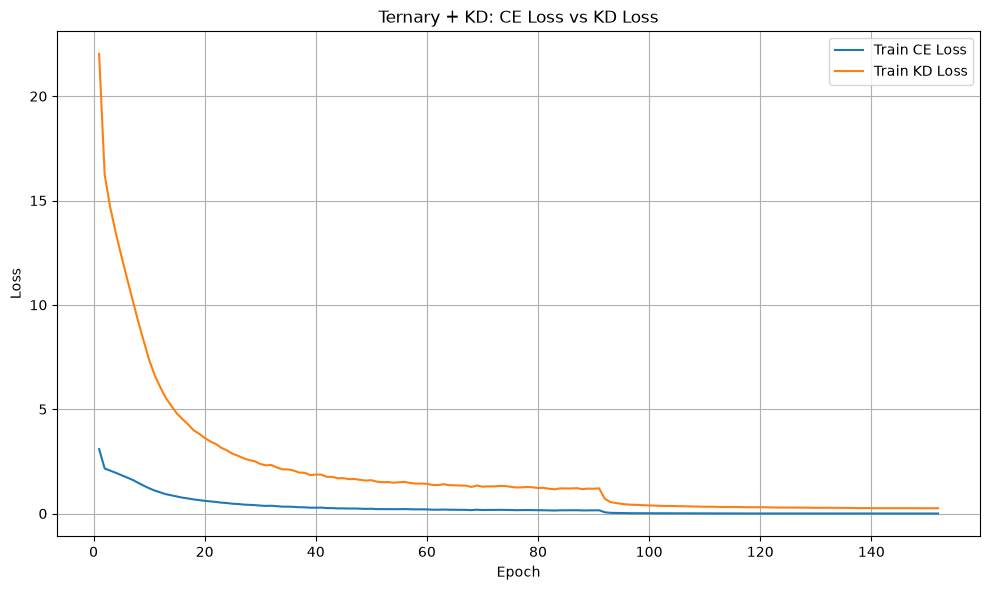

In [93]:
# CELL 76
# CE and KD loss during training

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["train_ce"],
    label="Train CE Loss"
)

plt.plot(
    epochs,
    history["train_kd"],
    label="Train KD Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Ternary + KD: CE Loss vs KD Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

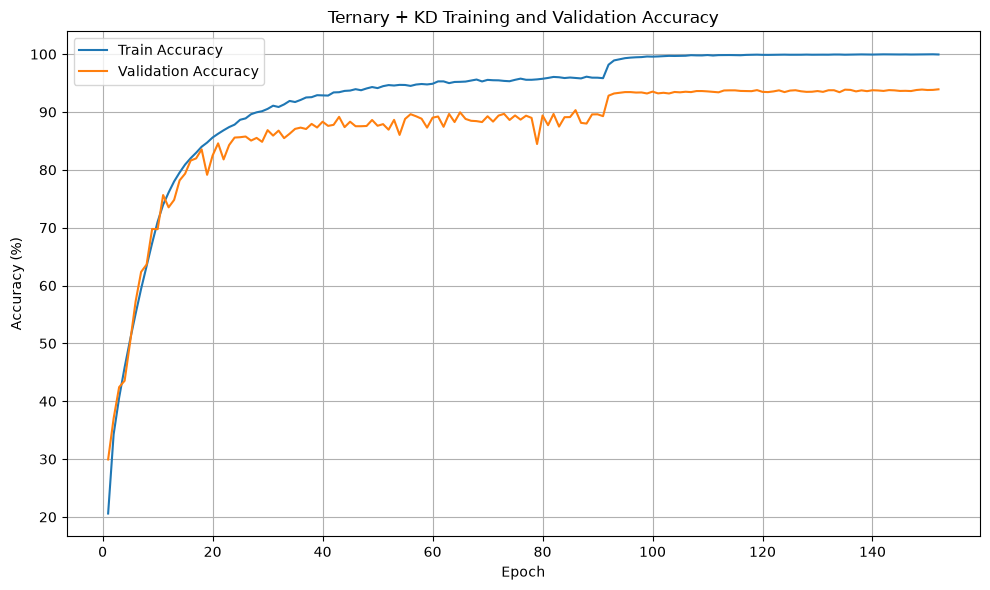

In [94]:
# CELL 77
# Training and validation accuracy

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    epochs,
    history["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Ternary + KD Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

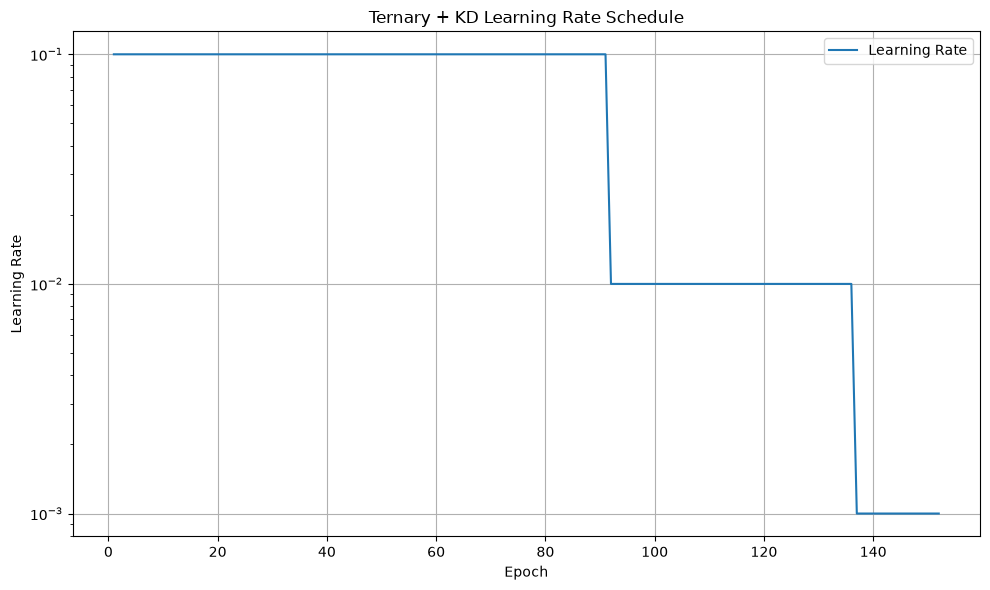

In [95]:
# CELL 78
# Learning-rate schedule

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["lr"],
    label="Learning Rate"
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Ternary + KD Learning Rate Schedule")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

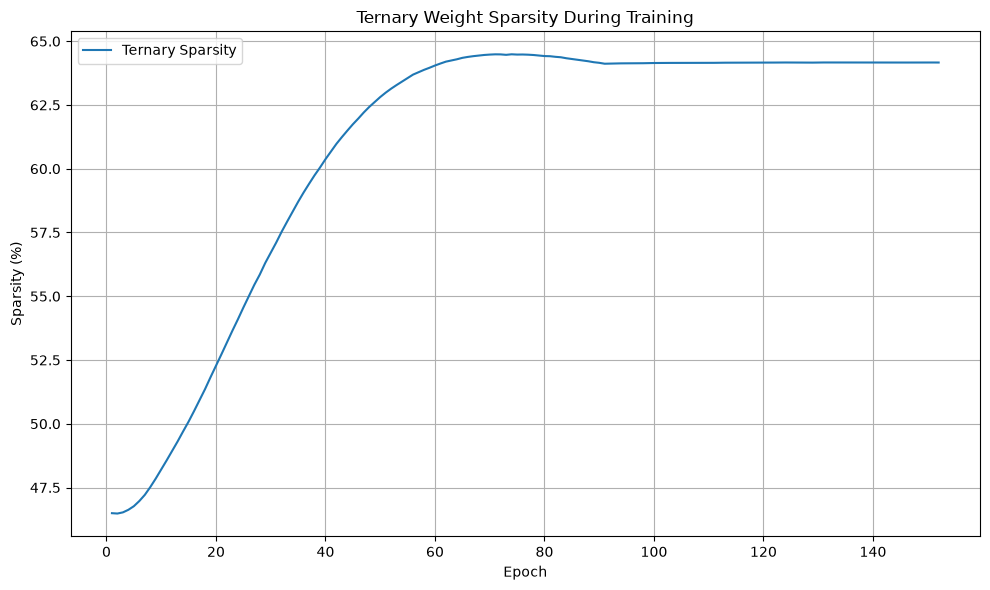

In [96]:
# CELL 79
# Ternary sparsity during training

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    history["sparsity"],
    label="Ternary Sparsity"
)

plt.xlabel("Epoch")
plt.ylabel("Sparsity (%)")
plt.title("Ternary Weight Sparsity During Training")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

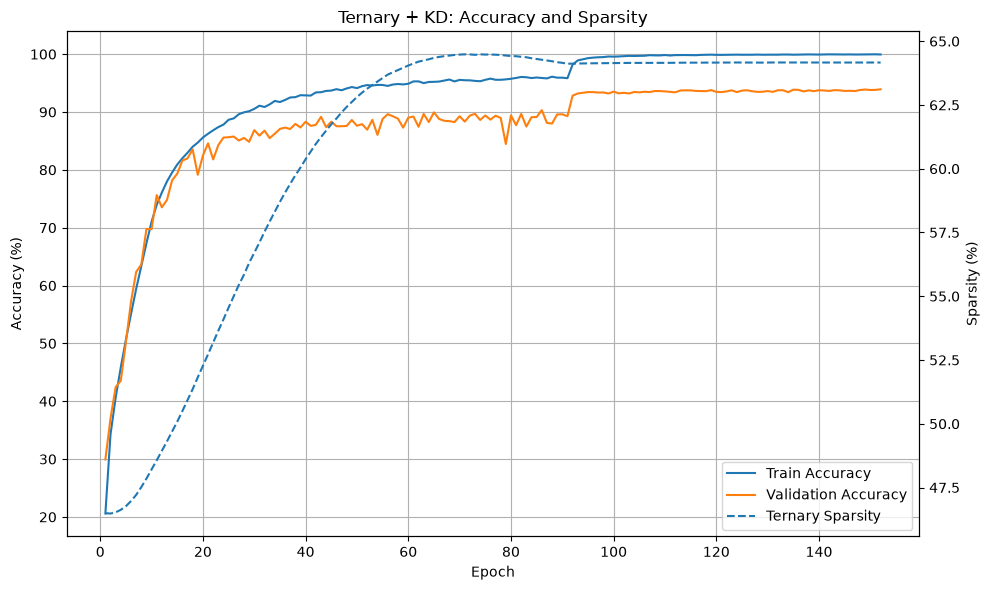

In [97]:
# CELL 80
# Accuracy and sparsity summary

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(
    epochs,
    history["train_acc"],
    label="Train Accuracy"
)

ax1.plot(
    epochs,
    history["val_acc"],
    label="Validation Accuracy"
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")

ax2 = ax1.twinx()

ax2.plot(
    epochs,
    history["sparsity"],
    label="Ternary Sparsity",
    linestyle="--"
)

ax2.set_ylabel("Sparsity (%)")

ax1.set_title("Ternary + KD: Accuracy and Sparsity")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)

ax1.grid(True)
plt.tight_layout()
plt.show()

In [99]:
# CELL 82
# Count zero, positive-alpha and negative-alpha ternary weights

zero_count = 0
positive_count = 0
negative_count = 0
total_count = 0

with torch.no_grad():
    for module in ternary_student.modules():
        if isinstance(module, (TernaryConv2d, TernaryLinear)):

            q_weight, _, _ = ternary_quantize(module.weight)

            zero_count += (q_weight == 0).sum().item()
            positive_count += (q_weight > 0).sum().item()
            negative_count += (q_weight < 0).sum().item()
            total_count += q_weight.numel()

zero_percentage = 100.0 * zero_count / total_count
positive_percentage = 100.0 * positive_count / total_count
negative_percentage = 100.0 * negative_count / total_count

print("=" * 70)
print("TERNARY WEIGHT DISTRIBUTION")
print("=" * 70)
print(f"Total ternary weights:       {total_count:,}")
print(f"Zero weights:                {zero_count:,} ({zero_percentage:.2f}%)")
print(f"Positive weights (+alpha):   {positive_count:,} ({positive_percentage:.2f}%)")
print(f"Negative weights (-alpha):   {negative_count:,} ({negative_percentage:.2f}%)")
print(f"Total sparsity:              {zero_percentage:.2f}%")
print("=" * 70)

TERNARY WEIGHT DISTRIBUTION
Total ternary weights:       10,992,320
Zero weights:                7,053,127 (64.16%)
Positive weights (+alpha):   1,693,076 (15.40%)
Negative weights (-alpha):   2,246,117 (20.43%)
Total sparsity:              64.16%


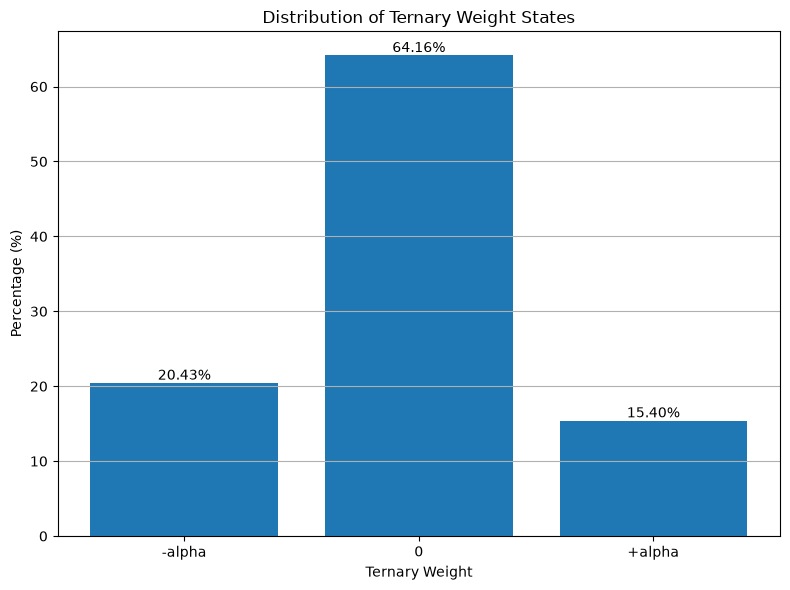

In [101]:
# CELL 84
# Exact distribution of {-alpha, 0, +alpha} states

state_counts = {
    "-alpha": 0,
    "0": 0,
    "+alpha": 0
}

with torch.no_grad():
    for module in ternary_student.modules():
        if isinstance(module, (TernaryConv2d, TernaryLinear)):

            q_weight, alpha, delta = ternary_quantize(module.weight)

            state_counts["-alpha"] += (q_weight < 0).sum().item()
            state_counts["0"] += (q_weight == 0).sum().item()
            state_counts["+alpha"] += (q_weight > 0).sum().item()

total = sum(state_counts.values())

state_percentages = {
    key: 100.0 * value / total
    for key, value in state_counts.items()
}

plt.figure(figsize=(8, 6))

bars = plt.bar(
    state_percentages.keys(),
    state_percentages.values()
)

plt.xlabel("Ternary Weight")
plt.ylabel("Percentage (%)")
plt.title("Distribution of Ternary Weight States")

for bar, percentage in zip(bars, state_percentages.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{percentage:.2f}%",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [104]:
# CELL 84
# Load external images for evaluation

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

EXTERNAL_DATASET_PATH = "/home/sem_7th/ATDL/external_images"

external_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

external_dataset = datasets.ImageFolder(
    root=EXTERNAL_DATASET_PATH,
    transform=external_transform
)

external_loader = DataLoader(
    external_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("=" * 70)
print("EXTERNAL DATASET")
print("=" * 70)
print(f"Dataset path:  {EXTERNAL_DATASET_PATH}")
print(f"Images:        {len(external_dataset)}")
print(f"Classes:       {external_dataset.classes}")
print(f"Class mapping: {external_dataset.class_to_idx}")
print("=" * 70)

EXTERNAL DATASET
Dataset path:  /home/sem_7th/ATDL/external_images
Images:        101
Classes:       ['Aeroplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
Class mapping: {'Aeroplane': 0, 'Automobile': 1, 'Bird': 2, 'Cat': 3, 'Deer': 4, 'Dog': 5, 'Frog': 6, 'Horse': 7, 'Ship': 8, 'Truck': 9}


In [105]:
# CELL 85
# CIFAR-10 class names

CIFAR10_CLASSES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

print(CIFAR10_CLASSES)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [106]:
# CELL 86
# Evaluate external images using the trained ternary + KD model

ternary_student.eval()

external_results = []

with torch.no_grad():

    for images, labels in external_loader:

        images = images.to(device)

        logits = ternary_student(images)

        probabilities = torch.softmax(logits, dim=1)

        confidences, predictions = torch.max(
            probabilities,
            dim=1
        )

        for i in range(images.size(0)):

            true_idx = labels[i].item()
            pred_idx = predictions[i].item()

            result = {
                "true_class": CIFAR10_CLASSES[true_idx],
                "predicted_class": CIFAR10_CLASSES[pred_idx],
                "confidence": confidences[i].item() * 100
            }

            for class_idx, class_name in enumerate(CIFAR10_CLASSES):
                result[class_name] = probabilities[i, class_idx].item() * 100

            external_results.append(result)


print("=" * 70)
print("EXTERNAL DATASET EVALUATION COMPLETE")
print("=" * 70)
print(f"Images evaluated: {len(external_results)}")
print("=" * 70)

EXTERNAL DATASET EVALUATION COMPLETE
Images evaluated: 101


In [107]:
# CELL 87
# Print confidence scores for all 10 classes

for idx, result in enumerate(external_results):

    print("=" * 90)
    print(f"Image {idx + 1}")
    print(f"True class:       {result['true_class']}")
    print(f"Predicted class:  {result['predicted_class']}")
    print(f"Prediction confidence: {result['confidence']:.2f}%")
    print("-" * 90)

    for class_name in CIFAR10_CLASSES:
        print(
            f"{class_name:<12}: "
            f"{result[class_name]:>7.2f}%"
        )

Image 1
True class:       airplane
Predicted class:  airplane
Prediction confidence: 100.00%
------------------------------------------------------------------------------------------
airplane    :  100.00%
automobile  :    0.00%
bird        :    0.00%
cat         :    0.00%
deer        :    0.00%
dog         :    0.00%
frog        :    0.00%
horse       :    0.00%
ship        :    0.00%
truck       :    0.00%
Image 2
True class:       airplane
Predicted class:  airplane
Prediction confidence: 100.00%
------------------------------------------------------------------------------------------
airplane    :  100.00%
automobile  :    0.00%
bird        :    0.00%
cat         :    0.00%
deer        :    0.00%
dog         :    0.00%
frog        :    0.00%
horse       :    0.00%
ship        :    0.00%
truck       :    0.00%
Image 3
True class:       airplane
Predicted class:  airplane
Prediction confidence: 100.00%
-------------------------------------------------------------------------------

In [108]:
# CELL 88
# External dataset accuracy

correct = 0

for result in external_results:
    if result["true_class"] == result["predicted_class"]:
        correct += 1

external_accuracy = (
    100.0 * correct / len(external_results)
)

print("=" * 70)
print("EXTERNAL DATASET RESULTS")
print("=" * 70)
print(f"Total images:    {len(external_results)}")
print(f"Correct:         {correct}")
print(f"Incorrect:       {len(external_results) - correct}")
print(f"Accuracy:        {external_accuracy:.2f}%")
print("=" * 70)

EXTERNAL DATASET RESULTS
Total images:    101
Correct:         98
Incorrect:       3
Accuracy:        97.03%


In [80]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 3.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 5.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 25.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 11.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 40.3 MB/s  0:00:01 eta 0:00:010:010:01
  Attempting uninstall: fsspec━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  4/16 [hf-xet]he]rrow]
    Found existing installation: fsspec 2026.7.0━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  4/16 [hf-xet]
    Uninstalling fsspec-2026.7.0:╸━━━━━━━━━━━━━━━━━━━━━━━━━━━  5/16 [fsspec]
      Successfully uninstalled fsspec-2026.7.0;114m╸━━━━━━━━━━━━━━━━━━━━━━━━━━━  5/16 [fsspec]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [datasets];237m━━ 15/16 [datasets]ce-hub]]


In [81]:
from datasets import load_dataset

cifarnet_test = load_dataset(
    "EleutherAI/cifarnet",
    split="test"
)

print(cifarnet_test)
print("Number of images:", len(cifarnet_test))

sample = cifarnet_test[0]
print(sample.keys())
print("Label:", sample["label"])
print("Image size:", sample["img"].size)

README.md:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

data/train-00000-of-00004-479ecf2b550e1a(…): reconstructing file:   0%|          |  0.00B /  390MB            

data/train-00000-of-00004-479ecf2b550e1a(…): downloading bytes:           |  0.00B            

data/train-00001-of-00004-3298bc3dea6547(…): reconstructing file:   0%|          |  0.00B /  390MB            

data/train-00001-of-00004-3298bc3dea6547(…): downloading bytes:           |  0.00B            

...

data/test-00000-of-00001-6109c632108adc2(…): reconstructing file:   0%|          |  0.00B / 82.2MB            

data/test-00000-of-00001-6109c632108adc2(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/190000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Dataset({
    features: ['img', 'label'],
    num_rows: 10000
})
Number of images: 10000
dict_keys(['img', 'label'])
Label: 3
Image size: (64, 64)


In [89]:
# CELL 90

import torchvision.transforms as transforms

CIFAR10_MEAN = (
    0.4914,
    0.4822,
    0.4465
)

CIFAR10_STD = (
    0.2470,
    0.2435,
    0.2616
)

cifarnet_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        CIFAR10_MEAN,
        CIFAR10_STD
    )
])

classes = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

In [103]:
# CELL 91


print("CIFARNet label order:", cifarnet_test.features["label"].names)
print("CIFAR-10 label order:", train_dataset_aug.classes)

assert cifarnet_test.features["label"].names == train_dataset_aug.classes, (
    "Label order mismatch between CIFARNet and CIFAR-10 — "
    "remap labels before evaluating, do not proceed with the hardcoded `classes` list."
)

print("Label order confirmed identical — safe to proceed.\n")


from torch.utils.data import Dataset, DataLoader

class CIFARNetDataset(Dataset):

    def __init__(self, hf_dataset, transform):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        image = item["img"].convert("RGB")
        label = item["label"]

        image = self.transform(image)

        return image, label


cifarnet_dataset = CIFARNetDataset(
    cifarnet_test,
    cifarnet_transform
)

cifarnet_loader = DataLoader(
    cifarnet_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("CIFARNet test images:", len(cifarnet_dataset))

CIFARNet label order: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
CIFAR-10 label order: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Label order confirmed identical — safe to proceed.

CIFARNet test images: 10000


In [98]:
# ============================================================
# CELL 92-FIX — reload checkpoint, sanity-check, then eval CIFARNet
# ============================================================

import torch

# 1. Rebuild the student and load the trained weights (do NOT skip this)
ternary_student = TernaryResNet18CIFAR(num_classes=NUM_CLASSES).to(device)

best_ternary_checkpoint = os.path.join(
    CHECKPOINT_DIR,
    "resnet18_cifar10_ternary_kd_best.pth"
)

checkpoint = torch.load(best_ternary_checkpoint, map_location=device)

# strict=True so a key mismatch raises instead of silently leaving random weights
missing, unexpected = ternary_student.load_state_dict(
    checkpoint["model_state_dict"], strict=True
), None

print(f"Loaded checkpoint | epoch {checkpoint['epoch']} | val_acc {checkpoint['val_acc']:.2f}%")

# 2. SANITY GATE: re-verify on CIFAR-10 test before trusting any OOD number.
#    If this is not ~93%, the model is wrong and every downstream number is garbage.
_, sanity_acc = evaluate_ternary(ternary_student, test_loader, nn.CrossEntropyLoss(), device)
print(f"CIFAR-10 test sanity check: {sanity_acc:.2f}%")
assert sanity_acc > 85.0, f"Model not loaded correctly (got {sanity_acc:.2f}%) — stop here."

# 3. Now evaluate CIFARNet
ternary_student.eval()

all_labels, all_predictions, all_confidences = [], [], []

with torch.no_grad():
    for images, labels in cifarnet_loader:
        images = images.to(device)
        logits = ternary_student(images)
        probabilities = torch.softmax(logits, dim=1)
        confidence, predicted = probabilities.max(dim=1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.cpu().numpy())
        all_confidences.extend(confidence.cpu().numpy())

# 4. Collapse detector: how spread out are the predictions?
import collections
pred_counts = collections.Counter(all_predictions)
print("\nPrediction distribution:", dict(sorted(pred_counts.items())))
if len(pred_counts) <= 2:
    print("WARNING: model is collapsing to one/two classes — weights are almost certainly wrong.")

correct = sum(a == p for a, p in zip(all_labels, all_predictions))
print(f"\nCIFARNet accuracy: {100.0 * correct / len(all_labels):.2f}%  ({correct}/{len(all_labels)})")

Loaded checkpoint | epoch 152 | val_acc 93.92%
CIFAR-10 test sanity check: 93.21%

Prediction distribution: {np.int64(0): 1124, np.int64(1): 849, np.int64(2): 959, np.int64(3): 1163, np.int64(4): 1283, np.int64(5): 727, np.int64(6): 960, np.int64(7): 944, np.int64(8): 987, np.int64(9): 1004}

CIFARNet accuracy: 72.39%  (7239/10000)


In [99]:
# CELL 93

correct = sum(
    actual == predicted
    for actual, predicted in zip(
        all_labels,
        all_predictions
    )
)

total = len(all_labels)

cifarnet_accuracy = (
    100.0 * correct / total
)

print("=" * 70)
print("TERNARY + KD — CIFARNET RESULTS")
print("=" * 70)
print(f"Correct:   {correct}")
print(f"Total:     {total}")
print(f"Accuracy:  {cifarnet_accuracy:.2f}%")
print("=" * 70)

TERNARY + KD — CIFARNET RESULTS
Correct:   7239
Total:     10000
Accuracy:  72.39%


In [100]:
# CELL 94

from collections import defaultdict

class_stats = defaultdict(
    lambda: {
        "correct": 0,
        "total": 0
    }
)

for actual, predicted in zip(
    all_labels,
    all_predictions
):
    class_stats[actual]["total"] += 1

    if actual == predicted:
        class_stats[actual]["correct"] += 1


print("=" * 70)
print("CIFARNET PER-CLASS ACCURACY")
print("=" * 70)

for class_id, class_name in enumerate(classes):

    correct_class = class_stats[class_id]["correct"]
    total_class = class_stats[class_id]["total"]

    accuracy_class = (
        100.0 * correct_class / total_class
    )

    print(
        f"{class_name:12s}: "
        f"{correct_class:4d}/{total_class:4d} "
        f"({accuracy_class:.2f}%)"
    )

print("=" * 70)

CIFARNET PER-CLASS ACCURACY
Airplane    :  817/ 965 (84.66%)
Automobile  :  689/1018 (67.68%)
Bird        :  686/1023 (67.06%)
Cat         :  649/ 954 (68.03%)
Deer        :  858/1027 (83.54%)
Dog         :  533/1051 (50.71%)
Frog        :  776/1000 (77.60%)
Horse       :  778/1048 (74.24%)
Ship        :  761/ 946 (80.44%)
Truck       :  692/ 968 (71.49%)


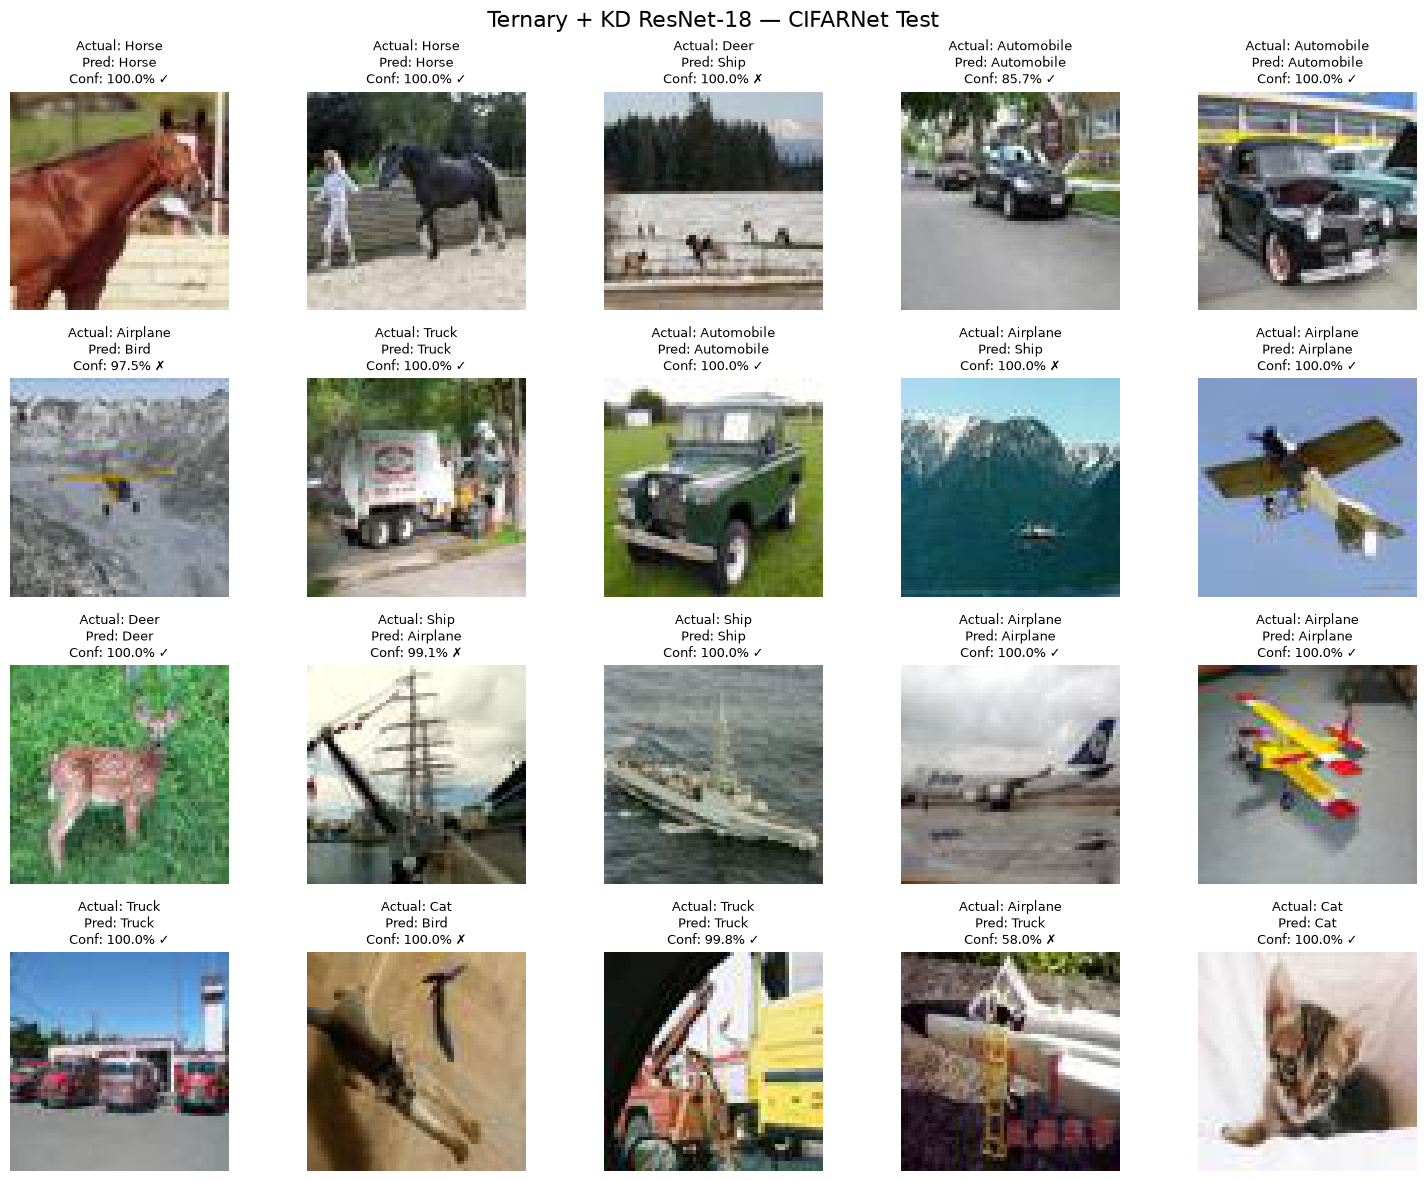

In [101]:
# CELL 95

import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(42)

indices = rng.choice(
    len(cifarnet_dataset),
    size=20,
    replace=False
)

fig, axes = plt.subplots(
    4,
    5,
    figsize=(15, 12)
)

for ax, idx in zip(
    axes.ravel(),
    indices
):

    item = cifarnet_test[int(idx)]

    image = item["img"].convert("RGB")
    actual = item["label"]

    x = cifarnet_transform(image)
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        logits = ternary_student(x)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        confidence, prediction = probabilities.max(
            dim=1
        )

    predicted = prediction.item()
    confidence = confidence.item() * 100

    status = (
        "✓"
        if actual == predicted
        else "✗"
    )

    ax.imshow(image)

    ax.set_title(
        f"Actual: {classes[actual]}\n"
        f"Pred: {classes[predicted]}\n"
        f"Conf: {confidence:.1f}% {status}",
        fontsize=9
    )

    ax.axis("off")

plt.suptitle(
    "Ternary + KD ResNet-18 — CIFARNet Test",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [102]:
# CELL 96

print("=" * 90)
print("CONFIDENCE SCORES FOR 20 RANDOM CIFARNET IMAGES")
print("=" * 90)

for display_idx, idx in enumerate(indices):

    item = cifarnet_test[int(idx)]

    image = item["img"].convert("RGB")
    actual = item["label"]

    x = cifarnet_transform(image)
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        logits = ternary_student(x)

        probabilities = torch.softmax(
            logits,
            dim=1
        )[0]

    predicted = probabilities.argmax().item()

    print("\n" + "=" * 90)
    print(f"Image {display_idx + 1}")
    print(f"Actual class:    {classes[actual]}")
    print(f"Predicted class: {classes[predicted]}")
    print("-" * 90)

    for class_id, class_name in enumerate(classes):

        print(
            f"{class_name:12s}: "
            f"{probabilities[class_id].item() * 100:7.2f}%"
        )

CONFIDENCE SCORES FOR 20 RANDOM CIFARNET IMAGES

Image 1
Actual class:    Horse
Predicted class: Horse
------------------------------------------------------------------------------------------
Airplane    :    0.00%
Automobile  :    0.00%
Bird        :    0.00%
Cat         :    0.00%
Deer        :    0.00%
Dog         :    0.00%
Frog        :    0.00%
Horse       :  100.00%
Ship        :    0.00%
Truck       :    0.00%

Image 2
Actual class:    Horse
Predicted class: Horse
------------------------------------------------------------------------------------------
Airplane    :    0.00%
Automobile  :    0.00%
Bird        :    0.00%
Cat         :    0.00%
Deer        :    0.00%
Dog         :    0.00%
Frog        :    0.00%
Horse       :  100.00%
Ship        :    0.00%
Truck       :    0.00%

Image 3
Actual class:    Deer
Predicted class: Ship
------------------------------------------------------------------------------------------
Airplane    :    0.01%
Automobile  :    0.00%
Bird      

In [ ]:
# 2nd exp of Student

In [ ]:
# CELL 89
# Ternary + KD Experiment 2
# T = 2, lambda = 0.25

T_EXP2 = 2.0
LAMBDA_KD_EXP2 = 0.25

NUM_EPOCHS_EXP2 = 182
QAT_LR_EXP2 = 0.1
MOMENTUM_EXP2 = 0.9
WEIGHT_DECAY_EXP2 = 1e-4

LR_MILESTONES_EXP2 = [91, 136]
LR_GAMMA_EXP2 = 0.1

print("=" * 70)
print("TERNARY + KD EXPERIMENT 2")
print("=" * 70)
print(f"Temperature (T):     {T_EXP2}")
print(f"KD lambda:            {LAMBDA_KD_EXP2}")
print(f"Learning rate:        {QAT_LR_EXP2}")
print(f"Epochs:               {NUM_EPOCHS_EXP2}")
print(f"LR milestones:        {LR_MILESTONES_EXP2}")
print("=" * 70)

In [ ]:
# CELL 90
# Fresh randomly initialized Ternary ResNet-18 for Experiment 2

ternary_student_exp2 = TernaryResNet18CIFAR(
    num_classes=NUM_CLASSES
).to(device)

print("=" * 70)
print("FRESH TERNARY STUDENT CREATED")
print("=" * 70)
print(
    f"Total parameters: "
    f"{sum(p.numel() for p in ternary_student_exp2.parameters()):,}"
)
print("=" * 70)

In [ ]:
# CELL 91
# Verify the frozen teacher

teacher.eval()

for param in teacher.parameters():
    param.requires_grad = False

trainable_teacher_params = sum(
    p.numel()
    for p in teacher.parameters()
    if p.requires_grad
)

print("=" * 70)
print("TEACHER STATUS")
print("=" * 70)
print(f"Trainable teacher parameters: {trainable_teacher_params:,}")

if trainable_teacher_params == 0:
    print("PASS: Teacher is completely frozen.")
else:
    print("WARNING: Teacher has trainable parameters.")

print("=" * 70)

In [73]:
# CELL 92
# Optimizer for Experiment 2

optimizer_ternary_exp2 = optim.SGD(
    ternary_student_exp2.parameters(),
    lr=QAT_LR_EXP2,
    momentum=MOMENTUM_EXP2,
    weight_decay=WEIGHT_DECAY_EXP2
)

print("=" * 70)
print("EXPERIMENT 2 OPTIMIZER")
print("=" * 70)
print(f"Optimizer: SGD")
print(f"Learning rate: {QAT_LR_EXP2}")
print(f"Momentum: {MOMENTUM_EXP2}")
print(f"Weight decay: {WEIGHT_DECAY_EXP2}")
print("=" * 70)

EXPERIMENT 2 OPTIMIZER
Optimizer: SGD
Learning rate: 0.1
Momentum: 0.9
Weight decay: 0.0001


In [74]:
# CELL 93
# Learning-rate scheduler for Experiment 2

scheduler_ternary_exp2 = optim.lr_scheduler.MultiStepLR(
    optimizer_ternary_exp2,
    milestones=LR_MILESTONES_EXP2,
    gamma=LR_GAMMA_EXP2
)

print("=" * 70)
print("EXPERIMENT 2 SCHEDULER")
print("=" * 70)
print(f"Milestones: {LR_MILESTONES_EXP2}")
print(f"Gamma:      {LR_GAMMA_EXP2}")
print("=" * 70)

EXPERIMENT 2 SCHEDULER
Milestones: [91, 136]
Gamma:      0.1


In [75]:
# CELL 94
# Training history for Experiment 2

history_exp2 = {
    "train_loss": [],
    "train_ce": [],
    "train_kd": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": [],
    "sparsity": []
}

best_val_acc_exp2 = 0.0
best_epoch_exp2 = 0

print("Experiment 2 history initialized.")

Experiment 2 history initialized.


In [77]:

# Cross-entropy loss

criterion_ce = nn.CrossEntropyLoss()

print("Cross-entropy loss initialized.")

Cross-entropy loss initialized.


In [96]:
# CELL 95
# Train Experiment 2: T=2, lambda=0.25

best_checkpoint_exp2 = os.path.join(
    CHECKPOINT_DIR,
    "resnet18_cifar10_ternary_kd_T2_lambda025_best.pth"
)

for epoch in range(1, NUM_EPOCHS_EXP2 + 1):

    train_loss, train_ce, train_kd, train_acc = train_one_epoch_kd(
        ternary_student_exp2,
        teacher,
        train_loader,
        optimizer_ternary_exp2,
        device,
        temperature=T_EXP2,
        lambda_kd=LAMBDA_KD_EXP2
    )

    val_loss, val_acc = evaluate_ternary(
        ternary_student_exp2,
        val_loader,
        criterion_ce,
        device
    )

    scheduler_ternary_exp2.step()

    current_lr = optimizer_ternary_exp2.param_groups[0]["lr"]

    current_sparsity = calculate_ternary_sparsity(
        ternary_student_exp2
    )

    history_exp2["train_loss"].append(train_loss)
    history_exp2["train_ce"].append(train_ce)
    history_exp2["train_kd"].append(train_kd)
    history_exp2["train_acc"].append(train_acc)
    history_exp2["val_loss"].append(val_loss)
    history_exp2["val_acc"].append(val_acc)
    history_exp2["lr"].append(current_lr)
    history_exp2["sparsity"].append(current_sparsity)

    if val_acc > best_val_acc_exp2:

        best_val_acc_exp2 = val_acc
        best_epoch_exp2 = epoch

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": ternary_student_exp2.state_dict(),
                "optimizer_state_dict": optimizer_ternary_exp2.state_dict(),
                "scheduler_state_dict": scheduler_ternary_exp2.state_dict(),
                "val_acc": val_acc,
                "val_loss": val_loss,
                "temperature": T_EXP2,
                "lambda_kd": LAMBDA_KD_EXP2
            },
            best_checkpoint_exp2
        )

    print()
    print("=" * 75)
    print(f"Epoch [{epoch}/182] | LR: {current_lr:.6f}")
    print("=" * 75)
    print()
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train CE:   {train_ce:.4f}")
    print(f"Train KD:   {train_kd:.4f}")
    print(f"Train Acc:  {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val Acc:    {val_acc:.2f}%")
    print(f"Sparsity:   {current_sparsity:.2f}%")
    print()

print("=" * 75)
print("TERNARY + KD EXPERIMENT 2 COMPLETE")
print("=" * 75)
print(f"Temperature (T):   {T_EXP2}")
print(f"KD Lambda:         {LAMBDA_KD_EXP2}")
print(f"Best Epoch:        {best_epoch_exp2}")
print(f"Best Val Accuracy: {best_val_acc_exp2:.2f}%")
print("=" * 75)

Training:   0%|          | 0/352 [00:00<?, ?it/s]


Epoch [1/182] | LR: 0.100000

Train Loss: 0.3192
Train CE:   0.1880
Train KD:   0.7130
Train Acc:  93.82%
Val Loss:   0.6275
Val Acc:    84.58%
Sparsity:   49.37%



Training:   0%|          | 0/352 [00:00<?, ?it/s]


Epoch [2/182] | LR: 0.100000

Train Loss: 0.3264
Train CE:   0.1932
Train KD:   0.7263
Train Acc:  93.52%
Val Loss:   0.5668
Val Acc:    85.50%
Sparsity:   49.52%



Training:   0%|          | 0/352 [00:00<?, ?it/s]

...


Epoch [180/182] | LR: 0.001000

Train Loss: 0.0128
Train CE:   0.0011
Train KD:   0.0479
Train Acc:  99.99%
Val Loss:   0.3106
Val Acc:    93.38%
Sparsity:   58.80%



Training:   0%|          | 0/352 [00:00<?, ?it/s]


Epoch [181/182] | LR: 0.001000

Train Loss: 0.0128
Train CE:   0.0013
Train KD:   0.0473
Train Acc:  99.98%
Val Loss:   0.3095
Val Acc:    93.30%
Sparsity:   58.80%



Training:   0%|          | 0/352 [00:00<?, ?it/s]


Epoch [182/182] | LR: 0.001000

Train Loss: 0.0127
Train CE:   0.0012
Train KD:   0.0473
Train Acc:  99.98%
Val Loss:   0.3061
Val Acc:    93.36%
Sparsity:   58.80%

TERNARY + KD EXPERIMENT 2 COMPLETE
Temperature (T):   2.0
KD Lambda:         0.25
Best Epoch:        151
Best Val Accuracy: 93.54%


In [104]:
# CELL 97
# Load the best T=2, lambda=0.25 checkpoint

checkpoint_exp2 = torch.load(
    best_checkpoint_exp2,
    map_location=device
)

ternary_student_exp2.load_state_dict(
    checkpoint_exp2["model_state_dict"]
)

ternary_student_exp2.eval()

print("=" * 70)
print("BEST EXPERIMENT 2 CHECKPOINT LOADED")
print("=" * 70)
print(f"Best epoch:         {checkpoint_exp2['epoch']}")
print(f"Best validation:    {checkpoint_exp2['val_acc']:.2f}%")
print(f"Temperature:        {checkpoint_exp2['temperature']}")
print(f"KD lambda:          {checkpoint_exp2['lambda_kd']}")
print("=" * 70)

BEST EXPERIMENT 2 CHECKPOINT LOADED
Best epoch:         151
Best validation:    93.54%
Temperature:        2.0
KD lambda:          0.25


In [105]:
# CELL 98
# Test evaluation for Experiment 2

test_loss_exp2, test_acc_exp2 = evaluate_ternary(
    ternary_student_exp2,
    test_loader,
    criterion_ce,
    device
)

print("=" * 70)
print("EXPERIMENT 2 TEST RESULTS")
print("=" * 70)
print(f"Test Loss:     {test_loss_exp2:.4f}")
print(f"Test Accuracy: {test_acc_exp2:.2f}%")
print("=" * 70)

EXPERIMENT 2 TEST RESULTS
Test Loss:     0.3276
Test Accuracy: 93.42%


In [106]:
# CELL 99
# Verify ternary representation

total_ternary_weights_exp2 = 0
invalid_ternary_weights_exp2 = 0

with torch.no_grad():

    for module in ternary_student_exp2.modules():

        if isinstance(module, (TernaryConv2d, TernaryLinear)):

            q_weight, alpha, delta = ternary_quantize(
                module.weight
            )

            total_ternary_weights_exp2 += q_weight.numel()

            valid = (
                torch.isclose(
                    q_weight,
                    torch.zeros_like(q_weight),
                    atol=1e-6
                )
                |
                torch.isclose(
                    q_weight,
                    torch.full_like(
                        q_weight,
                        alpha.item()
                    ),
                    atol=1e-6
                )
                |
                torch.isclose(
                    q_weight,
                    torch.full_like(
                        q_weight,
                        -alpha.item()
                    ),
                    atol=1e-6
                )
            )

            invalid_ternary_weights_exp2 += (
                ~valid
            ).sum().item()

print("=" * 70)
print("TERNARY REPRESENTATION CHECK")
print("=" * 70)
print(
    f"Total ternary weights: "
    f"{total_ternary_weights_exp2:,}"
)
print(
    f"Invalid values: "
    f"{invalid_ternary_weights_exp2:,}"
)

if invalid_ternary_weights_exp2 == 0:
    print("PASS: All weights are {-alpha, 0, +alpha}.")
else:
    print("WARNING: Invalid ternary values detected.")

print("=" * 70)

TERNARY REPRESENTATION CHECK
Total ternary weights: 10,992,320
Invalid values: 0
PASS: All weights are {-alpha, 0, +alpha}.


In [107]:
# CELL 100
# Final sparsity for Experiment 2

sparsity_exp2 = calculate_ternary_sparsity(
    ternary_student_exp2
)

print("=" * 70)
print("EXPERIMENT 2 SPARSITY")
print("=" * 70)
print(f"Sparsity:       {sparsity_exp2:.2f}%")
print(f"Non-zero:       {100.0 - sparsity_exp2:.2f}%")
print("=" * 70)

EXPERIMENT 2 SPARSITY
Sparsity:       58.79%
Non-zero:       41.21%


In [108]:
# CELL 101
# Parameter breakdown for Experiment 2

total_params_exp2 = sum(
    p.numel()
    for p in ternary_student_exp2.parameters()
)

ternary_params_exp2 = 0
fp32_params_exp2 = 0

for module in ternary_student_exp2.modules():

    if isinstance(module, (TernaryConv2d, TernaryLinear)):

        ternary_params_exp2 += module.weight.numel()

        if module.bias is not None:
            fp32_params_exp2 += module.bias.numel()

    elif isinstance(module, nn.BatchNorm2d):

        fp32_params_exp2 += module.weight.numel()
        fp32_params_exp2 += module.bias.numel()

    elif isinstance(module, nn.Conv2d):

        fp32_params_exp2 += sum(
            p.numel()
            for p in module.parameters()
        )

print("=" * 70)
print("EXPERIMENT 2 PARAMETER BREAKDOWN")
print("=" * 70)
print(f"Total parameters:          {total_params_exp2:,}")
print(f"Ternary weight parameters: {ternary_params_exp2:,}")
print(f"FP32 parameters:           {fp32_params_exp2:,}")
print(
    f"Accounted parameters:      "
    f"{ternary_params_exp2 + fp32_params_exp2:,}"
)
print("=" * 70)

EXPERIMENT 2 PARAMETER BREAKDOWN
Total parameters:          11,173,962
Ternary weight parameters: 10,992,320
FP32 parameters:           181,642
Accounted parameters:      11,173,962


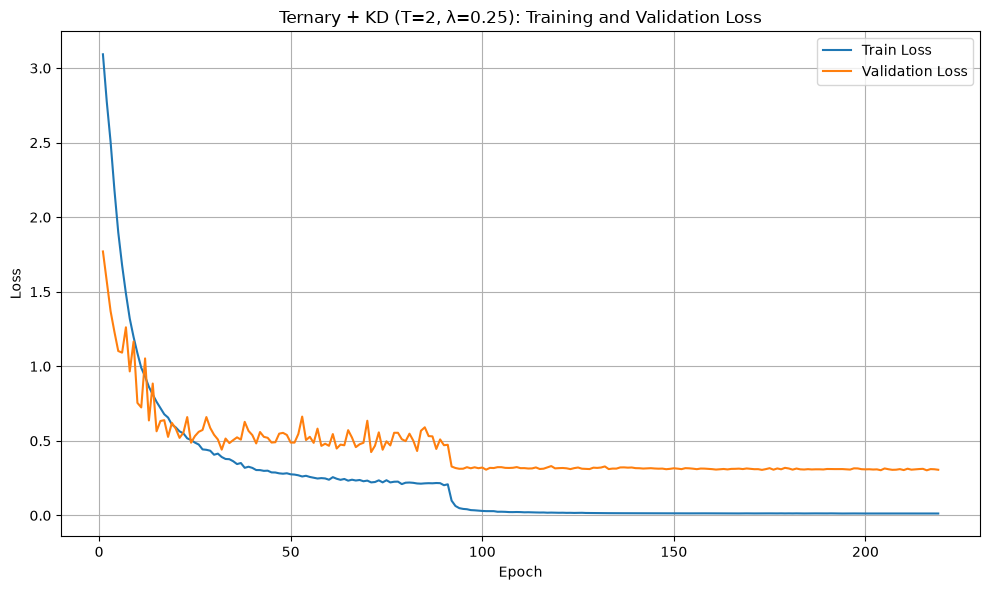

In [109]:
# CELL 102
# Experiment 2 training and validation loss

epochs_exp2 = range(
    1,
    len(history_exp2["train_loss"]) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_exp2,
    history_exp2["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs_exp2,
    history_exp2["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Ternary + KD (T=2, λ=0.25): "
    "Training and Validation Loss"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

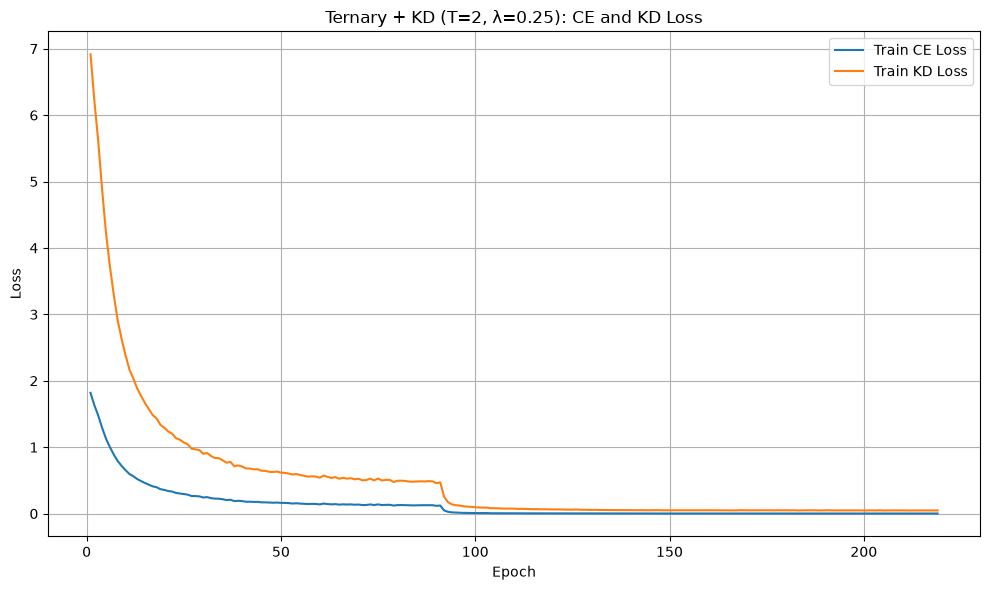

In [110]:
# CELL 103
# CE and KD loss

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_exp2,
    history_exp2["train_ce"],
    label="Train CE Loss"
)

plt.plot(
    epochs_exp2,
    history_exp2["train_kd"],
    label="Train KD Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Ternary + KD (T=2, λ=0.25): "
    "CE and KD Loss"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

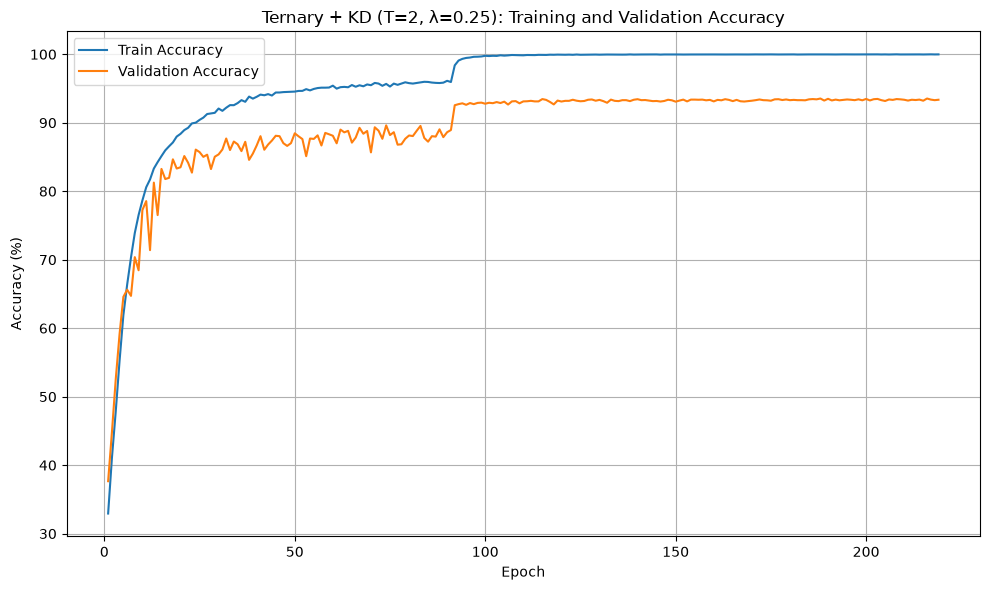

In [111]:
# CELL 104
# Training and validation accuracy

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_exp2,
    history_exp2["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    epochs_exp2,
    history_exp2["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title(
    "Ternary + KD (T=2, λ=0.25): "
    "Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

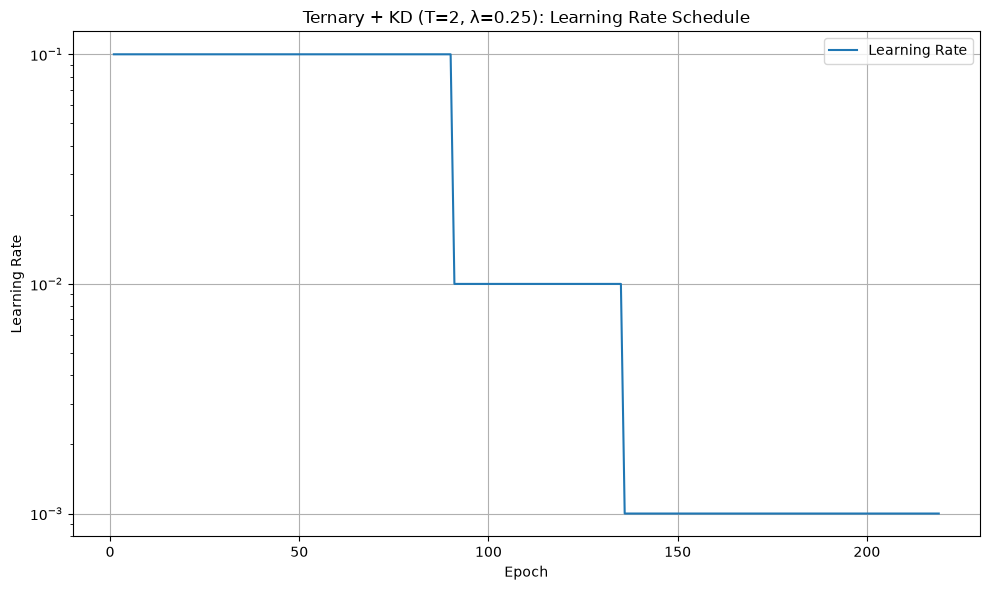

In [112]:
# CELL 105
# Learning rate

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_exp2,
    history_exp2["lr"],
    label="Learning Rate"
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title(
    "Ternary + KD (T=2, λ=0.25): "
    "Learning Rate Schedule"
)

plt.yscale("log")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

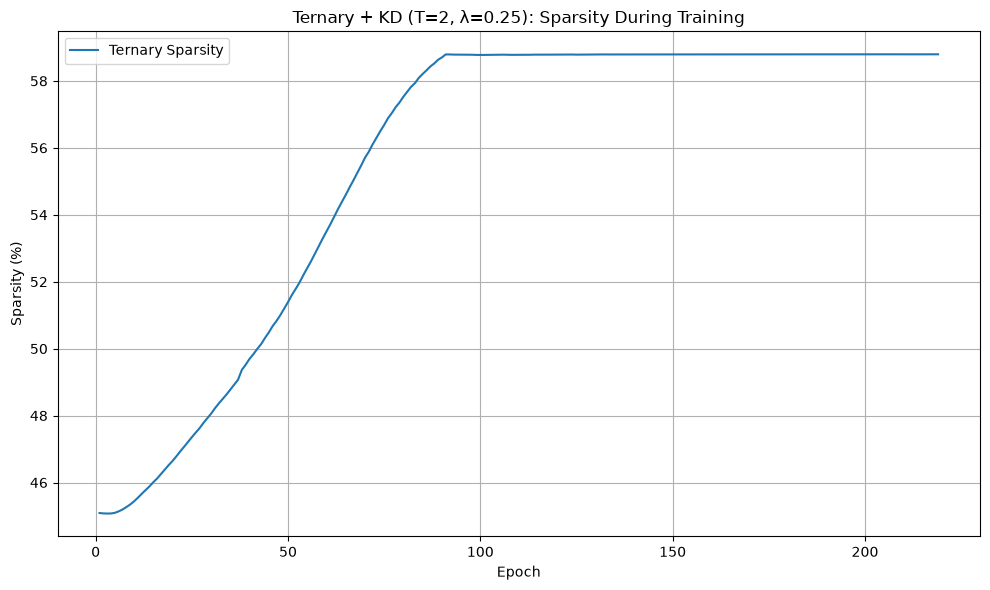

In [113]:
# CELL 106
# Sparsity during training

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_exp2,
    history_exp2["sparsity"],
    label="Ternary Sparsity"
)

plt.xlabel("Epoch")
plt.ylabel("Sparsity (%)")
plt.title(
    "Ternary + KD (T=2, λ=0.25): "
    "Sparsity During Training"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

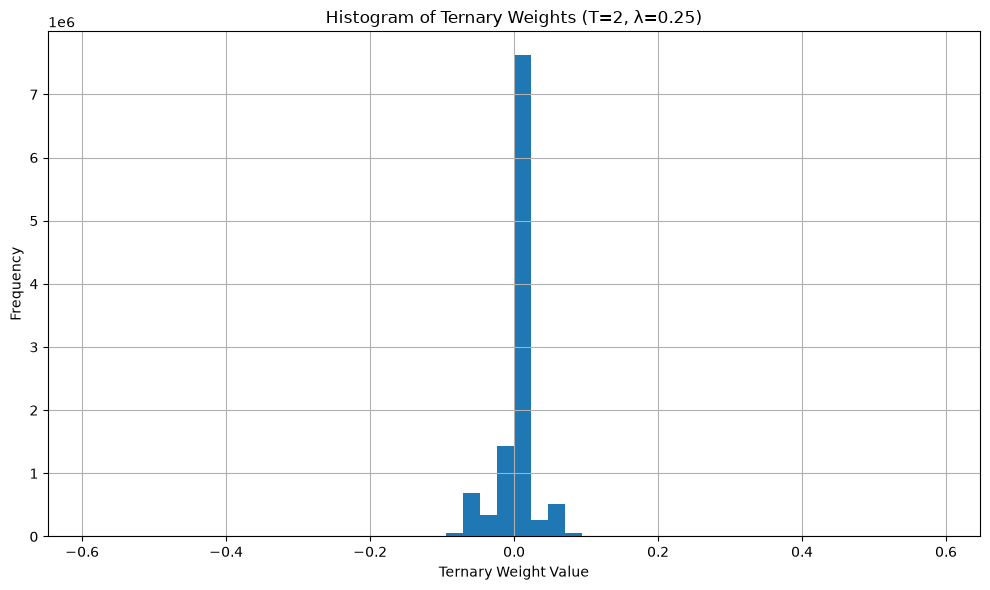

In [114]:
# CELL 107
# Histogram of ternary weights

all_ternary_weights_exp2 = []

with torch.no_grad():

    for module in ternary_student_exp2.modules():

        if isinstance(module, (TernaryConv2d, TernaryLinear)):

            q_weight, _, _ = ternary_quantize(
                module.weight
            )

            all_ternary_weights_exp2.append(
                q_weight.detach()
                .cpu()
                .numpy()
                .flatten()
            )

all_ternary_weights_exp2 = np.concatenate(
    all_ternary_weights_exp2
)

plt.figure(figsize=(10, 6))

plt.hist(
    all_ternary_weights_exp2,
    bins=50
)

plt.xlabel("Ternary Weight Value")
plt.ylabel("Frequency")
plt.title(
    "Histogram of Ternary Weights "
    "(T=2, λ=0.25)"
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [115]:
# CELL 108
# Ternary state distribution

zero_count_exp2 = 0
positive_count_exp2 = 0
negative_count_exp2 = 0
total_count_exp2 = 0

with torch.no_grad():

    for module in ternary_student_exp2.modules():

        if isinstance(module, (TernaryConv2d, TernaryLinear)):

            q_weight, _, _ = ternary_quantize(
                module.weight
            )

            zero_count_exp2 += (
                q_weight == 0
            ).sum().item()

            positive_count_exp2 += (
                q_weight > 0
            ).sum().item()

            negative_count_exp2 += (
                q_weight < 0
            ).sum().item()

            total_count_exp2 += q_weight.numel()


zero_percentage_exp2 = (
    100.0 * zero_count_exp2 / total_count_exp2
)

positive_percentage_exp2 = (
    100.0 * positive_count_exp2 / total_count_exp2
)

negative_percentage_exp2 = (
    100.0 * negative_count_exp2 / total_count_exp2
)

print("=" * 70)
print("EXPERIMENT 2 TERNARY WEIGHT DISTRIBUTION")
print("=" * 70)
print(
    f"Zero:       {zero_percentage_exp2:.2f}%"
)
print(
    f"Positive:   {positive_percentage_exp2:.2f}%"
)
print(
    f"Negative:   {negative_percentage_exp2:.2f}%"
)
print("=" * 70)

EXPERIMENT 2 TERNARY WEIGHT DISTRIBUTION
Zero:       58.79%
Positive:   18.18%
Negative:   23.03%


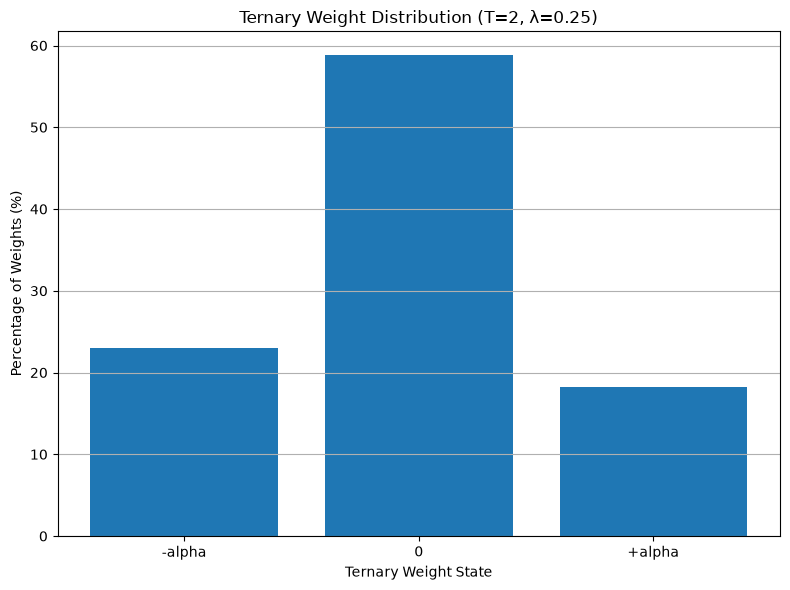

In [116]:
# CELL 109

states_exp2 = [
    "-alpha",
    "0",
    "+alpha"
]

percentages_exp2 = [
    negative_percentage_exp2,
    zero_percentage_exp2,
    positive_percentage_exp2
]

plt.figure(figsize=(8, 6))

plt.bar(
    states_exp2,
    percentages_exp2
)

plt.xlabel("Ternary Weight State")
plt.ylabel("Percentage of Weights (%)")
plt.title(
    "Ternary Weight Distribution "
    "(T=2, λ=0.25)"
)

plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [117]:
# CELL 110
# CIFARNet evaluation for Experiment 2

ternary_student_exp2.eval()

all_labels_exp2 = []
all_predictions_exp2 = []
all_confidences_exp2 = []

with torch.no_grad():

    for images, labels in cifarnet_loader:

        images = images.to(device)

        logits = ternary_student_exp2(images)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        confidence, predicted = probabilities.max(
            dim=1
        )

        all_labels_exp2.extend(
            labels.numpy()
        )

        all_predictions_exp2.extend(
            predicted.cpu().numpy()
        )

        all_confidences_exp2.extend(
            confidence.cpu().numpy()
        )

print("=" * 70)
print("CIFARNET EVALUATION — EXPERIMENT 2")
print("=" * 70)
print(
    f"Images evaluated: "
    f"{len(all_labels_exp2)}"
)
print("=" * 70)

CIFARNET EVALUATION — EXPERIMENT 2
Images evaluated: 10000


In [118]:
# CELL 111

correct_exp2 = sum(
    actual == predicted
    for actual, predicted in zip(
        all_labels_exp2,
        all_predictions_exp2
    )
)

total_exp2 = len(all_labels_exp2)

cifarnet_accuracy_exp2 = (
    100.0 * correct_exp2 / total_exp2
)

print("=" * 70)
print("CIFARNET — EXPERIMENT 2")
print("=" * 70)
print(f"Correct:  {correct_exp2}")
print(f"Total:    {total_exp2}")
print(f"Accuracy: {cifarnet_accuracy_exp2:.2f}%")
print("=" * 70)

CIFARNET — EXPERIMENT 2
Correct:  7311
Total:    10000
Accuracy: 73.11%


In [119]:
# CELL 112

class_stats_exp2 = defaultdict(
    lambda: {
        "correct": 0,
        "total": 0
    }
)

for actual, predicted in zip(
    all_labels_exp2,
    all_predictions_exp2
):

    class_stats_exp2[actual]["total"] += 1

    if actual == predicted:
        class_stats_exp2[actual]["correct"] += 1


print("=" * 70)
print("CIFARNET PER-CLASS ACCURACY — EXPERIMENT 2")
print("=" * 70)

for class_id, class_name in enumerate(classes):

    correct_class = (
        class_stats_exp2[class_id]["correct"]
    )

    total_class = (
        class_stats_exp2[class_id]["total"]
    )

    accuracy_class = (
        100.0 *
        correct_class /
        total_class
    )

    print(
        f"{class_name:12s}: "
        f"{correct_class:4d}/{total_class:4d} "
        f"({accuracy_class:.2f}%)"
    )

print("=" * 70)

CIFARNET PER-CLASS ACCURACY — EXPERIMENT 2
Airplane    :  820/ 965 (84.97%)
Automobile  :  713/1018 (70.04%)
Bird        :  676/1023 (66.08%)
Cat         :  673/ 954 (70.55%)
Deer        :  876/1027 (85.30%)
Dog         :  521/1051 (49.57%)
Frog        :  781/1000 (78.10%)
Horse       :  774/1048 (73.85%)
Ship        :  774/ 946 (81.82%)
Truck       :  703/ 968 (72.62%)


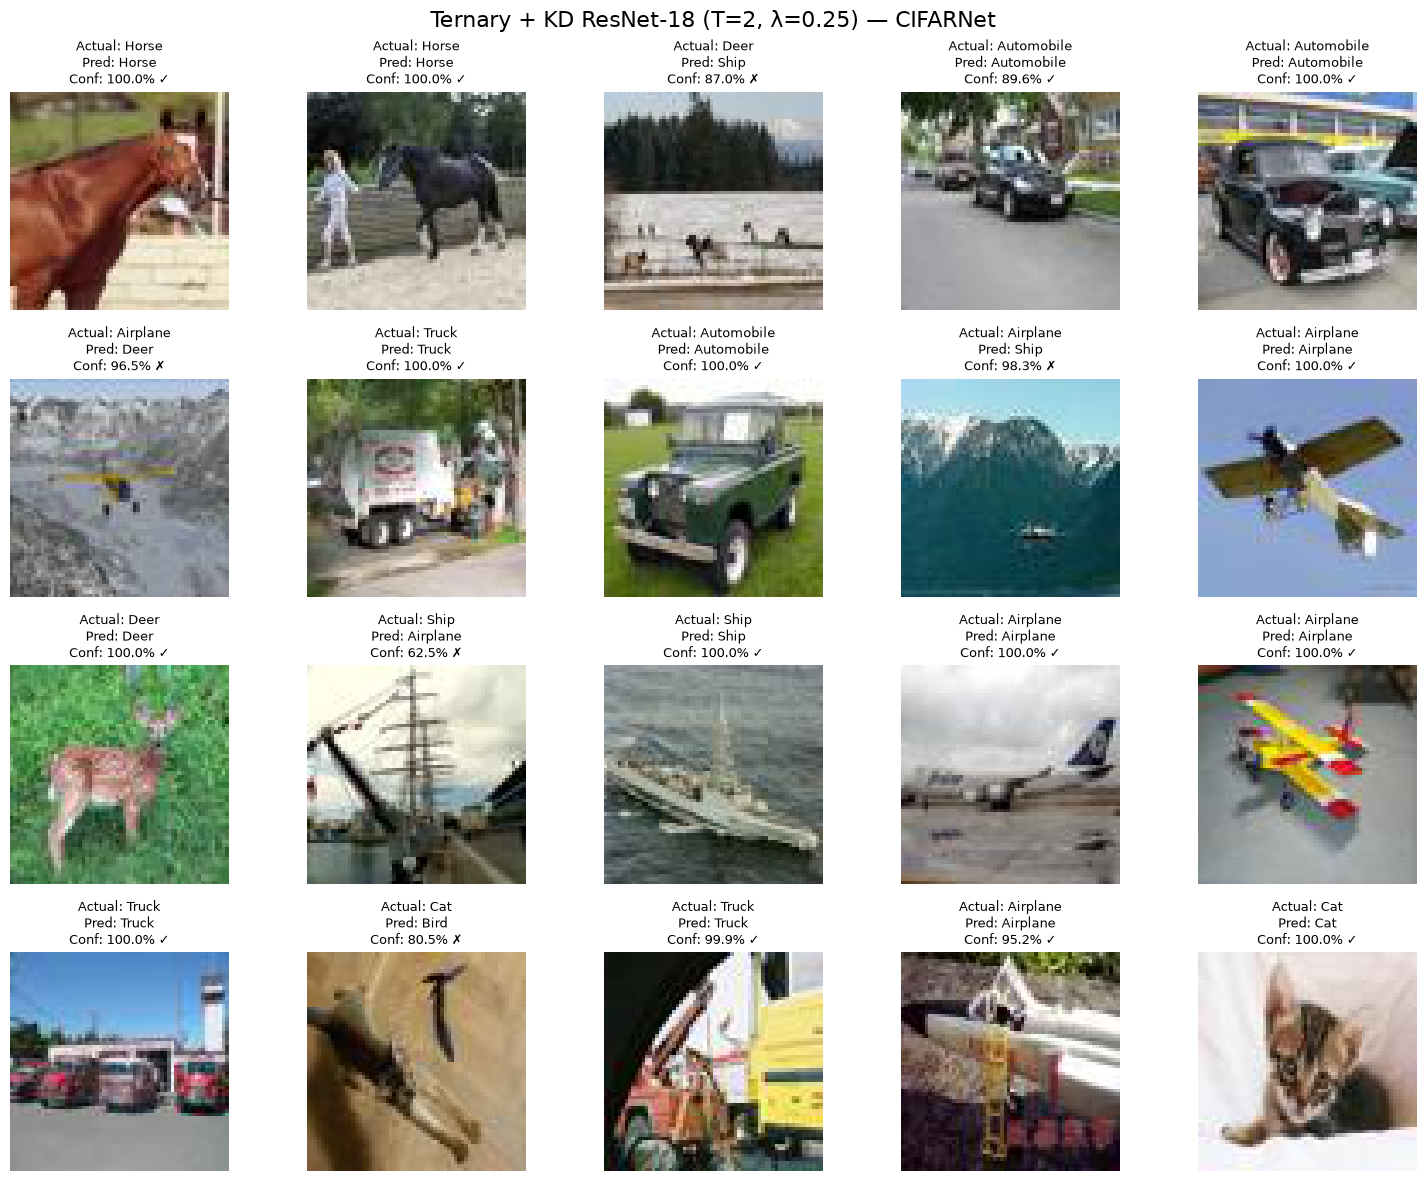

In [120]:
# CELL 113

rng = np.random.default_rng(42)

indices_exp2 = rng.choice(
    len(cifarnet_dataset),
    size=20,
    replace=False
)

fig, axes = plt.subplots(
    4,
    5,
    figsize=(15, 12)
)

for ax, idx in zip(
    axes.ravel(),
    indices_exp2
):

    item = cifarnet_test[int(idx)]

    image = item["img"].convert("RGB")
    actual = item["label"]

    x = cifarnet_transform(image)
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        logits = ternary_student_exp2(x)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        confidence, prediction = probabilities.max(
            dim=1
        )

    predicted = prediction.item()
    confidence = confidence.item() * 100

    status = (
        "✓"
        if actual == predicted
        else "✗"
    )

    ax.imshow(image)

    ax.set_title(
        f"Actual: {classes[actual]}\n"
        f"Pred: {classes[predicted]}\n"
        f"Conf: {confidence:.1f}% {status}",
        fontsize=9
    )

    ax.axis("off")

plt.suptitle(
    "Ternary + KD ResNet-18 "
    "(T=2, λ=0.25) — CIFARNet",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [121]:
# CELL 114

print("=" * 90)
print(
    "CONFIDENCE SCORES — "
    "20 RANDOM CIFARNET IMAGES"
)
print("=" * 90)

for display_idx, idx in enumerate(indices_exp2):

    item = cifarnet_test[int(idx)]

    image = item["img"].convert("RGB")
    actual = item["label"]

    x = cifarnet_transform(image)
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        logits = ternary_student_exp2(x)

        probabilities = torch.softmax(
            logits,
            dim=1
        )[0]

    predicted = probabilities.argmax().item()

    print("\n" + "=" * 90)
    print(f"Image {display_idx + 1}")
    print(f"Actual class:    {classes[actual]}")
    print(f"Predicted class: {classes[predicted]}")
    print("-" * 90)

    for class_id, class_name in enumerate(classes):

        print(
            f"{class_name:12s}: "
            f"{probabilities[class_id].item() * 100:7.2f}%"
        )

CONFIDENCE SCORES — 20 RANDOM CIFARNET IMAGES

Image 1
Actual class:    Horse
Predicted class: Horse
------------------------------------------------------------------------------------------
Airplane    :    0.00%
Automobile  :    0.00%
Bird        :    0.00%
Cat         :    0.00%
Deer        :    0.00%
Dog         :    0.00%
Frog        :    0.00%
Horse       :  100.00%
Ship        :    0.00%
Truck       :    0.00%

Image 2
Actual class:    Horse
Predicted class: Horse
------------------------------------------------------------------------------------------
Airplane    :    0.00%
Automobile  :    0.00%
Bird        :    0.00%
Cat         :    0.00%
Deer        :    0.00%
Dog         :    0.00%
Frog        :    0.00%
Horse       :  100.00%
Ship        :    0.00%
Truck       :    0.00%

Image 3
Actual class:    Deer
Predicted class: Ship
------------------------------------------------------------------------------------------
Airplane    :   12.85%
Automobile  :    0.00%
Bird        

In [122]:
# 3rd exp of Student

In [123]:
# CELL 115
# Ternary + KD Experiment 3
# T = 3, lambda = 0.4

T_EXP3 = 3.0
LAMBDA_KD_EXP3 = 0.4

NUM_EPOCHS_EXP3 = 182
QAT_LR_EXP3 = 0.1
MOMENTUM_EXP3 = 0.9
WEIGHT_DECAY_EXP3 = 1e-4

LR_MILESTONES_EXP3 = [91, 136]
LR_GAMMA_EXP3 = 0.1

print("=" * 70)
print("TERNARY + KD EXPERIMENT 3")
print("=" * 70)
print(f"Temperature (T):     {T_EXP3}")
print(f"KD lambda:            {LAMBDA_KD_EXP3}")
print(f"Learning rate:        {QAT_LR_EXP3}")
print(f"Epochs:               {NUM_EPOCHS_EXP3}")
print(f"LR milestones:        {LR_MILESTONES_EXP3}")
print("=" * 70)

TERNARY + KD EXPERIMENT 3
Temperature (T):     3.0
KD lambda:            0.4
Learning rate:        0.1
Epochs:               182
LR milestones:        [91, 136]


In [125]:
# CELL 116
# Fresh randomly initialized Ternary ResNet-18 for Experiment 3

ternary_student_exp3 = TernaryResNet18CIFAR(
    num_classes=NUM_CLASSES
).to(device)

print("=" * 70)
print("FRESH TERNARY STUDENT — EXPERIMENT 3")
print("=" * 70)
print(
    f"Total parameters: "
    f"{sum(p.numel() for p in ternary_student_exp3.parameters()):,}"
)
print("=" * 70)

FRESH TERNARY STUDENT — EXPERIMENT 3
Total parameters: 11,173,962


In [126]:
# CELL 117
# Verify the frozen ResNet-34 teacher

teacher.eval()

for param in teacher.parameters():
    param.requires_grad = False

trainable_teacher_params = sum(
    p.numel()
    for p in teacher.parameters()
    if p.requires_grad
)

print("=" * 70)
print("TEACHER STATUS")
print("=" * 70)
print(
    f"Trainable teacher parameters: "
    f"{trainable_teacher_params:,}"
)

if trainable_teacher_params == 0:
    print("PASS: Teacher is completely frozen.")
else:
    print("WARNING: Teacher has trainable parameters.")

print("=" * 70)

TEACHER STATUS
Trainable teacher parameters: 0
PASS: Teacher is completely frozen.


In [127]:
# CELL 118
# Optimizer for Experiment 3

optimizer_ternary_exp3 = optim.SGD(
    ternary_student_exp3.parameters(),
    lr=QAT_LR_EXP3,
    momentum=MOMENTUM_EXP3,
    weight_decay=WEIGHT_DECAY_EXP3
)

print("=" * 70)
print("EXPERIMENT 3 OPTIMIZER")
print("=" * 70)
print(f"Optimizer:    SGD")
print(f"Learning rate: {QAT_LR_EXP3}")
print(f"Momentum:      {MOMENTUM_EXP3}")
print(f"Weight decay:  {WEIGHT_DECAY_EXP3}")
print("=" * 70)

EXPERIMENT 3 OPTIMIZER
Optimizer:    SGD
Learning rate: 0.1
Momentum:      0.9
Weight decay:  0.0001


In [128]:
# CELL 119
# Learning-rate scheduler for Experiment 3

scheduler_ternary_exp3 = optim.lr_scheduler.MultiStepLR(
    optimizer_ternary_exp3,
    milestones=LR_MILESTONES_EXP3,
    gamma=LR_GAMMA_EXP3
)

print("=" * 70)
print("EXPERIMENT 3 SCHEDULER")
print("=" * 70)
print(f"Milestones: {LR_MILESTONES_EXP3}")
print(f"Gamma:      {LR_GAMMA_EXP3}")
print("=" * 70)

EXPERIMENT 3 SCHEDULER
Milestones: [91, 136]
Gamma:      0.1


In [129]:
# CELL 120
# Training history for Experiment 3

history_exp3 = {
    "train_loss": [],
    "train_ce": [],
    "train_kd": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": [],
    "sparsity": []
}

best_val_acc_exp3 = 0.0
best_epoch_exp3 = 0

print("Experiment 3 history initialized.")

Experiment 3 history initialized.


In [130]:
# CELL 121
# Train Experiment 3: T=3, lambda=0.4

best_checkpoint_exp3 = os.path.join(
    CHECKPOINT_DIR,
    "resnet18_cifar10_ternary_kd_T3_lambda04_best.pth"
)

for epoch in range(1, NUM_EPOCHS_EXP3 + 1):

    train_loss, train_ce, train_kd, train_acc = train_one_epoch_kd(
        ternary_student_exp3,
        teacher,
        train_loader,
        optimizer_ternary_exp3,
        device,
        temperature=T_EXP3,
        lambda_kd=LAMBDA_KD_EXP3
    )

    val_loss, val_acc = evaluate_ternary(
        ternary_student_exp3,
        val_loader,
        criterion_ce,
        device
    )

    scheduler_ternary_exp3.step()

    current_lr = optimizer_ternary_exp3.param_groups[0]["lr"]

    current_sparsity = calculate_ternary_sparsity(
        ternary_student_exp3
    )

    history_exp3["train_loss"].append(train_loss)
    history_exp3["train_ce"].append(train_ce)
    history_exp3["train_kd"].append(train_kd)
    history_exp3["train_acc"].append(train_acc)
    history_exp3["val_loss"].append(val_loss)
    history_exp3["val_acc"].append(val_acc)
    history_exp3["lr"].append(current_lr)
    history_exp3["sparsity"].append(current_sparsity)

    if val_acc > best_val_acc_exp3:

        best_val_acc_exp3 = val_acc
        best_epoch_exp3 = epoch

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": ternary_student_exp3.state_dict(),
                "optimizer_state_dict": optimizer_ternary_exp3.state_dict(),
                "scheduler_state_dict": scheduler_ternary_exp3.state_dict(),
                "val_acc": val_acc,
                "val_loss": val_loss,
                "temperature": T_EXP3,
                "lambda_kd": LAMBDA_KD_EXP3
            },
            best_checkpoint_exp3
        )

    print()
    print("=" * 75)
    print(
        f"Epoch [{epoch}/182] | "
        f"LR: {current_lr:.6f}"
    )
    print("=" * 75)
    print()
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train CE:   {train_ce:.4f}")
    print(f"Train KD:   {train_kd:.4f}")
    print(f"Train Acc:  {train_acc:.2f}%")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val Acc:    {val_acc:.2f}%")
    print(f"Sparsity:   {current_sparsity:.2f}%")
    print()

print("=" * 75)
print("TERNARY + KD EXPERIMENT 3 COMPLETE")
print("=" * 75)
print(f"Temperature (T):   {T_EXP3}")
print(f"KD Lambda:         {LAMBDA_KD_EXP3}")
print(f"Best Epoch:        {best_epoch_exp3}")
print(f"Best Val Accuracy: {best_val_acc_exp3:.2f}%")
print("=" * 75)

Training:   0%|          | 0/352 [00:00<?, ?it/s]


Epoch [1/182] | LR: 0.100000

Train Loss: 8.6045
Train CE:   3.0165
Train KD:   16.9863
Train Acc:  20.96%
Val Loss:   2.3224
Val Acc:    28.46%
Sparsity:   45.69%



Training:   0%|          | 0/352 [00:00<?, ?it/s]


Epoch [2/182] | LR: 0.100000

Train Loss: 6.1434
Train CE:   1.9463
Train KD:   12.4390
Train Acc:  34.57%
Val Loss:   2.2381
Val Acc:    35.42%
Sparsity:   45.67%



Training:   0%|          | 0/352 [00:00<?, ?it/s]

...


Epoch [180/182] | LR: 0.001000

Train Loss: 0.0605
Train CE:   0.0018
Train KD:   0.1487
Train Acc:  99.96%
Val Loss:   0.3219
Val Acc:    94.04%
Sparsity:   62.98%



Training:   0%|          | 0/352 [00:00<?, ?it/s]


Epoch [181/182] | LR: 0.001000

Train Loss: 0.0596
Train CE:   0.0012
Train KD:   0.1472
Train Acc:  99.96%
Val Loss:   0.3239
Val Acc:    93.86%
Sparsity:   62.98%



Training:   0%|          | 0/352 [00:00<?, ?it/s]


Epoch [182/182] | LR: 0.001000

Train Loss: 0.0591
Train CE:   0.0014
Train KD:   0.1456
Train Acc:  99.96%
Val Loss:   0.3221
Val Acc:    93.90%
Sparsity:   62.98%

TERNARY + KD EXPERIMENT 3 COMPLETE
Temperature (T):   3.0
KD Lambda:         0.4
Best Epoch:        163
Best Val Accuracy: 94.18%


In [132]:
# CELL 122
# Load the best T=3, lambda=0.4 checkpoint

checkpoint_exp3 = torch.load(
    best_checkpoint_exp3,
    map_location=device
)

ternary_student_exp3.load_state_dict(
    checkpoint_exp3["model_state_dict"]
)

ternary_student_exp3.eval()

print("=" * 70)
print("BEST EXPERIMENT 3 CHECKPOINT LOADED")
print("=" * 70)
print(f"Best epoch:         {checkpoint_exp3['epoch']}")
print(f"Best validation:    {checkpoint_exp3['val_acc']:.2f}%")
print(f"Temperature:        {checkpoint_exp3['temperature']}")
print(f"KD lambda:          {checkpoint_exp3['lambda_kd']}")
print("=" * 70)

BEST EXPERIMENT 3 CHECKPOINT LOADED
Best epoch:         163
Best validation:    94.18%
Temperature:        3.0
KD lambda:          0.4


In [133]:
# CELL 123
# Test evaluation for Experiment 3

test_loss_exp3, test_acc_exp3 = evaluate_ternary(
    ternary_student_exp3,
    test_loader,
    criterion_ce,
    device
)

print("=" * 70)
print("EXPERIMENT 3 TEST RESULTS")
print("=" * 70)
print(f"Test Loss:     {test_loss_exp3:.4f}")
print(f"Test Accuracy: {test_acc_exp3:.2f}%")
print("=" * 70)

EXPERIMENT 3 TEST RESULTS
Test Loss:     0.3771
Test Accuracy: 93.21%


In [134]:
# CELL 124
# Verify that all quantized weights are ternary

total_ternary_weights_exp3 = 0
invalid_ternary_weights_exp3 = 0

with torch.no_grad():

    for module in ternary_student_exp3.modules():

        if isinstance(module, (TernaryConv2d, TernaryLinear)):

            q_weight, alpha, delta = ternary_quantize(
                module.weight
            )

            total_ternary_weights_exp3 += q_weight.numel()

            valid = (
                torch.isclose(
                    q_weight,
                    torch.zeros_like(q_weight),
                    atol=1e-6
                )
                |
                torch.isclose(
                    q_weight,
                    torch.full_like(
                        q_weight,
                        alpha.item()
                    ),
                    atol=1e-6
                )
                |
                torch.isclose(
                    q_weight,
                    torch.full_like(
                        q_weight,
                        -alpha.item()
                    ),
                    atol=1e-6
                )
            )

            invalid_ternary_weights_exp3 += (
                ~valid
            ).sum().item()

print("=" * 70)
print("TERNARY REPRESENTATION CHECK")
print("=" * 70)
print(
    f"Total ternary weights: "
    f"{total_ternary_weights_exp3:,}"
)
print(
    f"Invalid values: "
    f"{invalid_ternary_weights_exp3:,}"
)

if invalid_ternary_weights_exp3 == 0:
    print("PASS: All weights are {-alpha, 0, +alpha}.")
else:
    print("WARNING: Invalid ternary values detected.")

print("=" * 70)

TERNARY REPRESENTATION CHECK
Total ternary weights: 10,992,320
Invalid values: 0
PASS: All weights are {-alpha, 0, +alpha}.


In [135]:
# CELL 125
# Final sparsity for Experiment 3

sparsity_exp3 = calculate_ternary_sparsity(
    ternary_student_exp3
)

print("=" * 70)
print("EXPERIMENT 3 SPARSITY")
print("=" * 70)
print(f"Sparsity:  {sparsity_exp3:.2f}%")
print(f"Non-zero:  {100.0 - sparsity_exp3:.2f}%")
print("=" * 70)

EXPERIMENT 3 SPARSITY
Sparsity:  62.99%
Non-zero:  37.01%


In [136]:
# CELL 126
# Parameter breakdown for Experiment 3

total_params_exp3 = sum(
    p.numel()
    for p in ternary_student_exp3.parameters()
)

ternary_params_exp3 = 0
fp32_params_exp3 = 0

for module in ternary_student_exp3.modules():

    if isinstance(module, (TernaryConv2d, TernaryLinear)):

        ternary_params_exp3 += module.weight.numel()

        if module.bias is not None:
            fp32_params_exp3 += module.bias.numel()

    elif isinstance(module, nn.BatchNorm2d):

        fp32_params_exp3 += module.weight.numel()
        fp32_params_exp3 += module.bias.numel()

    elif isinstance(module, nn.Conv2d):

        fp32_params_exp3 += sum(
            p.numel()
            for p in module.parameters()
        )

print("=" * 70)
print("EXPERIMENT 3 PARAMETER BREAKDOWN")
print("=" * 70)
print(f"Total parameters:          {total_params_exp3:,}")
print(f"Ternary weight parameters: {ternary_params_exp3:,}")
print(f"FP32 parameters:           {fp32_params_exp3:,}")
print(
    f"Accounted parameters:      "
    f"{ternary_params_exp3 + fp32_params_exp3:,}"
)
print("=" * 70)

EXPERIMENT 3 PARAMETER BREAKDOWN
Total parameters:          11,173,962
Ternary weight parameters: 10,992,320
FP32 parameters:           181,642
Accounted parameters:      11,173,962


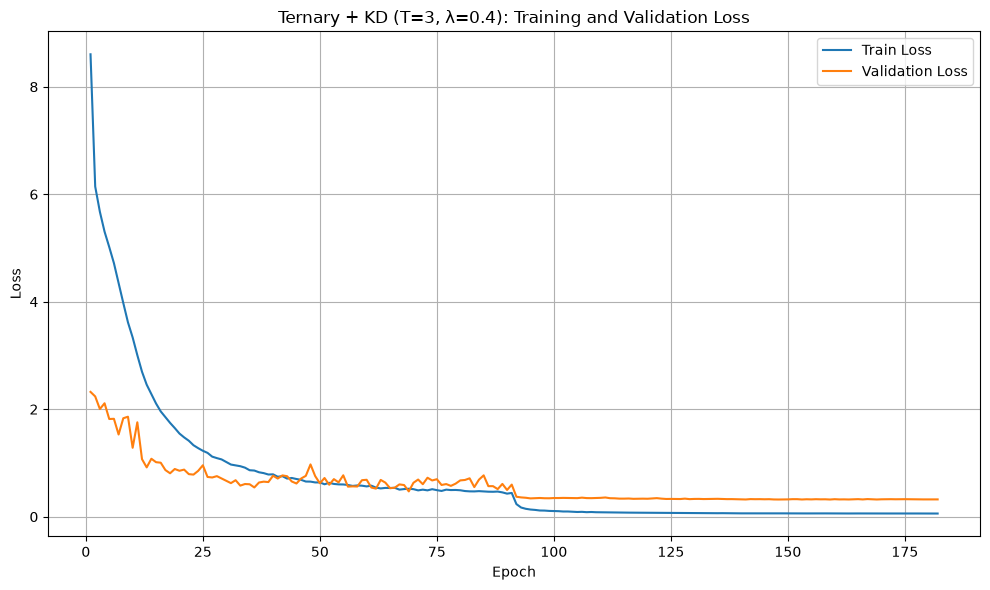

In [137]:
# CELL 127
# Experiment 3 training and validation loss

epochs_exp3 = range(
    1,
    len(history_exp3["train_loss"]) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_exp3,
    history_exp3["train_loss"],
    label="Train Loss"
)

plt.plot(
    epochs_exp3,
    history_exp3["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Ternary + KD (T=3, λ=0.4): "
    "Training and Validation Loss"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

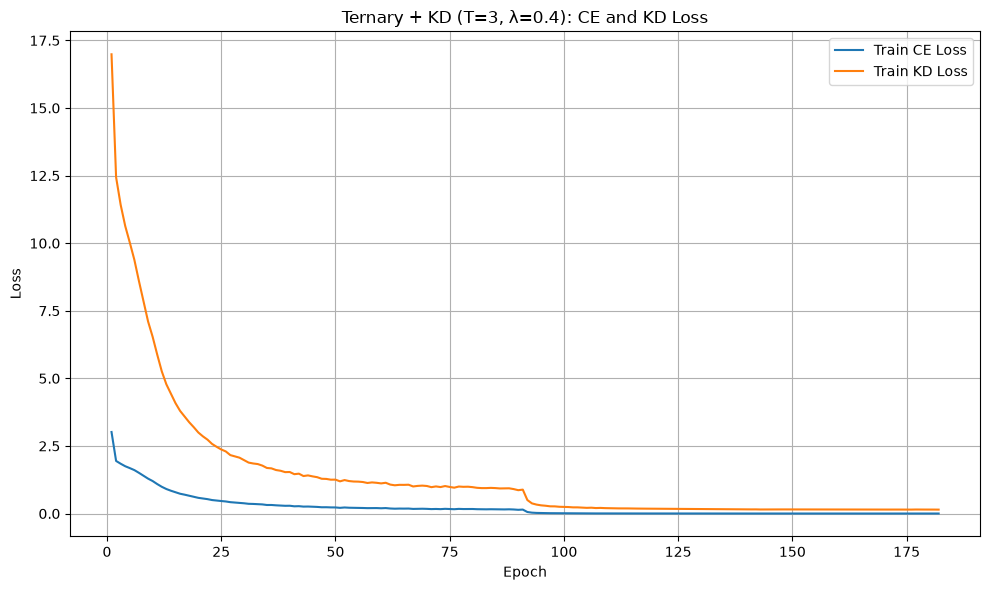

In [138]:
# CELL 128

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_exp3,
    history_exp3["train_ce"],
    label="Train CE Loss"
)

plt.plot(
    epochs_exp3,
    history_exp3["train_kd"],
    label="Train KD Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "Ternary + KD (T=3, λ=0.4): "
    "CE and KD Loss"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

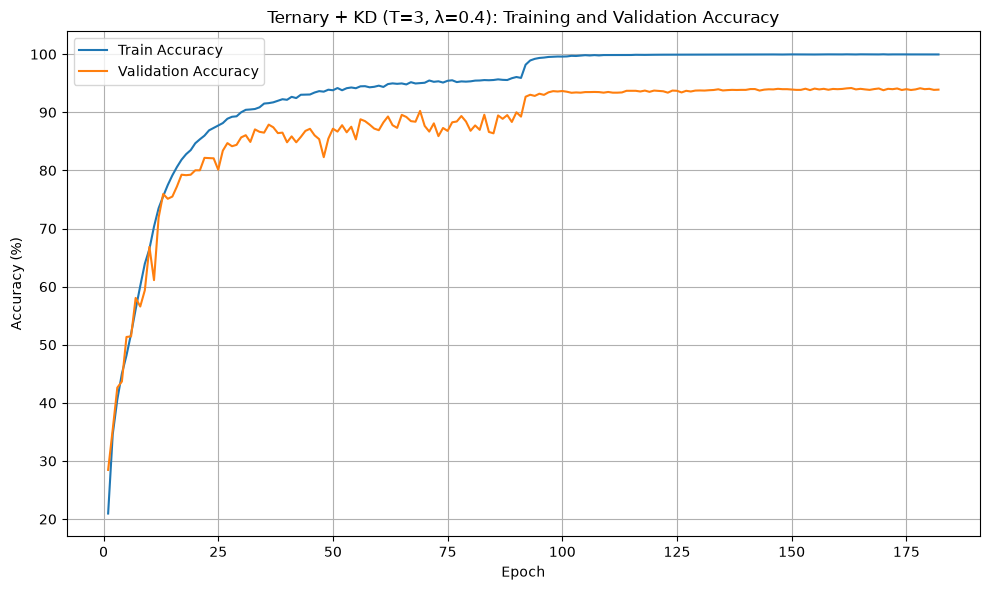

In [139]:
# CELL 129

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_exp3,
    history_exp3["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    epochs_exp3,
    history_exp3["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title(
    "Ternary + KD (T=3, λ=0.4): "
    "Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

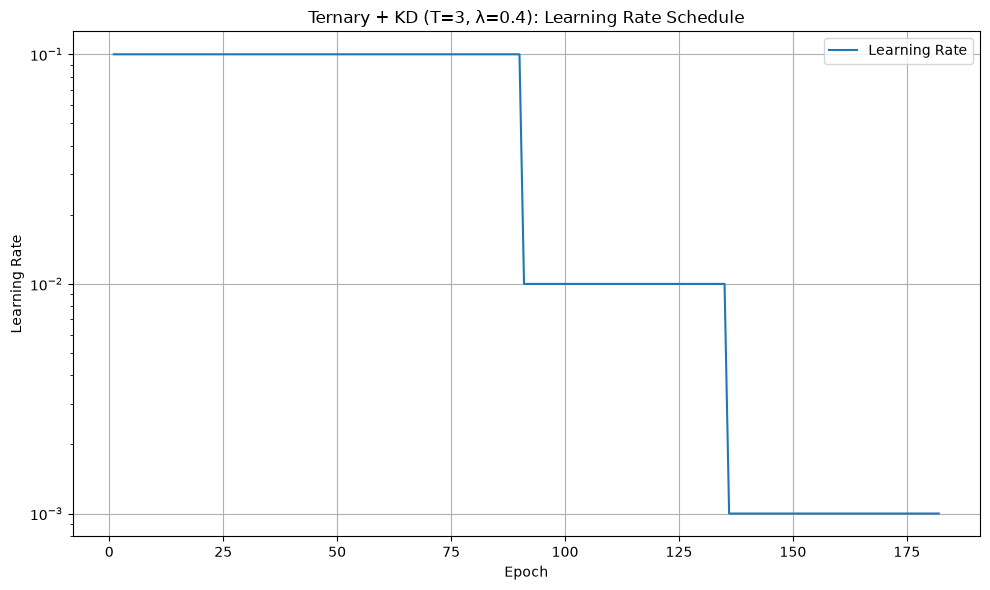

In [140]:
# CELL 130

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_exp3,
    history_exp3["lr"],
    label="Learning Rate"
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title(
    "Ternary + KD (T=3, λ=0.4): "
    "Learning Rate Schedule"
)

plt.yscale("log")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

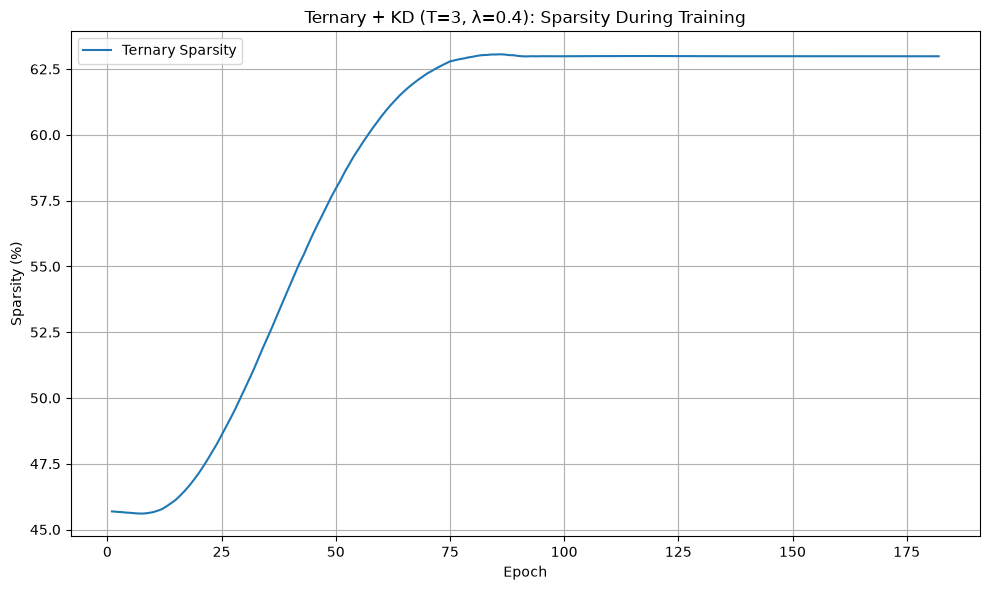

In [141]:
# CELL 131

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_exp3,
    history_exp3["sparsity"],
    label="Ternary Sparsity"
)

plt.xlabel("Epoch")
plt.ylabel("Sparsity (%)")
plt.title(
    "Ternary + KD (T=3, λ=0.4): "
    "Sparsity During Training"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

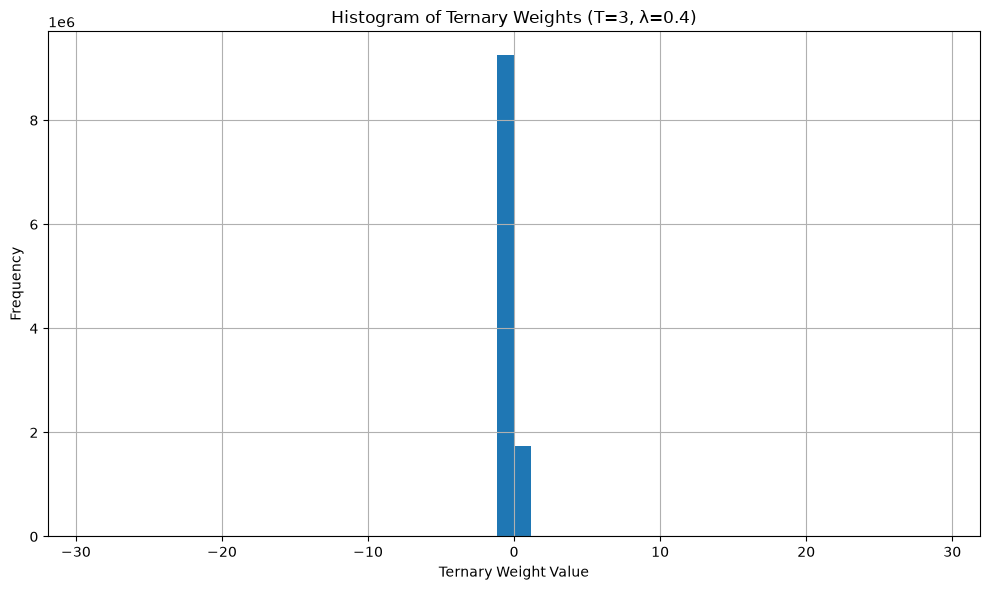

In [142]:
# CELL 132
# Histogram of ternary weights

all_ternary_weights_exp3 = []

with torch.no_grad():

    for module in ternary_student_exp3.modules():

        if isinstance(module, (TernaryConv2d, TernaryLinear)):

            q_weight, _, _ = ternary_quantize(
                module.weight
            )

            all_ternary_weights_exp3.append(
                q_weight.detach()
                .cpu()
                .numpy()
                .flatten()
            )

all_ternary_weights_exp3 = np.concatenate(
    all_ternary_weights_exp3
)

plt.figure(figsize=(10, 6))

plt.hist(
    all_ternary_weights_exp3,
    bins=50
)

plt.xlabel("Ternary Weight Value")
plt.ylabel("Frequency")
plt.title(
    "Histogram of Ternary Weights "
    "(T=3, λ=0.4)"
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [143]:
# CELL 133

zero_count_exp3 = 0
positive_count_exp3 = 0
negative_count_exp3 = 0
total_count_exp3 = 0

with torch.no_grad():

    for module in ternary_student_exp3.modules():

        if isinstance(module, (TernaryConv2d, TernaryLinear)):

            q_weight, _, _ = ternary_quantize(
                module.weight
            )

            zero_count_exp3 += (
                q_weight == 0
            ).sum().item()

            positive_count_exp3 += (
                q_weight > 0
            ).sum().item()

            negative_count_exp3 += (
                q_weight < 0
            ).sum().item()

            total_count_exp3 += q_weight.numel()


zero_percentage_exp3 = (
    100.0 * zero_count_exp3 / total_count_exp3
)

positive_percentage_exp3 = (
    100.0 * positive_count_exp3 / total_count_exp3
)

negative_percentage_exp3 = (
    100.0 * negative_count_exp3 / total_count_exp3
)

print("=" * 70)
print("EXPERIMENT 3 TERNARY WEIGHT DISTRIBUTION")
print("=" * 70)
print(
    f"Zero:       {zero_percentage_exp3:.2f}%"
)
print(
    f"Positive:   {positive_percentage_exp3:.2f}%"
)
print(
    f"Negative:   {negative_percentage_exp3:.2f}%"
)
print("=" * 70)

EXPERIMENT 3 TERNARY WEIGHT DISTRIBUTION
Zero:       62.99%
Positive:   15.89%
Negative:   21.13%


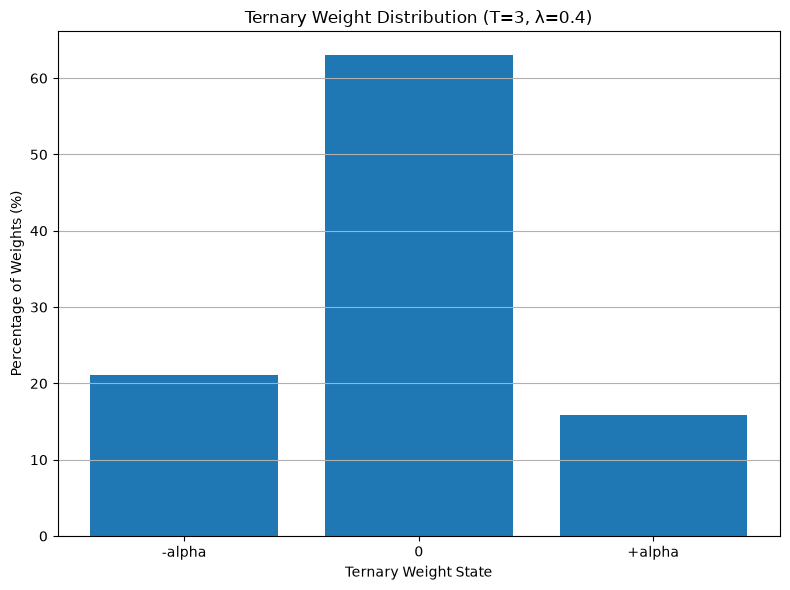

In [144]:
# CELL 134

states_exp3 = [
    "-alpha",
    "0",
    "+alpha"
]

percentages_exp3 = [
    negative_percentage_exp3,
    zero_percentage_exp3,
    positive_percentage_exp3
]

plt.figure(figsize=(8, 6))

plt.bar(
    states_exp3,
    percentages_exp3
)

plt.xlabel("Ternary Weight State")
plt.ylabel("Percentage of Weights (%)")
plt.title(
    "Ternary Weight Distribution "
    "(T=3, λ=0.4)"
)

plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [145]:
# CELL 135

ternary_student_exp3.eval()

all_labels_exp3 = []
all_predictions_exp3 = []
all_confidences_exp3 = []

with torch.no_grad():

    for images, labels in cifarnet_loader:

        images = images.to(device)

        logits = ternary_student_exp3(images)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        confidence, predicted = probabilities.max(
            dim=1
        )

        all_labels_exp3.extend(
            labels.numpy()
        )

        all_predictions_exp3.extend(
            predicted.cpu().numpy()
        )

        all_confidences_exp3.extend(
            confidence.cpu().numpy()
        )

print("=" * 70)
print("CIFARNET EVALUATION — EXPERIMENT 3")
print("=" * 70)
print(
    f"Images evaluated: "
    f"{len(all_labels_exp3)}"
)
print("=" * 70)

CIFARNET EVALUATION — EXPERIMENT 3
Images evaluated: 10000


In [146]:
# CELL 136

correct_exp3 = sum(
    actual == predicted
    for actual, predicted in zip(
        all_labels_exp3,
        all_predictions_exp3
    )
)

total_cifarnet_exp3 = len(all_labels_exp3)

cifarnet_accuracy_exp3 = (
    100.0 *
    correct_exp3 /
    total_cifarnet_exp3
)

print("=" * 70)
print("CIFARNET — EXPERIMENT 3")
print("=" * 70)
print(f"Correct:  {correct_exp3}")
print(f"Total:    {total_cifarnet_exp3}")
print(f"Accuracy: {cifarnet_accuracy_exp3:.2f}%")
print("=" * 70)

CIFARNET — EXPERIMENT 3
Correct:  7190
Total:    10000
Accuracy: 71.90%


In [147]:
# CELL 137

class_stats_exp3 = defaultdict(
    lambda: {
        "correct": 0,
        "total": 0
    }
)

for actual, predicted in zip(
    all_labels_exp3,
    all_predictions_exp3
):

    class_stats_exp3[actual]["total"] += 1

    if actual == predicted:
        class_stats_exp3[actual]["correct"] += 1


print("=" * 70)
print("CIFARNET PER-CLASS ACCURACY — EXPERIMENT 3")
print("=" * 70)

for class_id, class_name in enumerate(classes):

    correct_class = (
        class_stats_exp3[class_id]["correct"]
    )

    total_class = (
        class_stats_exp3[class_id]["total"]
    )

    accuracy_class = (
        100.0 *
        correct_class /
        total_class
    )

    print(
        f"{class_name:12s}: "
        f"{correct_class:4d}/{total_class:4d} "
        f"({accuracy_class:.2f}%)"
    )

print("=" * 70)

CIFARNET PER-CLASS ACCURACY — EXPERIMENT 3
Airplane    :  828/ 965 (85.80%)
Automobile  :  693/1018 (68.07%)
Bird        :  698/1023 (68.23%)
Cat         :  657/ 954 (68.87%)
Deer        :  866/1027 (84.32%)
Dog         :  514/1051 (48.91%)
Frog        :  766/1000 (76.60%)
Horse       :  751/1048 (71.66%)
Ship        :  738/ 946 (78.01%)
Truck       :  679/ 968 (70.14%)


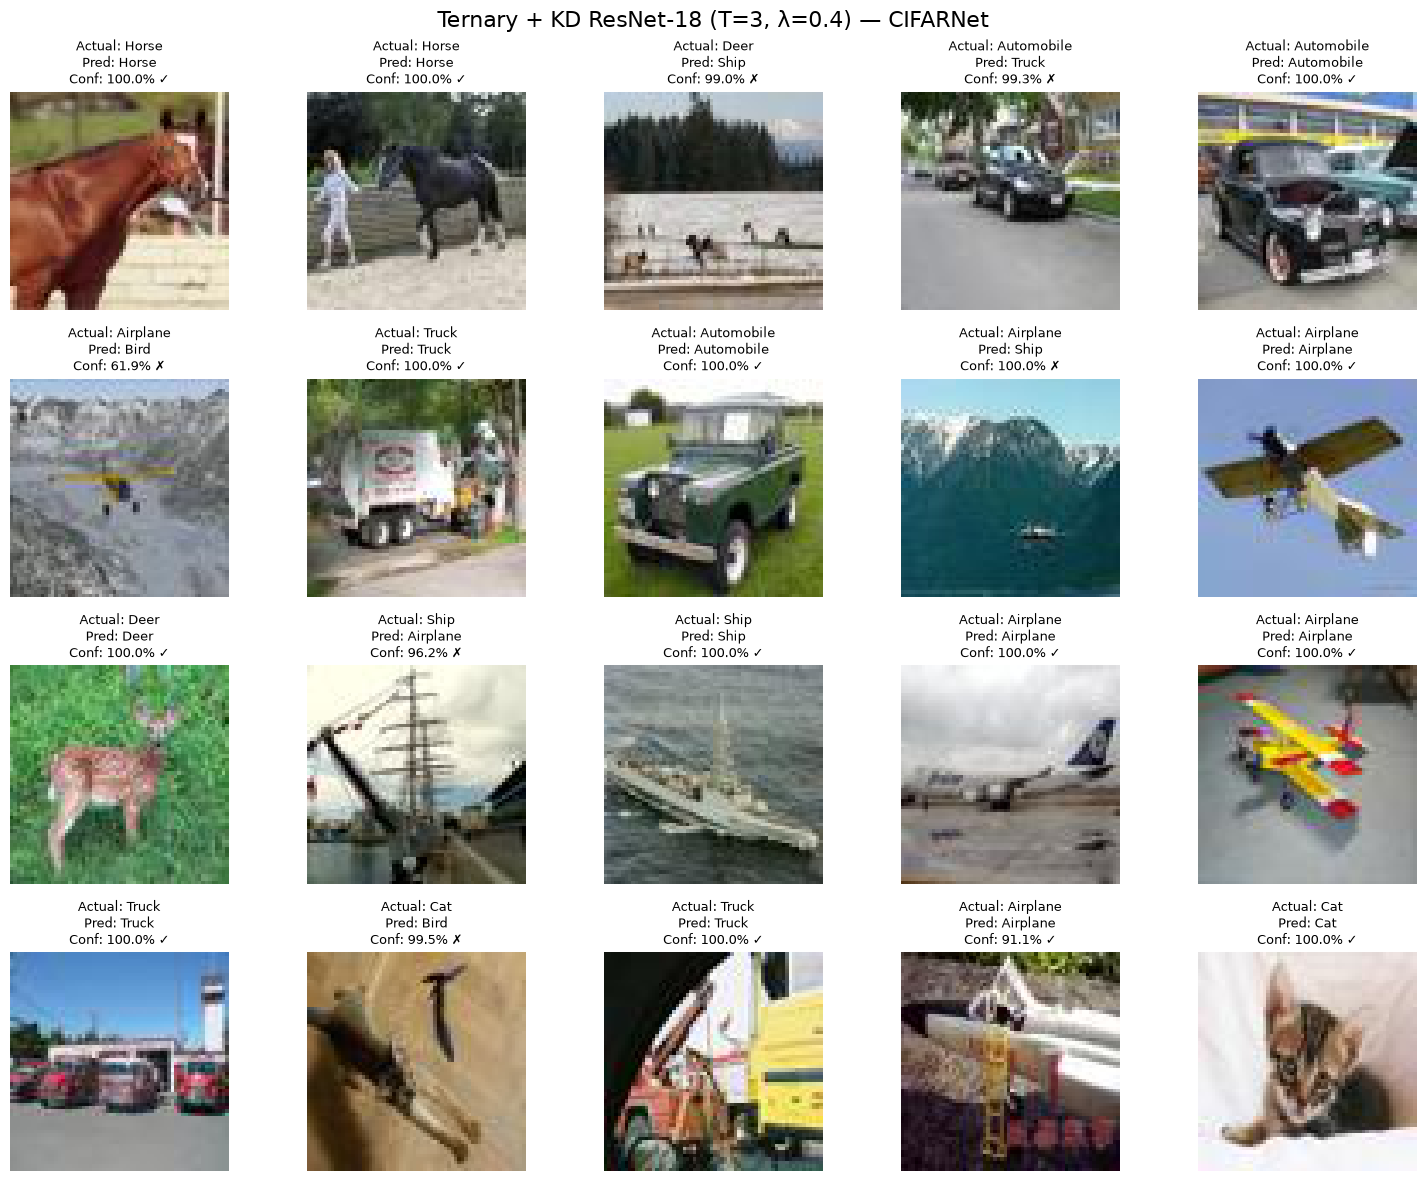

In [148]:
# CELL 138

rng = np.random.default_rng(42)

indices_exp3 = rng.choice(
    len(cifarnet_dataset),
    size=20,
    replace=False
)

fig, axes = plt.subplots(
    4,
    5,
    figsize=(15, 12)
)

for ax, idx in zip(
    axes.ravel(),
    indices_exp3
):

    item = cifarnet_test[int(idx)]

    image = item["img"].convert("RGB")
    actual = item["label"]

    x = cifarnet_transform(image)
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        logits = ternary_student_exp3(x)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        confidence, prediction = probabilities.max(
            dim=1
        )

    predicted = prediction.item()
    confidence = confidence.item() * 100

    status = (
        "✓"
        if actual == predicted
        else "✗"
    )

    ax.imshow(image)

    ax.set_title(
        f"Actual: {classes[actual]}\n"
        f"Pred: {classes[predicted]}\n"
        f"Conf: {confidence:.1f}% {status}",
        fontsize=9
    )

    ax.axis("off")

plt.suptitle(
    "Ternary + KD ResNet-18 "
    "(T=3, λ=0.4) — CIFARNet",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [149]:
# CELL 139

print("=" * 90)
print(
    "CONFIDENCE SCORES — "
    "20 RANDOM CIFARNET IMAGES"
)
print("=" * 90)

for display_idx, idx in enumerate(indices_exp3):

    item = cifarnet_test[int(idx)]

    image = item["img"].convert("RGB")
    actual = item["label"]

    x = cifarnet_transform(image)
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        logits = ternary_student_exp3(x)

        probabilities = torch.softmax(
            logits,
            dim=1
        )[0]

    predicted = probabilities.argmax().item()

    print("\n" + "=" * 90)
    print(f"Image {display_idx + 1}")
    print(f"Actual class:    {classes[actual]}")
    print(f"Predicted class: {classes[predicted]}")
    print("-" * 90)

    for class_id, class_name in enumerate(classes):

        print(
            f"{class_name:12s}: "
            f"{probabilities[class_id].item() * 100:7.2f}%"
        )

CONFIDENCE SCORES — 20 RANDOM CIFARNET IMAGES

Image 1
Actual class:    Horse
Predicted class: Horse
------------------------------------------------------------------------------------------
Airplane    :    0.00%
Automobile  :    0.00%
Bird        :    0.00%
Cat         :    0.00%
Deer        :    0.00%
Dog         :    0.00%
Frog        :    0.00%
Horse       :  100.00%
Ship        :    0.00%
Truck       :    0.00%

Image 2
Actual class:    Horse
Predicted class: Horse
------------------------------------------------------------------------------------------
Airplane    :    0.00%
Automobile  :    0.00%
Bird        :    0.00%
Cat         :    0.00%
Deer        :    0.00%
Dog         :    0.00%
Frog        :    0.00%
Horse       :  100.00%
Ship        :    0.00%
Truck       :    0.00%

Image 3
Actual class:    Deer
Predicted class: Ship
------------------------------------------------------------------------------------------
Airplane    :    0.95%
Automobile  :    0.00%
Bird        

In [150]:
T_EXP4 = 4.0
LAMBDA_KD_EXP4 = 0.25
NUM_EPOCHS_EXP4 = 182

QAT_LR_EXP4 = 0.1
MOMENTUM_EXP4 = 0.9
WEIGHT_DECAY_EXP4 = 1e-4

LR_MILESTONES_EXP4 = [91, 136]
LR_GAMMA_EXP4 = 0.1

In [160]:
ternary_student_exp4 = TernaryResNet18CIFAR(
    num_classes=NUM_CLASSES
).to(device)

print("Experiment 4 Ternary Student created.")
print(f"Temperature: {T_EXP4}")
print(f"Lambda KD: {LAMBDA_KD_EXP4}")
print(f"Total Epochs: {NUM_EPOCHS_EXP4}")

Experiment 4 Ternary Student created.
Temperature: 4.0
Lambda KD: 0.25
Total Epochs: 182


In [161]:
teacher.eval()

for param in teacher.parameters():
    param.requires_grad = False

print("Teacher frozen.")

Teacher frozen.


In [162]:
optimizer_ternary_exp4 = torch.optim.SGD(
    ternary_student_exp4.parameters(),
    lr=QAT_LR_EXP4,
    momentum=MOMENTUM_EXP4,
    weight_decay=WEIGHT_DECAY_EXP4
)

print("Optimizer: SGD")
print(f"Learning Rate: {QAT_LR_EXP4}")
print(f"Momentum: {MOMENTUM_EXP4}")
print(f"Weight Decay: {WEIGHT_DECAY_EXP4}")

Optimizer: SGD
Learning Rate: 0.1
Momentum: 0.9
Weight Decay: 0.0001


In [163]:
scheduler_ternary_exp4 = torch.optim.lr_scheduler.MultiStepLR(
    optimizer_ternary_exp4,
    milestones=LR_MILESTONES_EXP4,
    gamma=LR_GAMMA_EXP4
)

print("Scheduler: MultiStepLR")
print(f"Milestones: {LR_MILESTONES_EXP4}")
print(f"Gamma: {LR_GAMMA_EXP4}")

Scheduler: MultiStepLR
Milestones: [91, 136]
Gamma: 0.1


In [164]:
history_exp4 = {
    "train_loss": [],
    "train_ce": [],
    "train_kd": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": [],
    "sparsity": []
}

best_val_acc_exp4 = 0.0
best_epoch_exp4 = 0

print("Experiment 4 history initialized.")

Experiment 4 history initialized.


In [165]:
best_checkpoint_exp4 = os.path.join(
    CHECKPOINT_DIR,
    "resnet18_cifar10_ternary_kd_T4_lambda025_best.pth"
)

for epoch in range(1, NUM_EPOCHS_EXP4 + 1):

    train_loss, train_ce, train_kd, train_acc = train_one_epoch_kd(
        ternary_student_exp4,
        teacher,
        train_loader,
        optimizer_ternary_exp4,
        device,
        temperature=T_EXP4,
        lambda_kd=LAMBDA_KD_EXP4
    )

    val_loss, val_acc = evaluate_ternary(
        ternary_student_exp4,
        val_loader,
        criterion_ce,
        device
    )

    scheduler_ternary_exp4.step()

    current_lr = optimizer_ternary_exp4.param_groups[0]["lr"]
    current_sparsity = calculate_ternary_sparsity(ternary_student_exp4)

    history_exp4["train_loss"].append(train_loss)
    history_exp4["train_ce"].append(train_ce)
    history_exp4["train_kd"].append(train_kd)
    history_exp4["train_acc"].append(train_acc)
    history_exp4["val_loss"].append(val_loss)
    history_exp4["val_acc"].append(val_acc)
    history_exp4["lr"].append(current_lr)
    history_exp4["sparsity"].append(current_sparsity)

    if val_acc > best_val_acc_exp4:
        best_val_acc_exp4 = val_acc
        best_epoch_exp4 = epoch

        torch.save({
            "epoch": epoch,
            "model_state_dict": ternary_student_exp4.state_dict(),
            "optimizer_state_dict": optimizer_ternary_exp4.state_dict(),
            "scheduler_state_dict": scheduler_ternary_exp4.state_dict(),
            "val_acc": val_acc,
            "temperature": T_EXP4,
            "lambda_kd": LAMBDA_KD_EXP4
        }, best_checkpoint_exp4)

    print(
        f"Epoch [{epoch:3d}/{NUM_EPOCHS_EXP4}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train CE: {train_ce:.4f} | "
        f"Train KD: {train_kd:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}% | "
        f"LR: {current_lr:.6f} | "
        f"Sparsity: {current_sparsity:.2f}%"
    )

print("\nExperiment 4 training completed.")
print(f"Best Validation Accuracy: {best_val_acc_exp4:.2f}%")
print(f"Best Epoch: {best_epoch_exp4}")
print(f"Best Checkpoint: {best_checkpoint_exp4}")

Training:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch [  1/182] | Train Loss: 7.7953 | Train CE: 2.9900 | Train KD: 22.2113 | Train Acc: 22.97% | Val Loss: 1.9477 | Val Acc: 34.46% | LR: 0.100000 | Sparsity: 45.86%


Training:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch [  2/182] | Train Loss: 5.5240 | Train CE: 1.9167 | Train KD: 16.3460 | Train Acc: 36.29% | Val Loss: 1.8398 | Val Acc: 41.38% | LR: 0.100000 | Sparsity: 45.85%


Training:   0%|          | 0/352 [00:00<?, ?it/s]

...

Epoch [180/182] | Train Loss: 0.0645 | Train CE: 0.0013 | Train KD: 0.2538 | Train Acc: 99.96% | Val Loss: 0.3068 | Val Acc: 94.28% | LR: 0.001000 | Sparsity: 60.81%


Training:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch [181/182] | Train Loss: 0.0659 | Train CE: 0.0013 | Train KD: 0.2599 | Train Acc: 99.97% | Val Loss: 0.3058 | Val Acc: 94.18% | LR: 0.001000 | Sparsity: 60.81%


Training:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch [182/182] | Train Loss: 0.0661 | Train CE: 0.0014 | Train KD: 0.2600 | Train Acc: 99.96% | Val Loss: 0.3059 | Val Acc: 94.20% | LR: 0.001000 | Sparsity: 60.81%

Experiment 4 training completed.
Best Validation Accuracy: 94.40%
Best Epoch: 164
Best Checkpoint: /home/sem_7th/ATDL/checkpoints/resnet18_cifar10_ternary_kd_T4_lambda025_best.pth


In [166]:
checkpoint_exp4 = torch.load(
    best_checkpoint_exp4,
    map_location=device
)

ternary_student_exp4.load_state_dict(
    checkpoint_exp4["model_state_dict"]
)

ternary_student_exp4.eval()

print("Best Experiment 4 checkpoint loaded.")
print(f"Best Epoch: {checkpoint_exp4['epoch']}")
print(f"Best Validation Accuracy: {checkpoint_exp4['val_acc']:.2f}%")
print(f"Temperature: {checkpoint_exp4['temperature']}")
print(f"Lambda KD: {checkpoint_exp4['lambda_kd']}")

Best Experiment 4 checkpoint loaded.
Best Epoch: 164
Best Validation Accuracy: 94.40%
Temperature: 4.0
Lambda KD: 0.25


In [167]:
test_loss_exp4, test_acc_exp4 = evaluate_ternary(
    ternary_student_exp4,
    test_loader,
    criterion_ce,
    device
)

print("Experiment 4 Test Results")
print(f"Test Loss: {test_loss_exp4:.4f}")
print(f"Test Accuracy: {test_acc_exp4:.2f}%")

Experiment 4 Test Results
Test Loss: 0.3370
Test Accuracy: 93.55%


In [168]:
print("Experiment 4 Ternary Weight Verification")

for name, module in ternary_student_exp4.named_modules():
    if isinstance(module, (TernaryConv2d, TernaryLinear)):
        with torch.no_grad():
            q_weight, alpha, delta = ternary_quantize(module.weight)

        unique_values = torch.unique(q_weight).detach().cpu().numpy()

        print(
            f"{name:40s} | "
            f"Alpha: {alpha.item():.6f} | "
            f"Delta: {delta.item():.6f} | "
            f"Unique Values: {unique_values}"
        )

Experiment 4 Ternary Weight Verification
conv1                                    | Alpha: 10.259513 | Delta: 3.676324 | Unique Values: [-10.259513   0.        10.259513]
layer1.0.conv1                           | Alpha: 0.161275 | Delta: 0.023840 | Unique Values: [-0.16127548  0.          0.16127548]
layer1.0.conv2                           | Alpha: 0.117523 | Delta: 0.025922 | Unique Values: [-0.11752315  0.          0.11752315]
layer1.1.conv1                           | Alpha: 0.123381 | Delta: 0.025312 | Unique Values: [-0.12338118  0.          0.12338118]
layer1.1.conv2                           | Alpha: 0.109707 | Delta: 0.026536 | Unique Values: [-0.10970683  0.          0.10970683]
layer2.0.conv1                           | Alpha: 0.108772 | Delta: 0.029995 | Unique Values: [-0.10877238  0.          0.10877238]
layer2.0.conv2                           | Alpha: 0.089217 | Delta: 0.028398 | Unique Values: [-0.08921742  0.          0.08921742]
layer2.1.conv1                       

In [169]:
final_sparsity_exp4 = calculate_ternary_sparsity(
    ternary_student_exp4
)

print("Experiment 4 Final Ternary Sparsity")
print(f"Sparsity: {final_sparsity_exp4:.2f}%")

Experiment 4 Final Ternary Sparsity
Sparsity: 60.81%


In [170]:
total_params_exp4 = sum(
    p.numel() for p in ternary_student_exp4.parameters()
)

ternary_params_exp4 = 0
fp32_params_exp4 = 0

for module in ternary_student_exp4.modules():

    if isinstance(module, (TernaryConv2d, TernaryLinear)):
        ternary_params_exp4 += module.weight.numel()

        if module.bias is not None:
            fp32_params_exp4 += module.bias.numel()

    elif isinstance(module, (nn.BatchNorm2d,)):
        for p in module.parameters():
            fp32_params_exp4 += p.numel()

    elif isinstance(module, nn.Conv2d):
        for p in module.parameters():
            fp32_params_exp4 += p.numel()

    elif isinstance(module, nn.Linear):
        for p in module.parameters():
            fp32_params_exp4 += p.numel()

print("Experiment 4 Parameter Breakdown")
print(f"Total Parameters: {total_params_exp4:,}")
print(f"Ternary Weight Parameters: {ternary_params_exp4:,}")
print(f"FP32 Parameters: {fp32_params_exp4:,}")
print(
    f"Parameter Check: "
    f"{ternary_params_exp4 + fp32_params_exp4:,}"
)

Experiment 4 Parameter Breakdown
Total Parameters: 11,173,962
Ternary Weight Parameters: 10,992,320
FP32 Parameters: 181,642
Parameter Check: 11,173,962


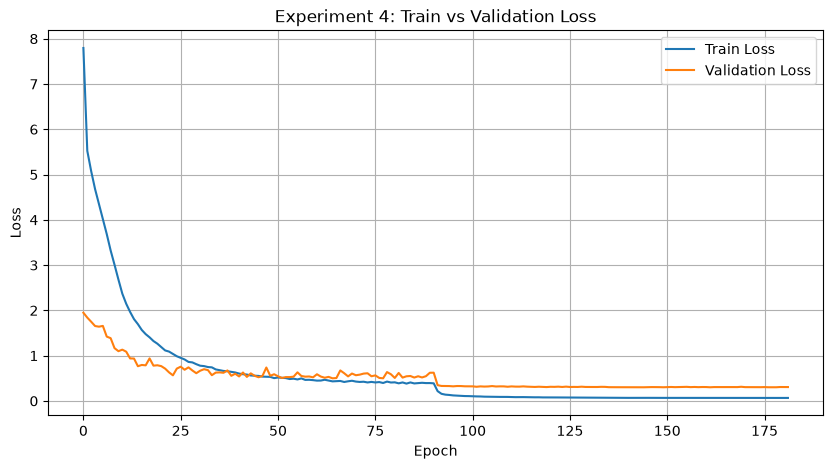

In [171]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_exp4["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_exp4["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 4: Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

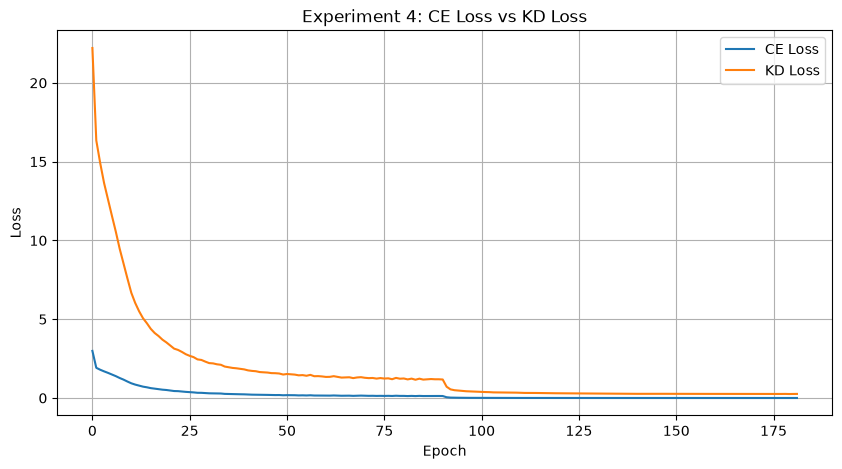

In [172]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_exp4["train_ce"],
    label="CE Loss"
)

plt.plot(
    history_exp4["train_kd"],
    label="KD Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 4: CE Loss vs KD Loss")
plt.legend()
plt.grid(True)
plt.show()

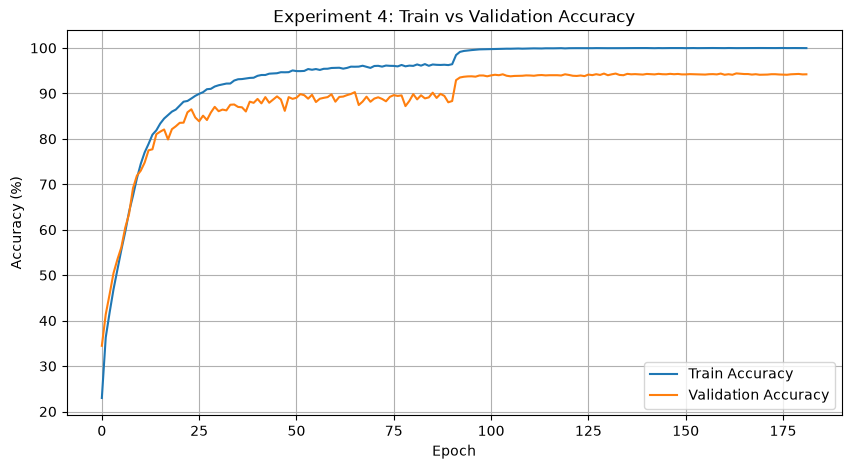

In [173]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_exp4["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    history_exp4["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Experiment 4: Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

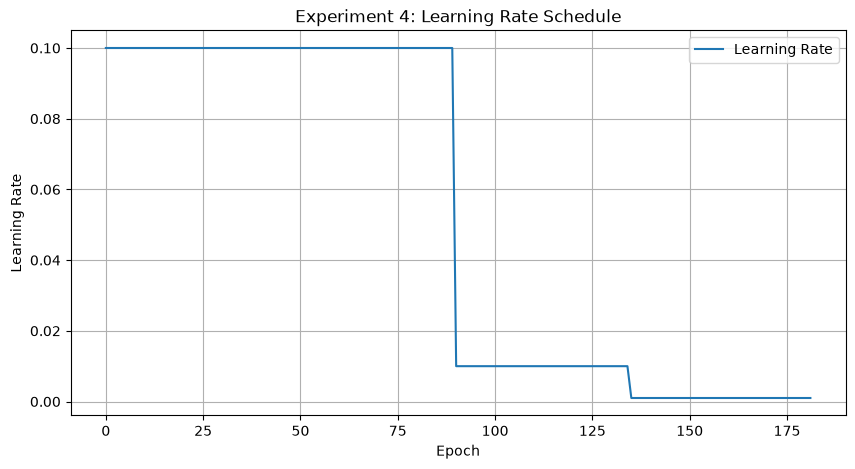

In [174]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_exp4["lr"],
    label="Learning Rate"
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Experiment 4: Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()

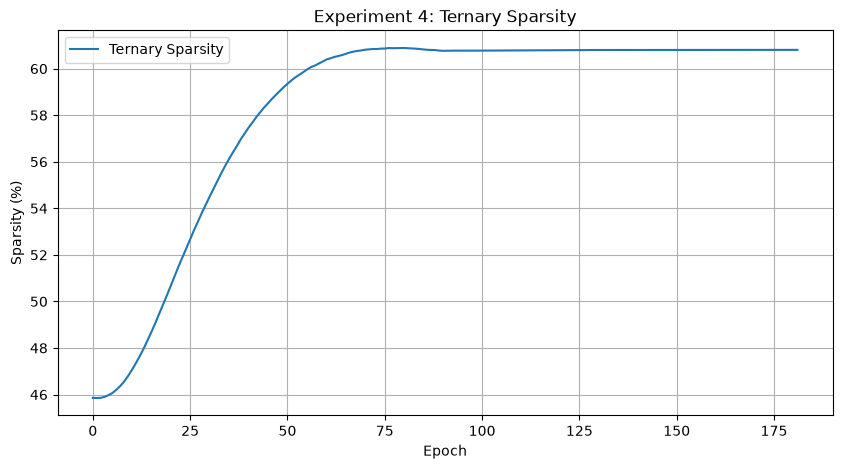

In [175]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_exp4["sparsity"],
    label="Ternary Sparsity"
)

plt.xlabel("Epoch")
plt.ylabel("Sparsity (%)")
plt.title("Experiment 4: Ternary Sparsity")
plt.legend()
plt.grid(True)
plt.show()

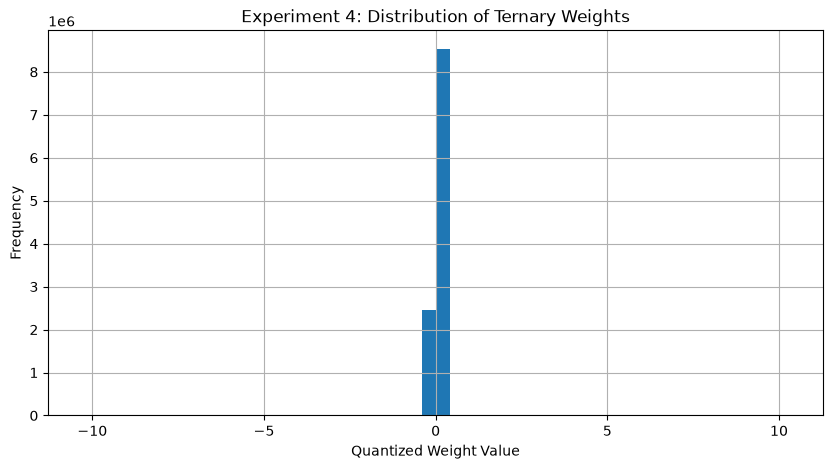

In [176]:
all_ternary_weights_exp4 = []

for module in ternary_student_exp4.modules():
    if isinstance(module, (TernaryConv2d, TernaryLinear)):
        with torch.no_grad():
            q_weight, _, _ = ternary_quantize(module.weight)

        all_ternary_weights_exp4.append(
            q_weight.detach().cpu().flatten().numpy()
        )

all_ternary_weights_exp4 = np.concatenate(
    all_ternary_weights_exp4
)

plt.figure(figsize=(10, 5))

plt.hist(
    all_ternary_weights_exp4,
    bins=50
)

plt.xlabel("Quantized Weight Value")
plt.ylabel("Frequency")
plt.title("Experiment 4: Distribution of Ternary Weights")
plt.grid(True)
plt.show()

In [177]:
zero_count_exp4 = np.sum(
    all_ternary_weights_exp4 == 0
)

positive_count_exp4 = np.sum(
    all_ternary_weights_exp4 > 0
)

negative_count_exp4 = np.sum(
    all_ternary_weights_exp4 < 0
)

total_ternary_weights_exp4 = len(
    all_ternary_weights_exp4
)

print("Experiment 4 Ternary State Distribution")
print(
    f"Zero:     {zero_count_exp4:,} "
    f"({100 * zero_count_exp4 / total_ternary_weights_exp4:.2f}%)"
)
print(
    f"Positive: {positive_count_exp4:,} "
    f"({100 * positive_count_exp4 / total_ternary_weights_exp4:.2f}%)"
)
print(
    f"Negative: {negative_count_exp4:,} "
    f"({100 * negative_count_exp4 / total_ternary_weights_exp4:.2f}%)"
)

Experiment 4 Ternary State Distribution
Zero:     6,684,172 (60.81%)
Positive: 1,852,825 (16.86%)
Negative: 2,455,323 (22.34%)


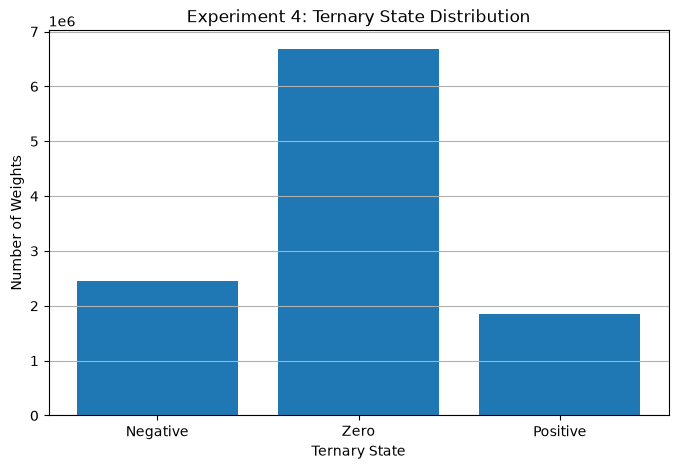

In [178]:
states_exp4 = ["Negative", "Zero", "Positive"]

counts_exp4 = [
    negative_count_exp4,
    zero_count_exp4,
    positive_count_exp4
]

plt.figure(figsize=(8, 5))

plt.bar(
    states_exp4,
    counts_exp4
)

plt.xlabel("Ternary State")
plt.ylabel("Number of Weights")
plt.title("Experiment 4: Ternary State Distribution")
plt.grid(axis="y")
plt.show()

In [179]:
ternary_student_exp4.eval()

correct_exp4 = 0
total_exp4 = 0

with torch.no_grad():

    for images, labels in cifarnet_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = ternary_student_exp4(images)
        predictions = outputs.argmax(dim=1)

        total_exp4 += labels.size(0)
        correct_exp4 += (
            predictions == labels
        ).sum().item()

cifarnet_acc_exp4 = (
    100.0 * correct_exp4 / total_exp4
)

print("Experiment 4 CIFARNet Results")
print(f"Total Images: {total_exp4}")
print(f"Correct Predictions: {correct_exp4}")
print(f"CIFARNet Accuracy: {cifarnet_acc_exp4:.2f}%")

Experiment 4 CIFARNet Results
Total Images: 10000
Correct Predictions: 7276
CIFARNet Accuracy: 72.76%


In [180]:
print("Experiment 4 CIFARNet Accuracy")
print(f"Accuracy: {cifarnet_acc_exp4:.2f}%")

Experiment 4 CIFARNet Accuracy
Accuracy: 72.76%


In [182]:
class_names = [
    "Aeroplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

In [183]:
class_correct_exp4 = [0] * len(class_names)
class_total_exp4 = [0] * len(class_names)

ternary_student_exp4.eval()

with torch.no_grad():

    for images, labels in cifarnet_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = ternary_student_exp4(images)
        predictions = outputs.argmax(dim=1)

        for i in range(labels.size(0)):

            label = labels[i].item()
            prediction = predictions[i].item()

            class_total_exp4[label] += 1

            if prediction == label:
                class_correct_exp4[label] += 1

print("Experiment 4 CIFARNet Per-Class Accuracy")

for i, class_name in enumerate(class_names):

    accuracy = (
        100.0 * class_correct_exp4[i] /
        class_total_exp4[i]
        if class_total_exp4[i] > 0
        else 0.0
    )

    print(
        f"{class_name:12s}: "
        f"{accuracy:.2f}% "
        f"({class_correct_exp4[i]}/{class_total_exp4[i]})"
    )

Experiment 4 CIFARNet Per-Class Accuracy
Aeroplane   : 83.73% (808/965)
Automobile  : 67.88% (691/1018)
Bird        : 65.88% (674/1023)
Cat         : 67.51% (644/954)
Deer        : 84.32% (866/1027)
Dog         : 51.76% (544/1051)
Frog        : 80.80% (808/1000)
Horse       : 73.57% (771/1048)
Ship        : 80.66% (763/946)
Truck       : 73.04% (707/968)


In [185]:
from datasets import load_dataset

cifarnet_val = load_dataset(
    "EleutherAI/cifarnet",
    split="test"
)

print(f"CIFARNet test images: {len(cifarnet_val)}")

CIFARNet test images: 10000


In [187]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

print("CIFARNet transform defined.")

CIFARNet transform defined.


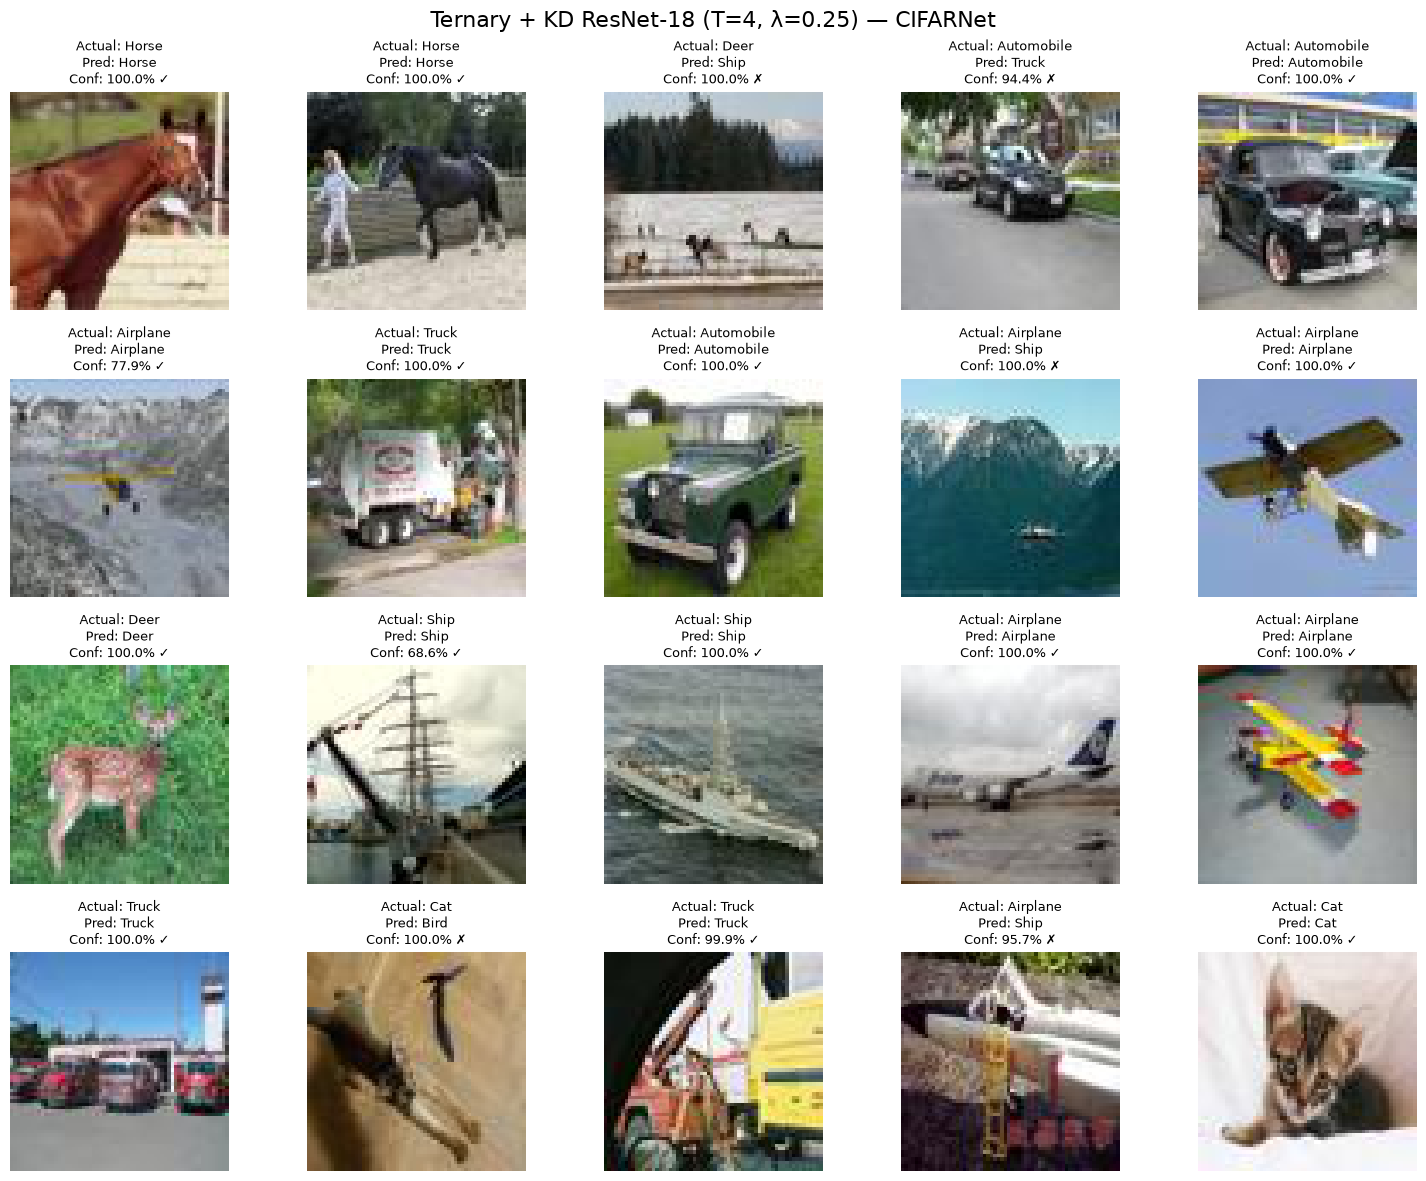

In [190]:
rng = np.random.default_rng(42)

indices_exp4 = rng.choice(
    len(cifarnet_dataset),
    size=20,
    replace=False
)

fig, axes = plt.subplots(
    4,
    5,
    figsize=(15, 12)
)

for ax, idx in zip(
    axes.ravel(),
    indices_exp4
):

    item = cifarnet_test[int(idx)]

    image = item["img"].convert("RGB")
    actual = item["label"]

    x = cifarnet_transform(image)
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        logits = ternary_student_exp4(x)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        confidence, prediction = probabilities.max(
            dim=1
        )

    predicted = prediction.item()
    confidence = confidence.item() * 100

    status = (
        "✓"
        if actual == predicted
        else "✗"
    )

    ax.imshow(image)

    ax.set_title(
        f"Actual: {classes[actual]}\n"
        f"Pred: {classes[predicted]}\n"
        f"Conf: {confidence:.1f}% {status}",
        fontsize=9
    )

    ax.axis("off")

plt.suptitle(
    "Ternary + KD ResNet-18 "
    "(T=4, λ=0.25) — CIFARNet",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [191]:
print("=" * 90)
print(
    "CONFIDENCE SCORES — "
    "20 RANDOM CIFARNET IMAGES"
)
print("=" * 90)

for display_idx, idx in enumerate(indices_exp4):

    item = cifarnet_test[int(idx)]

    image = item["img"].convert("RGB")
    actual = item["label"]

    x = cifarnet_transform(image)
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        logits = ternary_student_exp4(x)

        probabilities = torch.softmax(
            logits,
            dim=1
        )[0]

    predicted = probabilities.argmax().item()

    print("\n" + "=" * 90)
    print(f"Image {display_idx + 1}")
    print(f"Actual class:    {classes[actual]}")
    print(f"Predicted class: {classes[predicted]}")
    print("-" * 90)

    for class_id, class_name in enumerate(classes):

        print(
            f"{class_name:12s}: "
            f"{probabilities[class_id].item() * 100:7.2f}%"
        )

CONFIDENCE SCORES — 20 RANDOM CIFARNET IMAGES

Image 1
Actual class:    Horse
Predicted class: Horse
------------------------------------------------------------------------------------------
Airplane    :    0.00%
Automobile  :    0.00%
Bird        :    0.00%
Cat         :    0.00%
Deer        :    0.00%
Dog         :    0.00%
Frog        :    0.00%
Horse       :  100.00%
Ship        :    0.00%
Truck       :    0.00%

Image 2
Actual class:    Horse
Predicted class: Horse
------------------------------------------------------------------------------------------
Airplane    :    0.00%
Automobile  :    0.00%
Bird        :    0.00%
Cat         :    0.01%
Deer        :    0.00%
Dog         :    0.00%
Frog        :    0.00%
Horse       :   99.99%
Ship        :    0.00%
Truck       :    0.00%

Image 3
Actual class:    Deer
Predicted class: Ship
------------------------------------------------------------------------------------------
Airplane    :    0.00%
Automobile  :    0.00%
Bird        

In [192]:
T_EXP5 = 4.0
LAMBDA_KD_EXP5 = 0.4
NUM_EPOCHS_EXP5 = 182

QAT_LR_EXP5 = 0.1
MOMENTUM_EXP5 = 0.9
WEIGHT_DECAY_EXP5 = 1e-4

LR_MILESTONES_EXP5 = [91, 136]
LR_GAMMA_EXP5 = 0.1

print("Experiment 5 Configuration")
print(f"Temperature: {T_EXP5}")
print(f"Lambda KD: {LAMBDA_KD_EXP5}")
print(f"Total Epochs: {NUM_EPOCHS_EXP5}")
print(f"Learning Rate: {QAT_LR_EXP5}")
print(f"Momentum: {MOMENTUM_EXP5}")
print(f"Weight Decay: {WEIGHT_DECAY_EXP5}")
print(f"LR Milestones: {LR_MILESTONES_EXP5}")
print(f"LR Gamma: {LR_GAMMA_EXP5}")

Experiment 5 Configuration
Temperature: 4.0
Lambda KD: 0.4
Total Epochs: 182
Learning Rate: 0.1
Momentum: 0.9
Weight Decay: 0.0001
LR Milestones: [91, 136]
LR Gamma: 0.1


In [193]:
ternary_student_exp5 = TernaryResNet18CIFAR(
    num_classes=NUM_CLASSES
).to(device)

print("Experiment 5 Ternary Student created.")
print(f"Temperature: {T_EXP5}")
print(f"Lambda KD: {LAMBDA_KD_EXP5}")
print(f"Total Epochs: {NUM_EPOCHS_EXP5}")

Experiment 5 Ternary Student created.
Temperature: 4.0
Lambda KD: 0.4
Total Epochs: 182


In [194]:
teacher.eval()

for param in teacher.parameters():
    param.requires_grad = False

print("Teacher frozen.")

Teacher frozen.


In [195]:
optimizer_ternary_exp5 = torch.optim.SGD(
    ternary_student_exp5.parameters(),
    lr=QAT_LR_EXP5,
    momentum=MOMENTUM_EXP5,
    weight_decay=WEIGHT_DECAY_EXP5
)

print("Optimizer: SGD")
print(f"Learning Rate: {QAT_LR_EXP5}")
print(f"Momentum: {MOMENTUM_EXP5}")
print(f"Weight Decay: {WEIGHT_DECAY_EXP5}")

Optimizer: SGD
Learning Rate: 0.1
Momentum: 0.9
Weight Decay: 0.0001


In [196]:
scheduler_ternary_exp5 = torch.optim.lr_scheduler.MultiStepLR(
    optimizer_ternary_exp5,
    milestones=LR_MILESTONES_EXP5,
    gamma=LR_GAMMA_EXP5
)

print("Scheduler: MultiStepLR")
print(f"Milestones: {LR_MILESTONES_EXP5}")
print(f"Gamma: {LR_GAMMA_EXP5}")

Scheduler: MultiStepLR
Milestones: [91, 136]
Gamma: 0.1


In [197]:
history_exp5 = {
    "train_loss": [],
    "train_ce": [],
    "train_kd": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": [],
    "sparsity": []
}

best_val_acc_exp5 = 0.0
best_epoch_exp5 = 0

print("Experiment 5 history initialized.")

Experiment 5 history initialized.


In [198]:
best_checkpoint_exp5 = os.path.join(
    CHECKPOINT_DIR,
    "resnet18_cifar10_ternary_kd_T4_lambda04_best.pth"
)

for epoch in range(1, NUM_EPOCHS_EXP5 + 1):

    train_loss, train_ce, train_kd, train_acc = train_one_epoch_kd(
        ternary_student_exp5,
        teacher,
        train_loader,
        optimizer_ternary_exp5,
        device,
        temperature=T_EXP5,
        lambda_kd=LAMBDA_KD_EXP5
    )

    val_loss, val_acc = evaluate_ternary(
        ternary_student_exp5,
        val_loader,
        criterion_ce,
        device
    )

    scheduler_ternary_exp5.step()

    current_lr = optimizer_ternary_exp5.param_groups[0]["lr"]
    current_sparsity = calculate_ternary_sparsity(
        ternary_student_exp5
    )

    history_exp5["train_loss"].append(train_loss)
    history_exp5["train_ce"].append(train_ce)
    history_exp5["train_kd"].append(train_kd)
    history_exp5["train_acc"].append(train_acc)
    history_exp5["val_loss"].append(val_loss)
    history_exp5["val_acc"].append(val_acc)
    history_exp5["lr"].append(current_lr)
    history_exp5["sparsity"].append(current_sparsity)

    if val_acc > best_val_acc_exp5:
        best_val_acc_exp5 = val_acc
        best_epoch_exp5 = epoch

        torch.save({
            "epoch": epoch,
            "model_state_dict": ternary_student_exp5.state_dict(),
            "optimizer_state_dict": optimizer_ternary_exp5.state_dict(),
            "scheduler_state_dict": scheduler_ternary_exp5.state_dict(),
            "val_acc": val_acc,
            "temperature": T_EXP5,
            "lambda_kd": LAMBDA_KD_EXP5
        }, best_checkpoint_exp5)

    print(
        f"Epoch [{epoch:3d}/{NUM_EPOCHS_EXP5}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train CE: {train_ce:.4f} | "
        f"Train KD: {train_kd:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}% | "
        f"LR: {current_lr:.6f} | "
        f"Sparsity: {current_sparsity:.2f}%"
    )

print("\nExperiment 5 training completed.")
print(f"Best Validation Accuracy: {best_val_acc_exp5:.2f}%")
print(f"Best Epoch: {best_epoch_exp5}")
print(f"Best Checkpoint: {best_checkpoint_exp5}")

Training:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch [  1/182] | Train Loss: 10.4748 | Train CE: 3.0164 | Train KD: 21.6624 | Train Acc: 21.59% | Val Loss: 2.2329 | Val Acc: 28.22% | LR: 0.100000 | Sparsity: 46.85%


Training:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch [  2/182] | Train Loss: 7.8481 | Train CE: 2.0693 | Train KD: 16.5162 | Train Acc: 33.22% | Val Loss: 2.2568 | Val Acc: 37.84% | LR: 0.100000 | Sparsity: 46.84%


Training:   0%|          | 0/352 [00:00<?, ?it/s]

...

Epoch [180/182] | Train Loss: 0.1001 | Train CE: 0.0013 | Train KD: 0.2483 | Train Acc: 99.96% | Val Loss: 0.3307 | Val Acc: 93.88% | LR: 0.001000 | Sparsity: 64.16%


Training:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch [181/182] | Train Loss: 0.1001 | Train CE: 0.0015 | Train KD: 0.2479 | Train Acc: 99.96% | Val Loss: 0.3269 | Val Acc: 94.08% | LR: 0.001000 | Sparsity: 64.16%


Training:   0%|          | 0/352 [00:00<?, ?it/s]

Epoch [182/182] | Train Loss: 0.1005 | Train CE: 0.0015 | Train KD: 0.2488 | Train Acc: 99.96% | Val Loss: 0.3273 | Val Acc: 93.92% | LR: 0.001000 | Sparsity: 64.16%

Experiment 5 training completed.
Best Validation Accuracy: 94.18%
Best Epoch: 135
Best Checkpoint: /home/sem_7th/ATDL/checkpoints/resnet18_cifar10_ternary_kd_T4_lambda04_best.pth


In [199]:
checkpoint_exp5 = torch.load(
    best_checkpoint_exp5,
    map_location=device
)

ternary_student_exp5.load_state_dict(
    checkpoint_exp5["model_state_dict"]
)

ternary_student_exp5.eval()

print("Best Experiment 5 checkpoint loaded.")
print(f"Best Epoch: {checkpoint_exp5['epoch']}")
print(f"Best Validation Accuracy: {checkpoint_exp5['val_acc']:.2f}%")
print(f"Temperature: {checkpoint_exp5['temperature']}")
print(f"Lambda KD: {checkpoint_exp5['lambda_kd']}")

Best Experiment 5 checkpoint loaded.
Best Epoch: 135
Best Validation Accuracy: 94.18%
Temperature: 4.0
Lambda KD: 0.4


In [200]:
test_loss_exp5, test_acc_exp5 = evaluate_ternary(
    ternary_student_exp5,
    test_loader,
    criterion_ce,
    device
)

print("Experiment 5 Test Results")
print(f"Test Loss: {test_loss_exp5:.4f}")
print(f"Test Accuracy: {test_acc_exp5:.2f}%")

Experiment 5 Test Results
Test Loss: 0.3661
Test Accuracy: 93.31%


In [201]:
print("Experiment 5 Ternary Weight Verification")

for name, module in ternary_student_exp5.named_modules():

    if isinstance(module, (TernaryConv2d, TernaryLinear)):

        with torch.no_grad():
            q_weight, alpha, delta = ternary_quantize(
                module.weight
            )

        unique_values = (
            torch.unique(q_weight)
            .detach()
            .cpu()
            .numpy()
        )

        print(
            f"{name:40s} | "
            f"Alpha: {alpha.item():.6f} | "
            f"Delta: {delta.item():.6f} | "
            f"Unique Values: {unique_values}"
        )

Experiment 5 Ternary Weight Verification
conv1                                    | Alpha: 16.125618 | Delta: 4.440481 | Unique Values: [-16.125618   0.        16.125618]
layer1.0.conv1                           | Alpha: 0.164866 | Delta: 0.033216 | Unique Values: [-0.1648663  0.         0.1648663]
layer1.0.conv2                           | Alpha: 0.139081 | Delta: 0.034453 | Unique Values: [-0.139081  0.        0.139081]
layer1.1.conv1                           | Alpha: 0.150716 | Delta: 0.036563 | Unique Values: [-0.15071583  0.          0.15071583]
layer1.1.conv2                           | Alpha: 0.144689 | Delta: 0.036873 | Unique Values: [-0.1446886  0.         0.1446886]
layer2.0.conv1                           | Alpha: 0.137205 | Delta: 0.034772 | Unique Values: [-0.13720503  0.          0.13720503]
layer2.0.conv2                           | Alpha: 0.116924 | Delta: 0.032351 | Unique Values: [-0.11692433  0.          0.11692433]
layer2.1.conv1                           | Alpha:

In [202]:
final_sparsity_exp5 = calculate_ternary_sparsity(
    ternary_student_exp5
)

print("Experiment 5 Final Ternary Sparsity")
print(f"Sparsity: {final_sparsity_exp5:.2f}%")

Experiment 5 Final Ternary Sparsity
Sparsity: 64.16%


In [203]:
total_params_exp5 = sum(
    p.numel()
    for p in ternary_student_exp5.parameters()
)

ternary_params_exp5 = 0
fp32_params_exp5 = 0

for module in ternary_student_exp5.modules():

    if isinstance(module, (TernaryConv2d, TernaryLinear)):

        ternary_params_exp5 += module.weight.numel()

        if module.bias is not None:
            fp32_params_exp5 += module.bias.numel()

    elif isinstance(module, nn.BatchNorm2d):

        for p in module.parameters():
            fp32_params_exp5 += p.numel()

    elif isinstance(module, nn.Conv2d):

        for p in module.parameters():
            fp32_params_exp5 += p.numel()

    elif isinstance(module, nn.Linear):

        for p in module.parameters():
            fp32_params_exp5 += p.numel()

print("Experiment 5 Parameter Breakdown")
print(f"Total Parameters: {total_params_exp5:,}")
print(f"Ternary Weight Parameters: {ternary_params_exp5:,}")
print(f"FP32 Parameters: {fp32_params_exp5:,}")
print(
    f"Parameter Check: "
    f"{ternary_params_exp5 + fp32_params_exp5:,}"
)

Experiment 5 Parameter Breakdown
Total Parameters: 11,173,962
Ternary Weight Parameters: 10,992,320
FP32 Parameters: 181,642
Parameter Check: 11,173,962


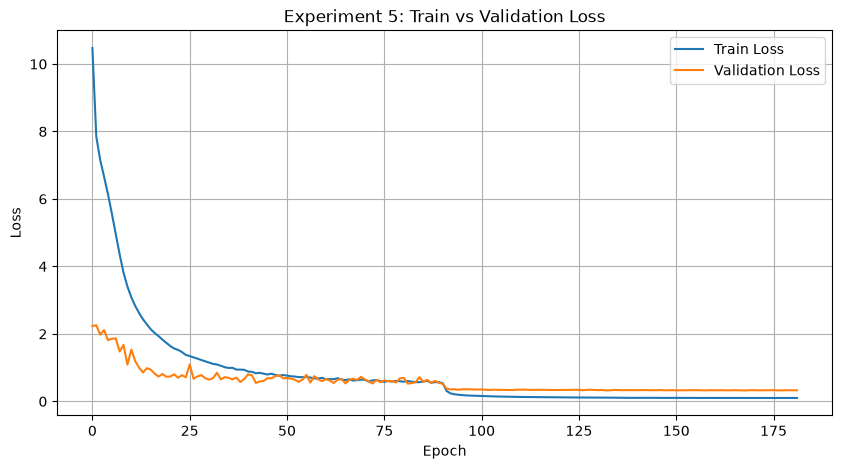

In [204]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_exp5["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_exp5["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 5: Train vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

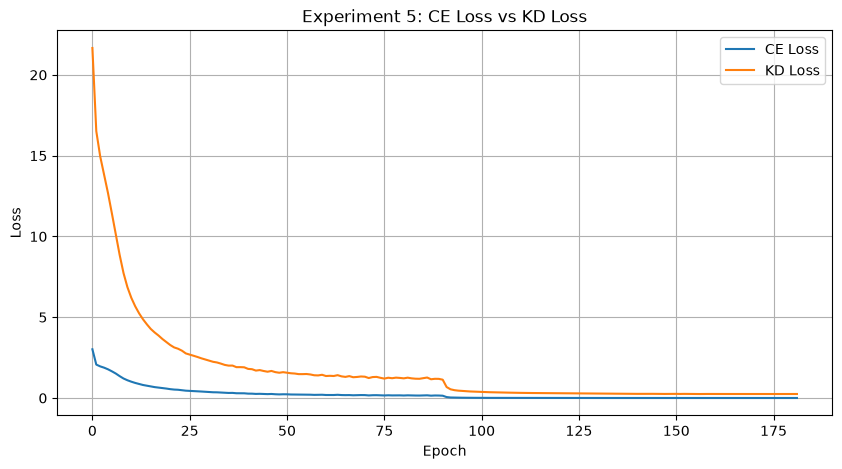

In [205]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_exp5["train_ce"],
    label="CE Loss"
)

plt.plot(
    history_exp5["train_kd"],
    label="KD Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Experiment 5: CE Loss vs KD Loss")
plt.legend()
plt.grid(True)
plt.show()

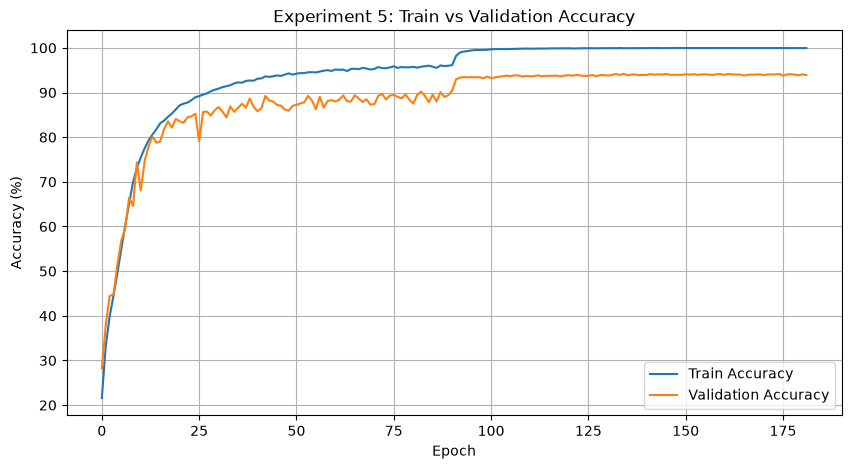

In [206]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_exp5["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    history_exp5["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Experiment 5: Train vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

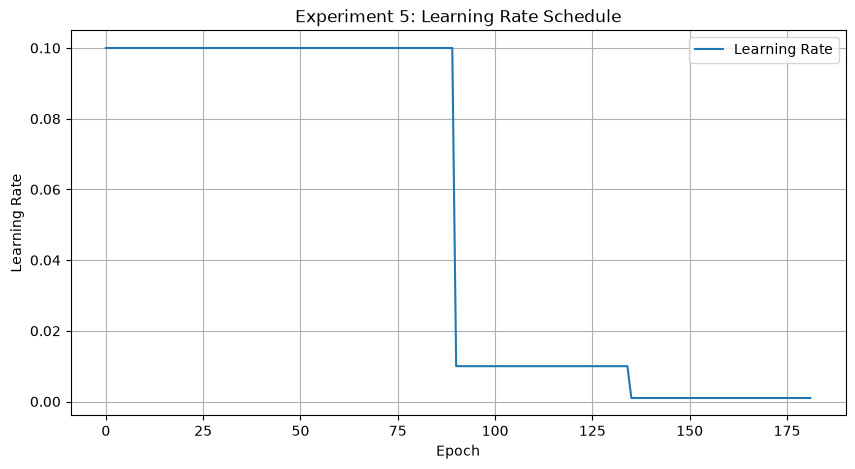

In [207]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_exp5["lr"],
    label="Learning Rate"
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Experiment 5: Learning Rate Schedule")
plt.legend()
plt.grid(True)
plt.show()

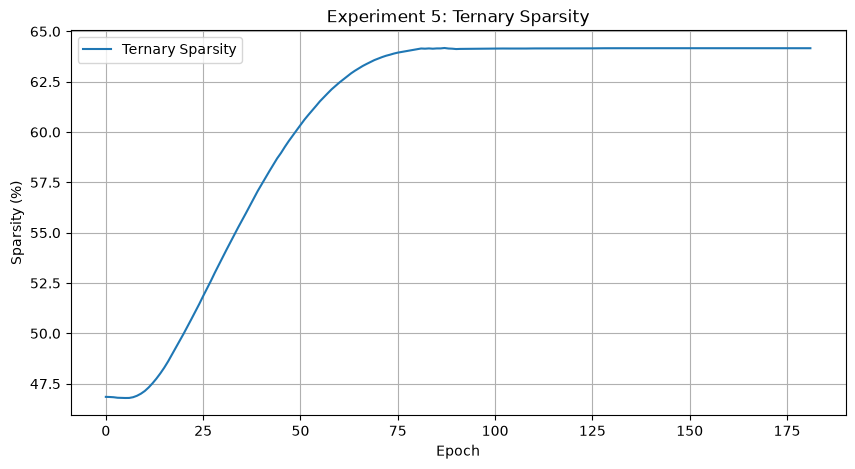

In [208]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_exp5["sparsity"],
    label="Ternary Sparsity"
)

plt.xlabel("Epoch")
plt.ylabel("Sparsity (%)")
plt.title("Experiment 5: Ternary Sparsity")
plt.legend()
plt.grid(True)
plt.show()

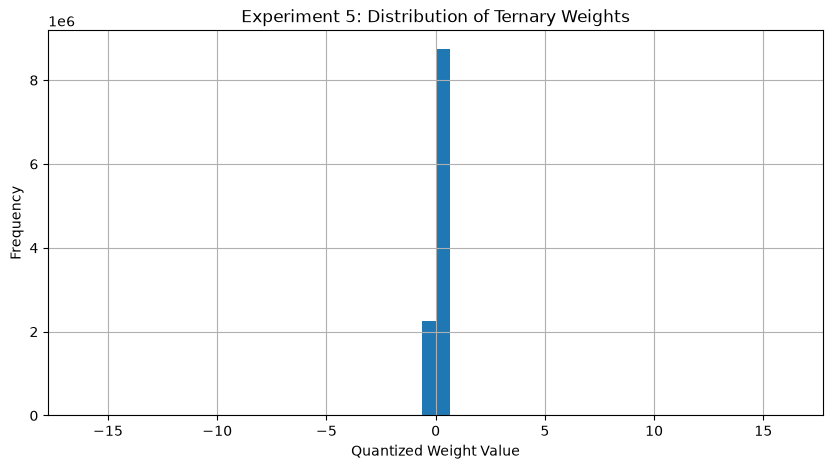

In [209]:
all_ternary_weights_exp5 = []

for module in ternary_student_exp5.modules():

    if isinstance(module, (TernaryConv2d, TernaryLinear)):

        with torch.no_grad():
            q_weight, _, _ = ternary_quantize(
                module.weight
            )

        all_ternary_weights_exp5.append(
            q_weight.detach()
            .cpu()
            .flatten()
            .numpy()
        )

all_ternary_weights_exp5 = np.concatenate(
    all_ternary_weights_exp5
)

plt.figure(figsize=(10, 5))

plt.hist(
    all_ternary_weights_exp5,
    bins=50
)

plt.xlabel("Quantized Weight Value")
plt.ylabel("Frequency")
plt.title("Experiment 5: Distribution of Ternary Weights")
plt.grid(True)
plt.show()

In [210]:
zero_count_exp5 = np.sum(
    all_ternary_weights_exp5 == 0
)

positive_count_exp5 = np.sum(
    all_ternary_weights_exp5 > 0
)

negative_count_exp5 = np.sum(
    all_ternary_weights_exp5 < 0
)

total_ternary_weights_exp5 = len(
    all_ternary_weights_exp5
)

print("Experiment 5 Ternary State Distribution")

print(
    f"Zero:     {zero_count_exp5:,} "
    f"({100 * zero_count_exp5 / total_ternary_weights_exp5:.2f}%)"
)

print(
    f"Positive: {positive_count_exp5:,} "
    f"({100 * positive_count_exp5 / total_ternary_weights_exp5:.2f}%)"
)

print(
    f"Negative: {negative_count_exp5:,} "
    f"({100 * negative_count_exp5 / total_ternary_weights_exp5:.2f}%)"
)

Experiment 5 Ternary State Distribution
Zero:     7,052,812 (64.16%)
Positive: 1,694,898 (15.42%)
Negative: 2,244,610 (20.42%)


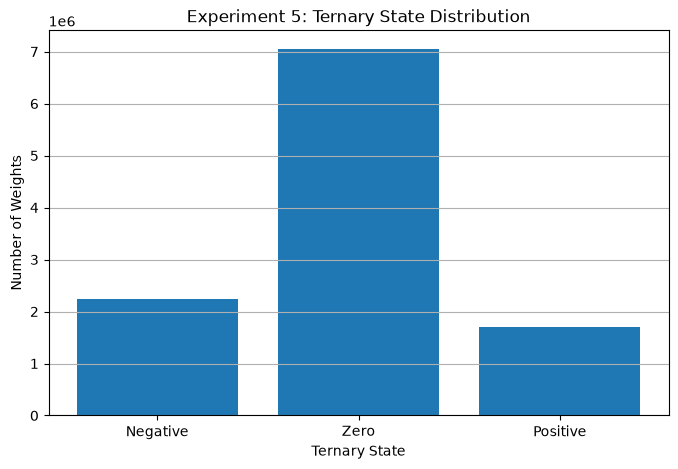

In [211]:
states_exp5 = [
    "Negative",
    "Zero",
    "Positive"
]

counts_exp5 = [
    negative_count_exp5,
    zero_count_exp5,
    positive_count_exp5
]

plt.figure(figsize=(8, 5))

plt.bar(
    states_exp5,
    counts_exp5
)

plt.xlabel("Ternary State")
plt.ylabel("Number of Weights")
plt.title("Experiment 5: Ternary State Distribution")
plt.grid(axis="y")
plt.show()

In [212]:
ternary_student_exp5.eval()

correct_exp5 = 0
total_exp5 = 0

with torch.no_grad():

    for images, labels in cifarnet_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = ternary_student_exp5(images)
        predictions = outputs.argmax(dim=1)

        total_exp5 += labels.size(0)

        correct_exp5 += (
            predictions == labels
        ).sum().item()

cifarnet_acc_exp5 = (
    100.0 * correct_exp5 / total_exp5
)

print("Experiment 5 CIFARNet Results")
print(f"Total Images: {total_exp5}")
print(f"Correct Predictions: {correct_exp5}")
print(f"CIFARNet Accuracy: {cifarnet_acc_exp5:.2f}%")

Experiment 5 CIFARNet Results
Total Images: 10000
Correct Predictions: 7259
CIFARNet Accuracy: 72.59%


In [213]:
print("Experiment 5 CIFARNet Accuracy")
print(f"Accuracy: {cifarnet_acc_exp5:.2f}%")

Experiment 5 CIFARNet Accuracy
Accuracy: 72.59%


In [214]:
class_correct_exp5 = [0] * len(class_names)
class_total_exp5 = [0] * len(class_names)

ternary_student_exp5.eval()

with torch.no_grad():

    for images, labels in cifarnet_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = ternary_student_exp5(images)
        predictions = outputs.argmax(dim=1)

        for i in range(labels.size(0)):

            label = labels[i].item()
            prediction = predictions[i].item()

            class_total_exp5[label] += 1

            if prediction == label:
                class_correct_exp5[label] += 1

print("Experiment 5 CIFARNet Per-Class Accuracy")

for i, class_name in enumerate(class_names):

    accuracy = (
        100.0 * class_correct_exp5[i] /
        class_total_exp5[i]
        if class_total_exp5[i] > 0
        else 0.0
    )

    print(
        f"{class_name:12s}: "
        f"{accuracy:.2f}% "
        f"({class_correct_exp5[i]}/{class_total_exp5[i]})"
    )

Experiment 5 CIFARNet Per-Class Accuracy
Aeroplane   : 84.25% (813/965)
Automobile  : 67.88% (691/1018)
Bird        : 66.18% (677/1023)
Cat         : 69.39% (662/954)
Deer        : 84.42% (867/1027)
Dog         : 52.71% (554/1051)
Frog        : 78.20% (782/1000)
Horse       : 71.56% (750/1048)
Ship        : 78.54% (743/946)
Truck       : 74.38% (720/968)


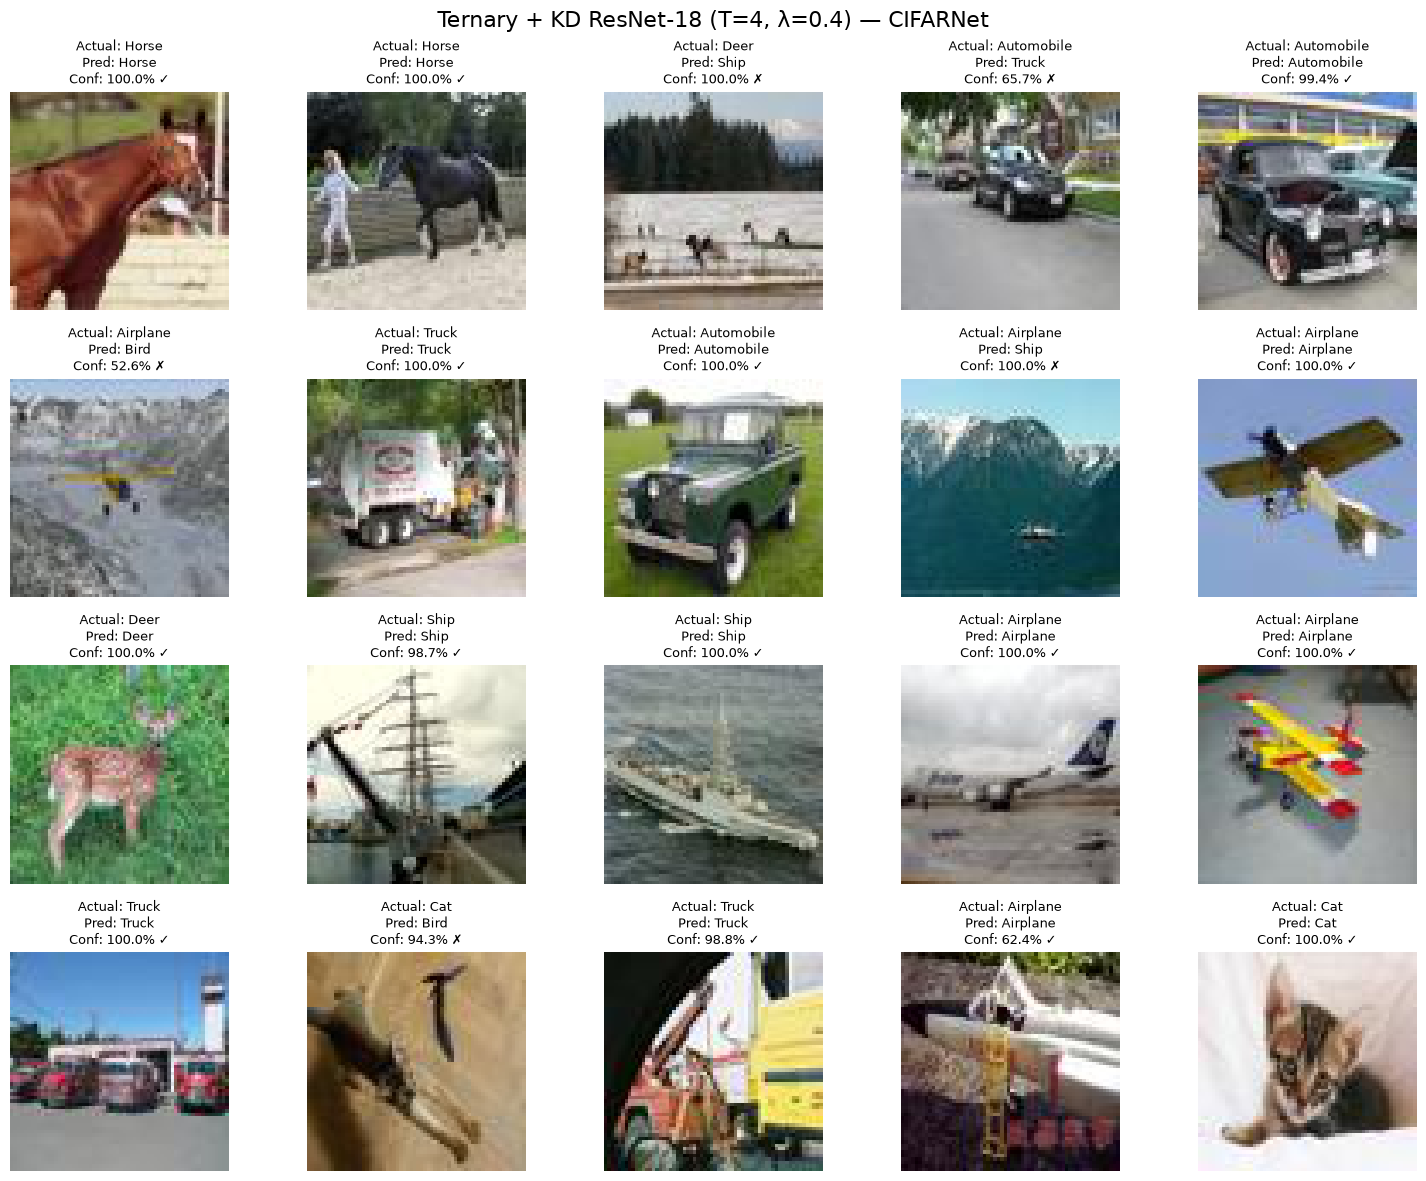

In [217]:
rng = np.random.default_rng(42)

indices_exp5 = rng.choice(
    len(cifarnet_dataset),
    size=20,
    replace=False
)

fig, axes = plt.subplots(
    4,
    5,
    figsize=(15, 12)
)

for ax, idx in zip(
    axes.ravel(),
    indices_exp5
):

    item = cifarnet_test[int(idx)]

    image = item["img"].convert("RGB")
    actual = item["label"]

    x = cifarnet_transform(image)
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        logits = ternary_student_exp5(x)

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        confidence, prediction = probabilities.max(
            dim=1
        )

    predicted = prediction.item()
    confidence = confidence.item() * 100

    status = (
        "✓"
        if actual == predicted
        else "✗"
    )

    ax.imshow(image)

    ax.set_title(
        f"Actual: {classes[actual]}\n"
        f"Pred: {classes[predicted]}\n"
        f"Conf: {confidence:.1f}% {status}",
        fontsize=9
    )

    ax.axis("off")

plt.suptitle(
    "Ternary + KD ResNet-18 "
    "(T=4, λ=0.4) — CIFARNet",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [218]:
print("=" * 90)
print(
    "CONFIDENCE SCORES — "
    "20 RANDOM CIFARNET IMAGES"
)
print("=" * 90)

for display_idx, idx in enumerate(indices_exp5):

    item = cifarnet_test[int(idx)]

    image = item["img"].convert("RGB")
    actual = item["label"]

    x = cifarnet_transform(image)
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        logits = ternary_student_exp5(x)

        probabilities = torch.softmax(
            logits,
            dim=1
        )[0]

    predicted = probabilities.argmax().item()

    print("\n" + "=" * 90)
    print(f"Image {display_idx + 1}")
    print(f"Actual class:    {classes[actual]}")
    print(f"Predicted class: {classes[predicted]}")
    print("-" * 90)

    for class_id, class_name in enumerate(classes):

        print(
            f"{class_name:12s}: "
            f"{probabilities[class_id].item() * 100:7.2f}%"
        )

CONFIDENCE SCORES — 20 RANDOM CIFARNET IMAGES

Image 1
Actual class:    Horse
Predicted class: Horse
------------------------------------------------------------------------------------------
Airplane    :    0.00%
Automobile  :    0.00%
Bird        :    0.00%
Cat         :    0.00%
Deer        :    0.00%
Dog         :    0.00%
Frog        :    0.00%
Horse       :  100.00%
Ship        :    0.00%
Truck       :    0.00%

Image 2
Actual class:    Horse
Predicted class: Horse
------------------------------------------------------------------------------------------
Airplane    :    0.00%
Automobile  :    0.00%
Bird        :    0.00%
Cat         :    0.00%
Deer        :    0.00%
Dog         :    0.00%
Frog        :    0.00%
Horse       :  100.00%
Ship        :    0.00%
Truck       :    0.00%

Image 3
Actual class:    Deer
Predicted class: Ship
------------------------------------------------------------------------------------------
Airplane    :    0.00%
Automobile  :    0.00%
Bird        